# M10 input-zscore final Mondrian calibration

This notebook calibrates conformal/Mondrian intervals for the final M10 input-zscore model trained on the 400k/40k/30k/30k split.

## 1. Imports and paths

In [ ]:
from pathlib import Path
import sys
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors as mpl_colors

pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:.6f}")

# ---------------------------------------------------------------------
# Portable project/data-root resolution
# ---------------------------------------------------------------------
cwd = Path.cwd().resolve()

BOOTSTRAP_PROJECT_ROOT = next(
    (
        candidate
        for candidate in (cwd, *cwd.parents)
        if (candidate / "src" / "paths.py").is_file()
    ),
    None,
)

if BOOTSTRAP_PROJECT_ROOT is None:
    raise RuntimeError(
        "Could not locate the cbc_pe repository root from the current "
        f"working directory: {cwd}"
    )

if str(BOOTSTRAP_PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOTSTRAP_PROJECT_ROOT))

from src.paths import resolve_data_root, resolve_project_root

PROJECT_ROOT = resolve_project_root()

PRED_CONFIG_PATH = (
    PROJECT_ROOT
    / "configs"
    / "predictions"
    / "predict_500k_M10_inputzscore_cal_test.json"
)

with PRED_CONFIG_PATH.open("r", encoding="utf-8") as f:
    _path_cfg = json.load(f)

DATA_ROOT = resolve_data_root(
    config_data_root=_path_cfg.get("data_root"),
)

RESULTS_ROOT = DATA_ROOT / "results"
PROCESSED_ROOT = DATA_ROOT / "processed"
CHECKPOINT_ROOT = DATA_ROOT / "models" / "checkpoints"

DATASET_ID = "bbh_processed_4s_seobnrv4opt_snr10-25_n500_000"

DATASET_RESULTS_ROOT = RESULTS_ROOT / DATASET_ID
DATASET_CHECKPOINT_ROOT = CHECKPOINT_ROOT / DATASET_ID
DATASET_PROCESSED_ROOT = PROCESSED_ROOT / DATASET_ID

CONFIDENCE_LEVEL = 0.90

N_BINS_GRID = [4, 6, 8, 12, 16, 24, 32, 48]
TAXONOMY_MODES = ["prediction", "difficulty"]
INTERVAL_MODES = ["symmetric", "asymmetric"]

N_NEIGHBORS = 5
MIN_SAMPLES_PER_BIN = 20

LABEL_NAMES_DEFAULT = ["chirp_mass", "total_mass", "chi_eff"]

# ---------------------------------------------------------------------
# Plot style
# ---------------------------------------------------------------------
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 160,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linewidth": 0.8,
    "axes.titleweight": "normal",
    "axes.titlesize": 12,
    "axes.labelsize": 10.5,
    "legend.frameon": False,
    "legend.fontsize": 9,
})

PALETTE = {
    "coverage": "#26578F",
    "coverage_dark": "#1A3553",
    "width": "#831616",
    "width_dark": "#5C0E0E",
    "nominal": "#252525",
    "band_1": "#60A4EC",
    "band_2": "#60A4EC",
    "band_3": "#60A4EC",
    "prediction": "#456990",
    "difficulty": "#7A5C99",
    "symmetric": "#2A9D8F",
    "asymmetric": "#E76F51",
    "ideal": "#B23A48",
    "median": "#B23A48",
    "density_cmap": "mako",  # fallback handled below if unavailable
}

# Matplotlib may not know "mako" unless seaborn is installed/registered.
# Fall back to a built-in perceptually smooth cmap.
try:
    plt.get_cmap(PALETTE["density_cmap"])
except ValueError:
    PALETTE["density_cmap"] = "viridis"

LABEL_TEX = {
    "chirp_mass": r"$\mathcal{M}$",
    "total_mass": r"$M_{\mathrm{tot}}$",
    "chi_eff": r"$\chi_{\mathrm{eff}}$",
}

LABEL_UNITS = {
    "chirp_mass": r"$M_\odot$",
    "total_mass": r"$M_\odot$",
    "chi_eff": "",
}

FIELD_TEX = {
    "network_snr": r"network SNR $\rho_{\mathrm{net}}$",
    "target_snr": r"target SNR $\rho_{\mathrm{target}}$",
    "signal_network_duration": r"signal duration $\Delta t_{\mathrm{GW}}$ [s]",
    "chirp_mass": r"true $\mathcal{M}$ [$M_\odot$]",
    "total_mass": r"true $M_{\mathrm{tot}}$ [$M_\odot$]",
    "chi_eff": r"true $\chi_{\mathrm{eff}}$",
    "distance": r"distance [Mpc]",
}


def label_tex(label):
    return LABEL_TEX.get(label, label)


def label_unit(label):
    return LABEL_UNITS.get(label, "")


def field_tex(field):
    return FIELD_TEX.get(field, field.replace("_", " "))


def style_axis(ax):
    ax.grid(True, alpha=0.25, linewidth=0.8)
    ax.tick_params(axis="both", labelsize=9)
    return ax


def add_panel_label(ax, text, loc="upper left"):
    ax.text(
        0.02,
        0.98,
        text,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=9,
        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor="white",
            edgecolor="0.85",
            alpha=0.85,
        ),
    )


print("PROJECT_ROOT:", PROJECT_ROOT, PROJECT_ROOT.exists())
print("DATASET_RESULTS_ROOT:", DATASET_RESULTS_ROOT, DATASET_RESULTS_ROOT.exists())
print("PROCESSED_ROOT:", PROCESSED_ROOT, PROCESSED_ROOT.exists())
print("DATASET_CHECKPOINT_ROOT:", DATASET_CHECKPOINT_ROOT, DATASET_CHECKPOINT_ROOT.exists())


PROJECT_ROOT: /afs/ciemat.es/user/v/vserrano/Desktop/gw/Gravitational-Waves-Lab/cbc_pe True
DATASET_RESULTS_ROOT: /data/vserrano/cbc_pe_data/results/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000 True
PROCESSED_ROOT: /data/vserrano/cbc_pe_data/processed True
DATASET_CHECKPOINT_ROOT: /data/vserrano/cbc_pe_data/models/checkpoints/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000 True


## 2. Resolve M10 files

In [2]:
def resolve_file(root: Path, patterns, description: str) -> Path:
    if isinstance(patterns, (str, Path)):
        patterns = [patterns]

    matches = []
    for pattern in patterns:
        matches.extend(root.glob(str(pattern)))

    matches = sorted(set(matches), key=lambda p: p.stat().st_mtime)

    if not matches:
        raise FileNotFoundError(
            f"Could not find {description} in {root}.\n"
            f"Patterns tried: {[str(p) for p in patterns]}"
        )

    print(f"\n{description}:")
    for path in matches:
        print("  ", path.name)

    selected = matches[-1]
    print("Selected:", selected.name)
    return selected


M10 = {
    "model_id": "M10",
    "prediction_path": resolve_file(
        DATASET_RESULTS_ROOT,
        [
            f"m10_inputzscore_500k_cal_test_predictions_embeddings.npz",
        ],
        "M10 prediction/embedding file",
    ),
    "history_path": resolve_file(
        DATASET_RESULTS_ROOT,
        [
            f"{DATASET_ID}_SimpleCNN_ResidualDilated_M10_inputzscore_resdilated_emb64_d124_train400k_MSELoss_seed123_history.npz",
        ],
        "M10 training history",
    ),
    "checkpoint_path": resolve_file(
        DATASET_CHECKPOINT_ROOT,
        [
            f"{DATASET_ID}_SimpleCNN_ResidualDilated_M10_inputzscore_resdilated_emb64_d124_train400k_MSELoss_seed123_checkpoint.pt",
        ],
        "M10 checkpoint",
    ),
}

LABEL_STATS_PATH = resolve_file(
    DATASET_PROCESSED_ROOT,
    [
        f"{DATASET_ID}_label_stats_train_only_train400000_val40000_cal30000_test30000_seed123.npz",
    ],
    "label statistics",
)

DATASET_H5_PATH = resolve_file(
    DATASET_PROCESSED_ROOT,
    [
        f"{DATASET_ID}.h5",
    ],
    "processed HDF5 dataset",
)

SIDE_METADATA_PATHS = sorted(DATASET_PROCESSED_ROOT.glob(f"{DATASET_ID}*.metadata*"))
print("\nMetadata sidecars:")
for p in SIDE_METADATA_PATHS:
    print(" ", p.name)



M10 prediction/embedding file:
   m10_inputzscore_500k_cal_test_predictions_embeddings.npz
Selected: m10_inputzscore_500k_cal_test_predictions_embeddings.npz

M10 training history:
   bbh_processed_4s_seobnrv4opt_snr10-25_n500_000_SimpleCNN_ResidualDilated_M10_inputzscore_resdilated_emb64_d124_train400k_MSELoss_seed123_history.npz
Selected: bbh_processed_4s_seobnrv4opt_snr10-25_n500_000_SimpleCNN_ResidualDilated_M10_inputzscore_resdilated_emb64_d124_train400k_MSELoss_seed123_history.npz

M10 checkpoint:
   bbh_processed_4s_seobnrv4opt_snr10-25_n500_000_SimpleCNN_ResidualDilated_M10_inputzscore_resdilated_emb64_d124_train400k_MSELoss_seed123_checkpoint.pt
Selected: bbh_processed_4s_seobnrv4opt_snr10-25_n500_000_SimpleCNN_ResidualDilated_M10_inputzscore_resdilated_emb64_d124_train400k_MSELoss_seed123_checkpoint.pt

label statistics:
   bbh_processed_4s_seobnrv4opt_snr10-25_n500_000_label_stats_train_only_train400000_val40000_cal30000_test30000_seed123.npz
Selected: bbh_processed_4s_seob

## 3. Load arrays and label statistics

In [3]:
def load_npz_verbose(path: Path) -> dict:
    out = {}
    with np.load(path, allow_pickle=True) as data:
        print(path.name)
        for key in sorted(data.files):
            value = np.asarray(data[key])
            print(f"  {key:24s} shape={str(value.shape):16s} dtype={value.dtype}")
            out[key] = value
    return out


RAW = load_npz_verbose(M10["prediction_path"])

with np.load(LABEL_STATS_PATH, allow_pickle=True) as stats:
    y_mean = np.asarray(stats["y_mean"], dtype=float)
    y_std = np.asarray(stats["y_std"], dtype=float)

if "label_names" in RAW:
    label_names = RAW["label_names"].tolist()
    label_names = [
        x.decode() if isinstance(x, bytes) else str(x)
        for x in label_names
    ]
else:
    label_names = LABEL_NAMES_DEFAULT

print("\nlabel_names:", label_names)
print("y_mean:", y_mean)
print("y_std:", y_std)


def get_split(split: str) -> dict:
    required = [f"idx_{split}", f"pred_{split}", f"y_{split}", f"emb_{split}"]
    missing = [key for key in required if key not in RAW]

    if missing:
        raise KeyError(f"Missing keys for split={split}: {missing}")

    return {
        "idx": np.asarray(RAW[f"idx_{split}"], dtype=np.int64),
        "pred": np.asarray(RAW[f"pred_{split}"], dtype=float),
        "y": np.asarray(RAW[f"y_{split}"], dtype=float),
        "emb": np.asarray(RAW[f"emb_{split}"], dtype=float),
    }


SPLITS = {
    #"val": get_split("val"),
    "cal": get_split("cal"),
    "test": get_split("test"),
}

for split, data in SPLITS.items():
    print(
        split,
        "idx", data["idx"].shape,
        "pred", data["pred"].shape,
        "y", data["y"].shape,
        "emb", data["emb"].shape,
    )

assert SPLITS["cal"]["pred"].shape == SPLITS["cal"]["y"].shape
assert SPLITS["test"]["pred"].shape == SPLITS["test"]["y"].shape
assert SPLITS["test"]["pred"].shape[1] == len(label_names)


m10_inputzscore_500k_cal_test_predictions_embeddings.npz
  available_splits         shape=(2,)             dtype=<U4
  checkpoint_file          shape=()               dtype=<U196
  dataset_path             shape=()               dtype=<U86
  emb_cal                  shape=(30000, 64)      dtype=float32
  emb_test                 shape=(30000, 64)      dtype=float32
  idx_cal                  shape=(30000,)         dtype=int64
  idx_test                 shape=(30000,)         dtype=int64
  input_normalization      shape=()               dtype=object
  label_names              shape=(3,)             dtype=<U10
  label_stats_path         shape=()               dtype=<U158
  model_config             shape=()               dtype=object
  pred_cal                 shape=(30000, 3)       dtype=float32
  pred_test                shape=(30000, 3)       dtype=float32
  split_path               shape=()               dtype=<U142
  y_cal                    shape=(30000, 3)       dtype=float32
  y_m

## 4. Basic point-estimation diagnostics

In [4]:
def inverse_standardize(values):
    return values * y_std + y_mean


def regression_metrics(y_true, y_pred, split, space):
    residual = y_pred - y_true
    abs_error = np.abs(residual)

    rows = []
    for j, label in enumerate(label_names):
        ss_res = np.sum(residual[:, j] ** 2)
        ss_tot = np.sum((y_true[:, j] - np.mean(y_true[:, j])) ** 2)

        slope, intercept = np.polyfit(y_true[:, j], y_pred[:, j], deg=1)
        corr = np.corrcoef(y_true[:, j], y_pred[:, j])[0, 1]

        rows.append({
            "split": split,
            "space": space,
            "label": label,
            "MSE": float(np.mean(residual[:, j] ** 2)),
            "RMSE": float(np.sqrt(np.mean(residual[:, j] ** 2))),
            "MAE": float(np.mean(abs_error[:, j])),
            "median_abs_error": float(np.median(abs_error[:, j])),
            "q90_abs_error": float(np.quantile(abs_error[:, j], 0.90)),
            "q95_abs_error": float(np.quantile(abs_error[:, j], 0.95)),
            "q99_abs_error": float(np.quantile(abs_error[:, j], 0.99)),
            "bias": float(np.mean(residual[:, j])),
            "residual_std": float(np.std(residual[:, j])),
            "R2": float(1.0 - ss_res / ss_tot),
            "slope_pred_vs_true": float(slope),
            "intercept_pred_vs_true": float(intercept),
            "correlation": float(corr),
            "std_pred_over_true": float(np.std(y_pred[:, j]) / np.std(y_true[:, j])),
        })

    return rows


metric_rows = []

for split, data in SPLITS.items():
    metric_rows.extend(
        regression_metrics(
            y_true=data["y"],
            y_pred=data["pred"],
            split=split,
            space="standardized",
        )
    )
    metric_rows.extend(
        regression_metrics(
            y_true=inverse_standardize(data["y"]),
            y_pred=inverse_standardize(data["pred"]),
            split=split,
            space="physical",
        )
    )

point_metrics_df = pd.DataFrame(metric_rows)

global_point_metrics_df = (
    point_metrics_df
    .groupby(["split", "space"], as_index=False)
    .agg(
        global_MSE=("MSE", "mean"),
        global_RMSE=("RMSE", "mean"),
        global_MAE=("MAE", "mean"),
        mean_R2=("R2", "mean"),
    )
)

display(global_point_metrics_df.query("space == 'standardized'"))
display(point_metrics_df.query("split == 'test' and space == 'standardized'"))
display(point_metrics_df.query("split == 'test' and space == 'physical'"))


,split,space,global_MSE,global_RMSE,global_MAE,mean_R2
1,cal,standardized,0.113845,0.331079,0.241187,0.886127
3,test,standardized,0.114238,0.331424,0.241625,0.885830


,split,space,label,MSE,RMSE,MAE,median_abs_error,q90_abs_error,q95_abs_error,q99_abs_error,bias,residual_std,R2,slope_pred_vs_true,intercept_pred_vs_true,correlation,std_pred_over_true
6,test,standardized,chirp_mass,0.090165,0.300274,0.207245,0.139079,0.471964,0.623518,1.034241,0.013218,0.299983,0.910353,0.888337,0.013653,0.954513,0.930671
7,test,standardized,total_mass,0.073121,0.270409,0.201655,0.155985,0.429910,0.545829,0.840207,0.031125,0.268612,0.927000,0.888489,0.031647,0.964263,0.921418
8,test,standardized,chi_eff,0.179427,0.423588,0.315976,0.244524,0.670979,0.856834,1.316785,0.053638,0.420178,0.820138,0.813638,0.055153,0.907266,0.896802


,split,space,label,MSE,RMSE,MAE,median_abs_error,q90_abs_error,q95_abs_error,q99_abs_error,bias,residual_std,R2,slope_pred_vs_true,intercept_pred_vs_true,correlation,std_pred_over_true
9,test,physical,chirp_mass,24.501876,4.949937,3.416382,2.292678,7.780191,10.278525,17.049171,0.217900,4.945139,0.910353,0.888337,4.407136,0.954513,0.930671
10,test,physical,total_mass,87.791913,9.369734,6.987367,5.404891,14.896467,18.913055,29.113311,1.078494,9.307457,0.927000,0.888489,11.687218,0.964263,0.921418
11,test,physical,chi_eff,0.034872,0.186741,0.139300,0.107800,0.295805,0.377740,0.580511,0.023647,0.185238,0.820138,0.813638,0.024505,0.907266,0.896802


## 5. True-vs-predicted and residual density plots

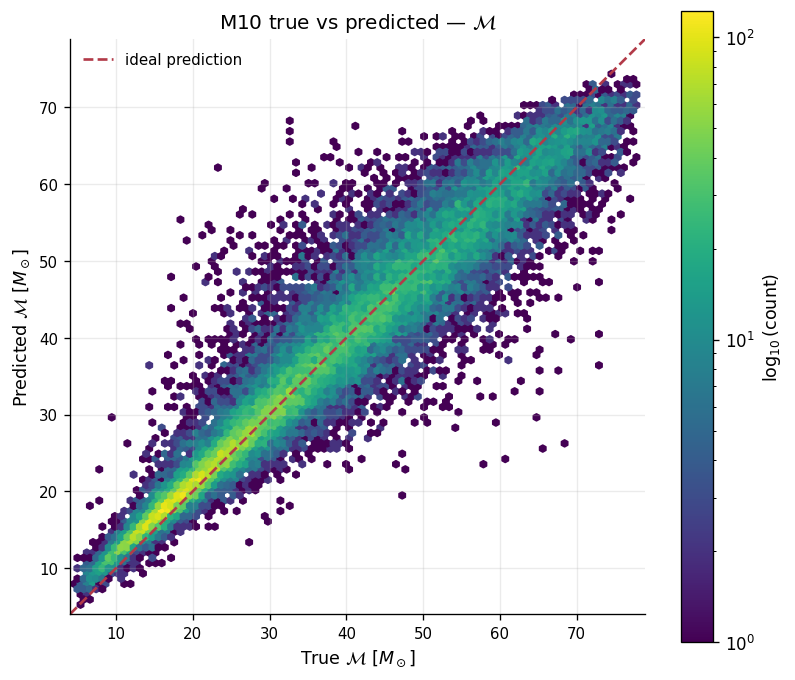

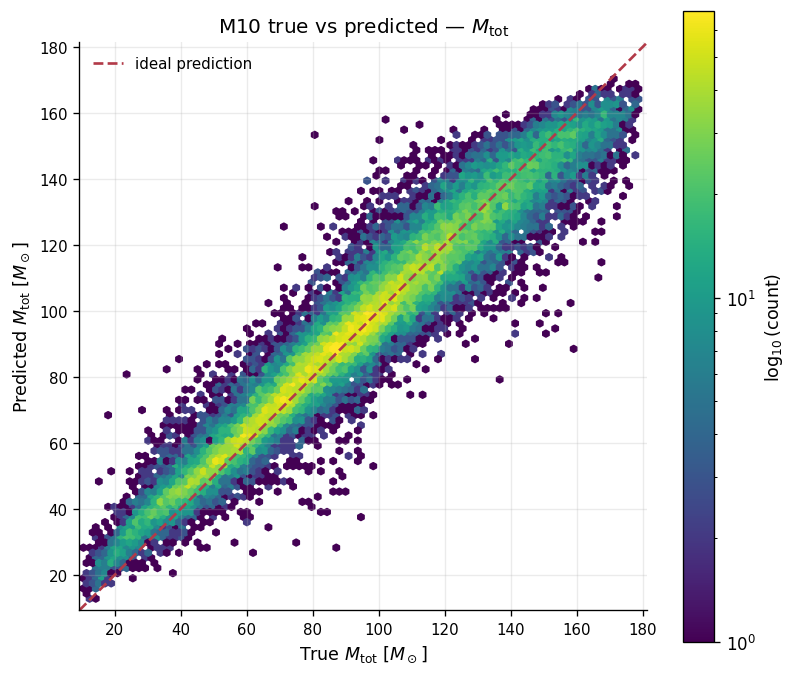

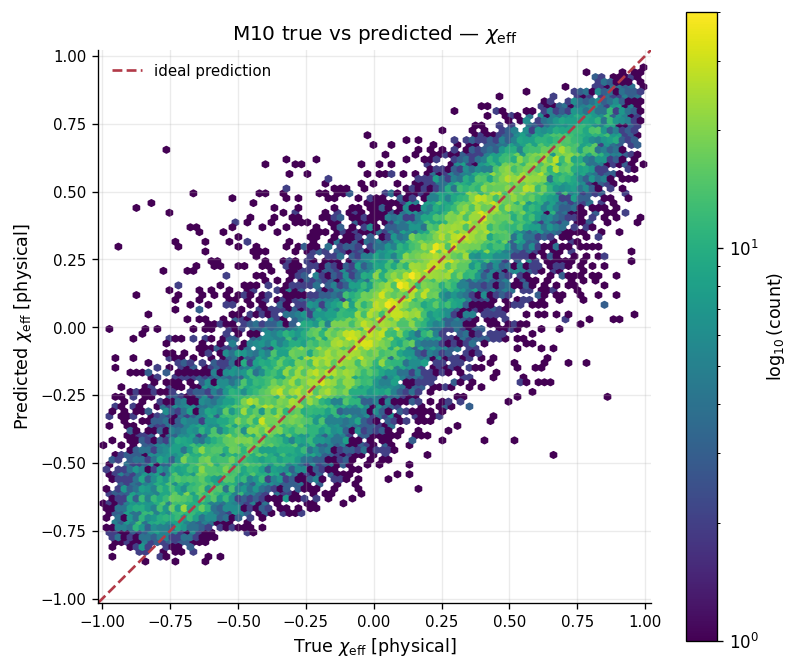

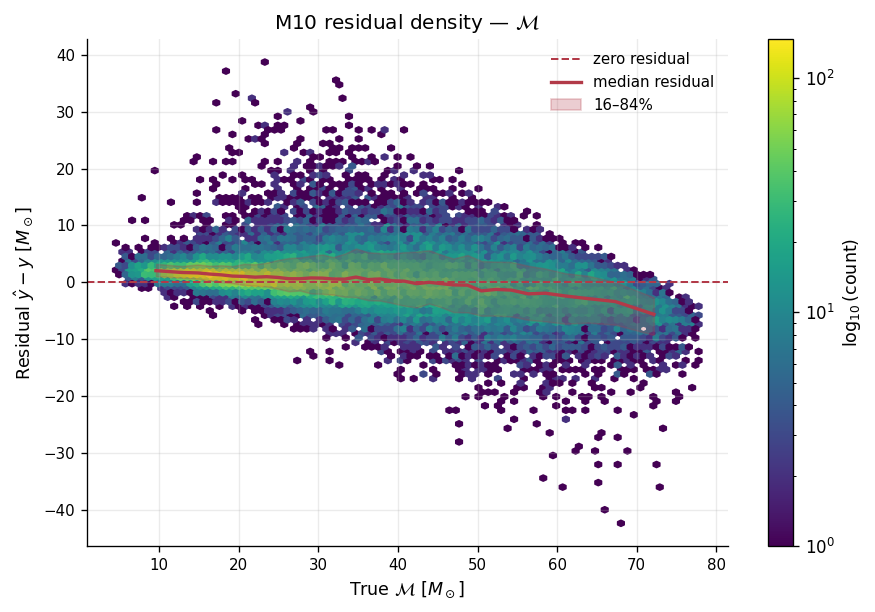

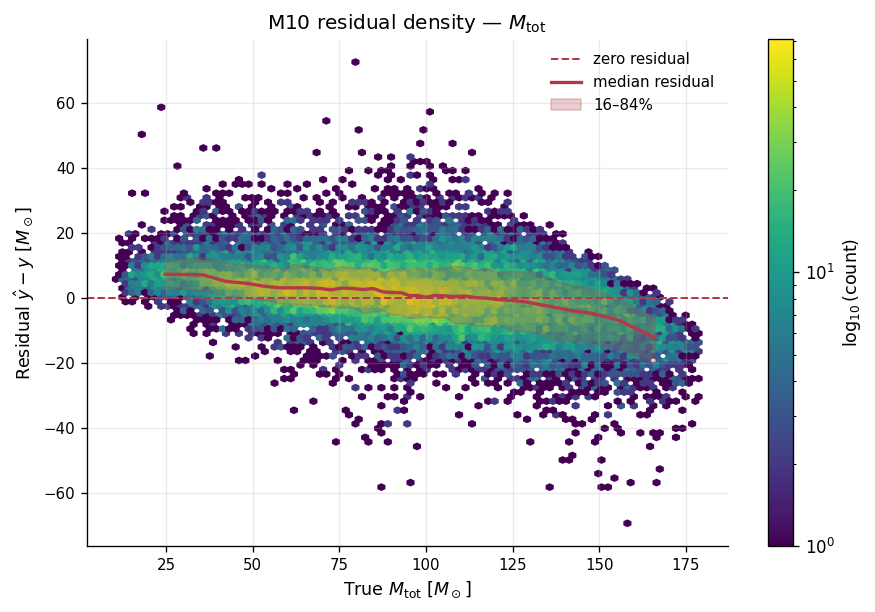

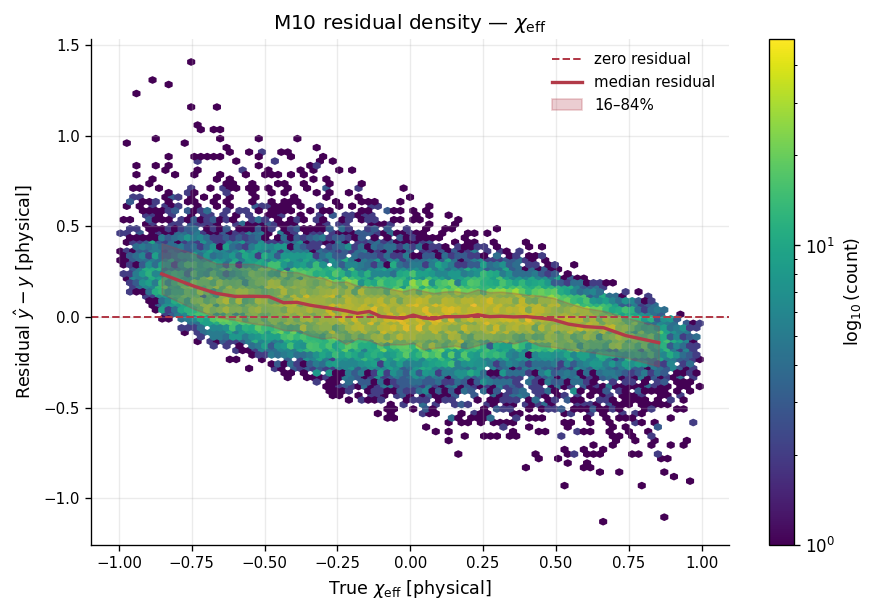

In [5]:
def plot_true_pred_density(split="test", physical_space=True, gridsize=90):
    data = SPLITS[split]

    if physical_space:
        y_true = inverse_standardize(data["y"])
        y_pred = inverse_standardize(data["pred"])
        space = "physical"
    else:
        y_true = data["y"]
        y_pred = data["pred"]
        space = "standardized"

    for j, label in enumerate(label_names):
        x = y_true[:, j]
        y = y_pred[:, j]

        lo = min(np.quantile(x, 0.001), np.quantile(y, 0.001))
        hi = max(np.quantile(x, 0.999), np.quantile(y, 0.999))
        pad = 0.03 * (hi - lo)
        lo -= pad
        hi += pad

        fig, ax = plt.subplots(figsize=(6.8, 5.9))

        hb = ax.hexbin(
            x,
            y,
            gridsize=gridsize,
            bins="log",
            mincnt=1,
            cmap=PALETTE["density_cmap"],
        )
        cbar = fig.colorbar(hb, ax=ax)
        cbar.set_label(r"$\log_{10}(\mathrm{count})$")

        ax.plot(
            [lo, hi],
            [lo, hi],
            linestyle="--",
            color=PALETTE["ideal"],
            linewidth=1.6,
            label="ideal prediction",
        )

        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)
        ax.set_aspect("equal", adjustable="box")

        if physical_space and label_unit(label):
            axis_label = f"{label_tex(label)} [{label_unit(label)}]"
        else:
            axis_label = f"{label_tex(label)} [{space}]"

        ax.set_xlabel(f"True {axis_label}")
        ax.set_ylabel(f"Predicted {axis_label}")
        ax.set_title(f"M10 true vs predicted — {label_tex(label)}")
        ax.legend(loc="upper left")
        style_axis(ax)

        plt.tight_layout()
        plt.show()


def plot_residual_density(split="test", physical_space=True, gridsize=90, trend_bins=35):
    data = SPLITS[split]

    if physical_space:
        y_true = inverse_standardize(data["y"])
        y_pred = inverse_standardize(data["pred"])
        space = "physical"
    else:
        y_true = data["y"]
        y_pred = data["pred"]
        space = "standardized"

    for j, label in enumerate(label_names):
        true = y_true[:, j]
        residual = y_pred[:, j] - y_true[:, j]

        fig, ax = plt.subplots(figsize=(7.6, 5.2))

        hb = ax.hexbin(
            true,
            residual,
            gridsize=gridsize,
            bins="log",
            mincnt=1,
            cmap=PALETTE["density_cmap"],
        )
        cbar = fig.colorbar(hb, ax=ax)
        cbar.set_label(r"$\log_{10}(\mathrm{count})$")

        ax.axhline(
            0.0,
            linestyle="--",
            color=PALETTE["ideal"],
            linewidth=1.2,
            label="zero residual",
        )

        edges = np.quantile(true, np.linspace(0, 1, trend_bins + 1))
        edges = np.unique(edges)

        centers = []
        medians = []
        q16 = []
        q84 = []

        for left, right in zip(edges[:-1], edges[1:]):
            mask = (true >= left) & (true <= right)
            if mask.sum() < 20:
                continue

            centers.append(np.median(true[mask]))
            medians.append(np.median(residual[mask]))
            q16.append(np.quantile(residual[mask], 0.16))
            q84.append(np.quantile(residual[mask], 0.84))

        centers = np.asarray(centers)
        medians = np.asarray(medians)
        q16 = np.asarray(q16)
        q84 = np.asarray(q84)

        ax.plot(
            centers,
            medians,
            linewidth=2.0,
            color=PALETTE["median"],
            label="median residual",
        )
        ax.fill_between(
            centers,
            q16,
            q84,
            color=PALETTE["median"],
            alpha=0.25,
            label="16–84%",
        )

        if physical_space and label_unit(label):
            x_label = f"True {label_tex(label)} [{label_unit(label)}]"
            y_label = f"Residual $\\hat y - y$ [{label_unit(label)}]"
        else:
            x_label = f"True {label_tex(label)} [{space}]"
            y_label = f"Residual $\\hat y - y$ [{space}]"

        ax.set_xlabel(x_label)
        ax.set_ylabel(y_label)
        ax.set_title(f"M10 residual density — {label_tex(label)}")
        ax.legend(loc="best")
        style_axis(ax)

        plt.tight_layout()
        plt.show()


plot_true_pred_density(split="test", physical_space=True)
plot_residual_density(split="test", physical_space=True)


## 6. Global split conformal baseline

This is not the final method, but it is the simplest conformal reference. It uses one residual quantile per label, without Mondrian bins.


In [6]:
def conformal_order_statistic(values, confidence_level):
    values = np.sort(np.asarray(values))
    n = len(values)
    k = int(np.ceil((n + 1) * confidence_level)) - 1
    k = int(np.clip(k, 0, n - 1))
    return values[k]


def global_symmetric_conformal(pred_cal, y_cal, pred_test, y_test, confidence_level):
    n_labels = y_cal.shape[1]
    lower = np.empty_like(pred_test)
    upper = np.empty_like(pred_test)
    quantiles = np.empty(n_labels)

    for j in range(n_labels):
        scores = np.abs(y_cal[:, j] - pred_cal[:, j])
        q = conformal_order_statistic(scores, confidence_level)
        quantiles[j] = q
        lower[:, j] = pred_test[:, j] - q
        upper[:, j] = pred_test[:, j] + q

    covered = (y_test >= lower) & (y_test <= upper)
    widths = upper - lower

    return {
        "lower": lower,
        "upper": upper,
        "quantiles": quantiles,
        "covered": covered,
        "widths": widths,
    }


GLOBAL_CONFORMAL = global_symmetric_conformal(
    pred_cal=SPLITS["cal"]["pred"],
    y_cal=SPLITS["cal"]["y"],
    pred_test=SPLITS["test"]["pred"],
    y_test=SPLITS["test"]["y"],
    confidence_level=CONFIDENCE_LEVEL,
)

global_rows = []
widths_phys = GLOBAL_CONFORMAL["widths"] * y_std

for j, label in enumerate(label_names):
    global_rows.append({
        "label": label,
        "coverage": float(GLOBAL_CONFORMAL["covered"][:, j].mean()),
        "mean_width_phys": float(np.mean(widths_phys[:, j])),
        "median_width_phys": float(np.median(widths_phys[:, j])),
        "q90_width_phys": float(np.quantile(widths_phys[:, j], 0.90)),
        "q95_width_phys": float(np.quantile(widths_phys[:, j], 0.95)),
        "score_quantile_std": float(GLOBAL_CONFORMAL["quantiles"][j]),
    })

global_conformal_df = pd.DataFrame(global_rows)
display(global_conformal_df)


,label,coverage,mean_width_phys,median_width_phys,q90_width_phys,q95_width_phys,score_quantile_std
0,chirp_mass,0.899967,15.558949,15.558949,15.558949,15.558949,0.471920
1,total_mass,0.901533,30.002580,30.002580,30.002580,30.002580,0.432936
2,chi_eff,0.900633,0.593445,0.593445,0.593445,0.593445,0.673061


## 7. Run M10 Mondrian grid

In [7]:
from src.conformal.pipeline import run_mondrian_regression

all_results = {}
summary_rows = []

pred_cal = SPLITS["cal"]["pred"]
y_cal = SPLITS["cal"]["y"]
emb_cal = SPLITS["cal"]["emb"]

pred_test = SPLITS["test"]["pred"]
y_test = SPLITS["test"]["y"]
emb_test = SPLITS["test"]["emb"]

for taxonomy_mode in TAXONOMY_MODES:
    for interval_mode in INTERVAL_MODES:
        for n_bins in N_BINS_GRID:
            kwargs = dict(
                pred_cal=pred_cal,
                pred_test=pred_test,
                y_cal=y_cal,
                y_test=y_test,
                n_bins=n_bins,
                confidence_level=CONFIDENCE_LEVEL,
                apply_jitter=True,
                interval_mode=interval_mode,
                taxonomy_mode=taxonomy_mode,
                min_samples_per_bin=MIN_SAMPLES_PER_BIN,
                tolerance_sigmas=(1, 2, 3),
            )

            if taxonomy_mode == "difficulty":
                kwargs.update(
                    cal_embedding=emb_cal,
                    target_embedding=emb_test,
                    n_neighbors=N_NEIGHBORS,
                )

            result = run_mondrian_regression(**kwargs)
            key = (taxonomy_mode, interval_mode, n_bins)
            all_results[key] = result

            metrics = result.metrics
            widths_std = result.upper - result.lower
            widths_phys = widths_std * y_std

            for j, label in enumerate(label_names):
                coverage_bin = metrics["coverage_per_bin"][:, j]
                count_bin = metrics["counts_per_bin"][:, j]
                valid_bins = count_bin > 0

                bin_tol = metrics["bin_tolerance_normal"]
                low_2s = bin_tol["2sigma_low"][:, j]
                high_2s = bin_tol["2sigma_high"][:, j]

                outside_2s = valid_bins & (
                    (coverage_bin < low_2s)
                    | (coverage_bin > high_2s)
                )
                under_2s = valid_bins & (coverage_bin < low_2s)
                over_2s = valid_bins & (coverage_bin > high_2s)

                covered = (
                    (result.lower[:, j] <= y_test[:, j])
                    & (y_test[:, j] <= result.upper[:, j])
                )

                lower_miss = y_test[:, j] < result.lower[:, j]
                upper_miss = y_test[:, j] > result.upper[:, j]

                lower_miss_rate = float(lower_miss.mean())
                upper_miss_rate = float(upper_miss.mean())

                summary_rows.append({
                    "taxonomy_mode": taxonomy_mode,
                    "interval_mode": interval_mode,
                    "n_bins": int(n_bins),
                    "label": label,
                    "label_index": j,

                    "global_coverage": float(metrics["global_coverage"][j]),
                    "global_miscoverage": float(1.0 - metrics["global_coverage"][j]),
                    "global_undercoverage_pvalue": float(metrics["global_undercoverage_pvalue"][j]),

                    "global_mean_width_std": float(np.mean(widths_std[:, j])),
                    "global_median_width_std": float(np.median(widths_std[:, j])),
                    "global_q90_width_std": float(np.quantile(widths_std[:, j], 0.90)),
                    "global_q95_width_std": float(np.quantile(widths_std[:, j], 0.95)),

                    "global_mean_width_phys": float(np.mean(widths_phys[:, j])),
                    "global_median_width_phys": float(np.median(widths_phys[:, j])),
                    "global_q90_width_phys": float(np.quantile(widths_phys[:, j], 0.90)),
                    "global_q95_width_phys": float(np.quantile(widths_phys[:, j], 0.95)),
                    "global_width_iqr_phys": float(
                        np.quantile(widths_phys[:, j], 0.75)
                        - np.quantile(widths_phys[:, j], 0.25)
                    ),

                    "min_coverage_per_bin": float(np.nanmin(coverage_bin[valid_bins])),
                    "max_coverage_per_bin": float(np.nanmax(coverage_bin[valid_bins])),
                    "max_undercoverage_gap": float(
                        np.nanmax(np.maximum(0.0, CONFIDENCE_LEVEL - coverage_bin[valid_bins]))
                    ),
                    "min_count_per_bin": int(np.nanmin(count_bin[valid_bins])),
                    "max_count_per_bin": int(np.nanmax(count_bin[valid_bins])),

                    "n_bins_outside_2sigma": int(outside_2s.sum()),
                    "outside_bin_fraction_2sigma": float(outside_2s.sum() / valid_bins.sum()),
                    "n_bins_under_2sigma": int(under_2s.sum()),
                    "under_bin_fraction_2sigma": float(under_2s.sum() / valid_bins.sum()),
                    "n_bins_over_2sigma": int(over_2s.sum()),
                    "over_bin_fraction_2sigma": float(over_2s.sum() / valid_bins.sum()),

                    "min_bin_2sigma_low": float(np.nanmin(low_2s[valid_bins])),
                    "max_bin_2sigma_high": float(np.nanmax(high_2s[valid_bins])),

                    "lower_miss_rate": lower_miss_rate,
                    "upper_miss_rate": upper_miss_rate,
                    "global_tail_miss_imbalance": float(abs(lower_miss_rate - upper_miss_rate)),

                    "global_1sigma_low": float(metrics["global_tolerance_normal"]["1sigma_low"][j]),
                    "global_1sigma_high": float(metrics["global_tolerance_normal"]["1sigma_high"][j]),
                    "global_2sigma_low": float(metrics["global_tolerance_normal"]["2sigma_low"][j]),
                    "global_2sigma_high": float(metrics["global_tolerance_normal"]["2sigma_high"][j]),
                    "global_3sigma_low": float(metrics["global_tolerance_normal"]["3sigma_low"][j]),
                    "global_3sigma_high": float(metrics["global_tolerance_normal"]["3sigma_high"][j]),
                    "global_within_2sigma": bool(
                        (metrics["global_coverage"][j] >= metrics["global_tolerance_normal"]["2sigma_low"][j])
                        and (metrics["global_coverage"][j] <= metrics["global_tolerance_normal"]["2sigma_high"][j])
                    ),
                })

summary_df = pd.DataFrame(summary_rows)

display(summary_df.head())
print("Number of evaluated configurations:", len(summary_df))


,taxonomy_mode,interval_mode,n_bins,label,label_index,global_coverage,global_miscoverage,global_undercoverage_pvalue,global_mean_width_std,global_median_width_std,global_q90_width_std,global_q95_width_std,global_mean_width_phys,global_median_width_phys,global_q90_width_phys,global_q95_width_phys,global_width_iqr_phys,min_coverage_per_bin,max_coverage_per_bin,max_undercoverage_gap,min_count_per_bin,max_count_per_bin,n_bins_outside_2sigma,outside_bin_fraction_2sigma,n_bins_under_2sigma,under_bin_fraction_2sigma,n_bins_over_2sigma,over_bin_fraction_2sigma,min_bin_2sigma_low,max_bin_2sigma_high,lower_miss_rate,upper_miss_rate,global_tail_miss_imbalance,global_1sigma_low,global_1sigma_high,global_2sigma_low,global_2sigma_high,global_3sigma_low,global_3sigma_high,global_within_2sigma
0,prediction,symmetric,4,chirp_mass,0,0.901900,0.098100,0.865892,0.892322,0.798645,1.183251,1.183251,14.709673,13.165437,19.505566,19.505566,12.088054,0.895391,0.904564,0.004609,7471,7549,0,0.000000,0,0.000000,0,0.000000,0.893058,0.906942,0.056367,0.041733,0.014633,0.898268,0.901732,0.896536,0.903464,0.894804,0.905196,True
1,prediction,symmetric,4,total_mass,1,0.899633,0.100367,0.418969,0.845333,0.766215,1.028516,1.028516,29.290925,26.549490,35.638260,35.638260,6.696357,0.894793,0.903118,0.005207,7395,7592,0,0.000000,0,0.000000,0,0.000000,0.893023,0.906977,0.058833,0.041533,0.017300,0.898268,0.901732,0.896536,0.903464,0.894804,0.905196,True
2,prediction,symmetric,4,chi_eff,2,0.899267,0.100733,0.338745,1.333157,1.337679,1.482376,1.482376,0.587729,0.589723,0.653513,0.653513,0.122962,0.896135,0.901762,0.003865,7380,7606,0,0.000000,0,0.000000,0,0.000000,0.893016,0.906984,0.062300,0.038433,0.023867,0.898268,0.901732,0.896536,0.903464,0.894804,0.905196,True
3,prediction,symmetric,6,chirp_mass,0,0.899900,0.100100,0.479793,0.889971,0.861797,1.262855,1.262855,14.670929,14.206491,20.817811,20.817811,9.135539,0.893272,0.905124,0.006728,4885,5085,0,0.000000,0,0.000000,0,0.000000,0.891415,0.908585,0.058500,0.041600,0.016900,0.898268,0.901732,0.896536,0.903464,0.894804,0.905196,True
4,prediction,symmetric,6,total_mass,1,0.900200,0.099800,0.548774,0.846682,0.767368,1.019768,1.019768,29.337676,26.589431,35.335138,35.335138,8.464121,0.893849,0.906039,0.006151,4901,5052,0,0.000000,0,0.000000,0,0.000000,0.891429,0.908571,0.058433,0.041367,0.017067,0.898268,0.901732,0.896536,0.903464,0.894804,0.905196,True


Number of evaluated configurations: 96


## 8. Grid overview

In [8]:
overview_cols = [
    "taxonomy_mode",
    "interval_mode",
    "n_bins",
    "label",
    "global_coverage",
    "min_coverage_per_bin",
    "n_bins_under_2sigma",
    "under_bin_fraction_2sigma",
    "max_undercoverage_gap",
    "global_median_width_phys",
    "global_q95_width_phys",
    "global_tail_miss_imbalance",
    "min_count_per_bin",
]

display(
    summary_df[overview_cols]
    .sort_values(["label", "global_median_width_phys"])
    .head(30)
)

grid_agg_df = (
    summary_df
    .groupby(["taxonomy_mode", "interval_mode", "label"], as_index=False)
    .agg(
        n_configs=("n_bins", "count"),
        median_coverage=("global_coverage", "median"),
        median_width_phys=("global_median_width_phys", "median"),
        min_width_phys=("global_median_width_phys", "min"),
        median_under_bins=("n_bins_under_2sigma", "median"),
        median_max_undercoverage_gap=("max_undercoverage_gap", "median"),
        median_tail_imbalance=("global_tail_miss_imbalance", "median"),
    )
)

display(grid_agg_df)


,taxonomy_mode,interval_mode,n_bins,label,global_coverage,min_coverage_per_bin,n_bins_under_2sigma,under_bin_fraction_2sigma,max_undercoverage_gap,global_median_width_phys,global_q95_width_phys,global_tail_miss_imbalance,min_count_per_bin
74,difficulty,asymmetric,4,chi_eff,0.898267,0.888949,1,0.250000,0.011051,0.535013,0.743567,0.001933,7411
50,difficulty,symmetric,4,chi_eff,0.900067,0.886385,1,0.250000,0.013615,0.539757,0.745412,0.027067,7411
77,difficulty,asymmetric,6,chi_eff,0.898200,0.886499,2,0.333333,0.013501,0.540002,0.799726,0.001467,4894
83,difficulty,asymmetric,12,chi_eff,0.899033,0.884677,1,0.083333,0.015323,0.543044,0.907825,0.000167,2391
86,difficulty,asymmetric,16,chi_eff,0.900200,0.880865,2,0.125000,0.019135,0.548349,0.976508,0.000400,1750
80,difficulty,asymmetric,8,chi_eff,0.899867,0.886454,2,0.250000,0.013546,0.549491,0.841068,0.000200,3624
53,difficulty,symmetric,6,chi_eff,0.901700,0.888292,1,0.166667,0.011708,0.550375,0.808225,0.027433,4894
62,difficulty,symmetric,16,chi_eff,0.901100,0.882446,1,0.062500,0.017554,0.550375,0.966648,0.027633,1750
92,difficulty,asymmetric,32,chi_eff,0.900033,0.871849,3,0.093750,0.028151,0.551465,0.788872,0.000100,868
95,difficulty,asymmetric,48,chi_eff,0.900067,0.856698,3,0.062500,0.043302,0.551948,0.761047,0.001067,550


,taxonomy_mode,interval_mode,label,n_configs,median_coverage,median_width_phys,min_width_phys,median_under_bins,median_max_undercoverage_gap,median_tail_imbalance
0,difficulty,asymmetric,chi_eff,8,0.899450,0.548920,0.535013,2.000000,0.017229,0.000450
1,difficulty,asymmetric,chirp_mass,8,0.901633,13.761427,11.775588,0.500000,0.012967,0.001183
2,difficulty,asymmetric,total_mass,8,0.901967,27.644198,25.860052,0.500000,0.010130,0.000717
3,difficulty,symmetric,chi_eff,8,0.901200,0.554945,0.539757,1.500000,0.015584,0.027567
4,difficulty,symmetric,chirp_mass,8,0.902100,13.810470,11.731975,0.000000,0.009146,0.008750
5,difficulty,symmetric,total_mass,8,0.902700,27.679985,25.844899,0.000000,0.008447,0.007917
6,prediction,asymmetric,chi_eff,8,0.899717,0.593292,0.579209,1.000000,0.017413,0.001217
7,prediction,asymmetric,chirp_mass,8,0.899667,14.916639,13.188799,0.000000,0.009730,0.001333
8,prediction,asymmetric,total_mass,8,0.900250,26.540317,26.031483,1.000000,0.012056,0.002333
9,prediction,symmetric,chi_eff,8,0.900233,0.601903,0.582661,1.000000,0.016401,0.023850


## 9. Configuration selection policy

In [9]:
from src.conformal.selection import (
    select_conservative,
    select_efficient,
)

# ------------------------------------------------------------------
# Closed M10 Mondrian selection policy
# ------------------------------------------------------------------
# These values are part of the scientific definition of the closed
# M10 conformal baseline. They are passed explicitly rather than
# relying silently on the module defaults.
MIN_COUNT_PER_BIN = 200
WIDTH_TIE_FRACTION = 0.02
MAX_UNDER_BIN_FRACTION_EFFICIENT = 0.10
MAX_UNDERCOVERAGE_GAP_EFFICIENT = 0.05

# Presentation only: number of ranked alternatives retained for inspection.
TOP_K = 8


selection_rows = []
top_rows = []

for label in label_names:
    conservative, conservative_ranked = select_conservative(
        summary_df,
        label,
        min_count_per_bin=MIN_COUNT_PER_BIN,
        width_tie_fraction=WIDTH_TIE_FRACTION,
    )

    efficient, efficient_ranked = select_efficient(
        summary_df,
        label,
        min_count_per_bin=MIN_COUNT_PER_BIN,
        width_tie_fraction=WIDTH_TIE_FRACTION,
        max_under_bin_fraction=MAX_UNDER_BIN_FRACTION_EFFICIENT,
        max_undercoverage_gap=MAX_UNDERCOVERAGE_GAP_EFFICIENT,
    )

    conservative_dict = conservative.to_dict()
    conservative_dict["final_policy"] = "conservative"
    selection_rows.append(conservative_dict)

    efficient_dict = efficient.to_dict()
    efficient_dict["final_policy"] = "efficient"
    selection_rows.append(efficient_dict)

    top_rows.append(
        conservative_ranked
        .head(TOP_K)
        .assign(label=label, final_policy="conservative")
    )

    top_rows.append(
        efficient_ranked
        .head(TOP_K)
        .assign(label=label, final_policy="efficient")
    )


selection_df = pd.DataFrame(selection_rows)
top_candidates_df = pd.concat(top_rows, ignore_index=True)


selection_display_cols = [
    "final_policy",
    "label",
    "selection_policy",
    "taxonomy_mode",
    "interval_mode",
    "n_bins",
    "global_coverage",
    "min_coverage_per_bin",
    "n_bins_under_2sigma",
    "under_bin_fraction_2sigma",
    "max_undercoverage_gap",
    "global_median_width_phys",
    "global_q90_width_phys",
    "global_q95_width_phys",
    "global_tail_miss_imbalance",
    "min_count_per_bin",
]


display(
    selection_df[selection_display_cols]
    .sort_values(["label", "final_policy"])
)

,final_policy,label,selection_policy,taxonomy_mode,interval_mode,n_bins,global_coverage,min_coverage_per_bin,n_bins_under_2sigma,under_bin_fraction_2sigma,max_undercoverage_gap,global_median_width_phys,global_q90_width_phys,global_q95_width_phys,global_tail_miss_imbalance,min_count_per_bin
4,conservative,chi_eff,conservative_zero_under_bins_2sigma,prediction,symmetric,8,0.900267,0.894415,0,0.000000,0.005585,0.582661,0.687546,0.687546,0.023600,3646
5,efficient,chi_eff,efficient_local_validity_tolerant,difficulty,asymmetric,12,0.899033,0.884677,1,0.083333,0.015323,0.543044,0.691346,0.907825,0.000167,2391
0,conservative,chirp_mass,conservative_zero_under_bins_2sigma,difficulty,asymmetric,4,0.900533,0.898476,0,0.000000,0.001524,11.775588,22.665657,22.665657,0.000600,7424
1,efficient,chirp_mass,efficient_local_validity_tolerant,difficulty,symmetric,4,0.901167,0.898414,0,0.000000,0.001586,11.731975,22.774741,22.774741,0.008233,7424
2,conservative,total_mass,conservative_zero_under_bins_2sigma,prediction,asymmetric,6,0.899533,0.893254,0,0.000000,0.006746,26.199136,35.239614,35.239614,0.001200,4901
3,efficient,total_mass,efficient_local_validity_tolerant,difficulty,symmetric,4,0.900567,0.898056,0,0.000000,0.001944,25.844899,38.893264,38.893264,0.009567,7406


## 10. Selected-configuration visual diagnostics

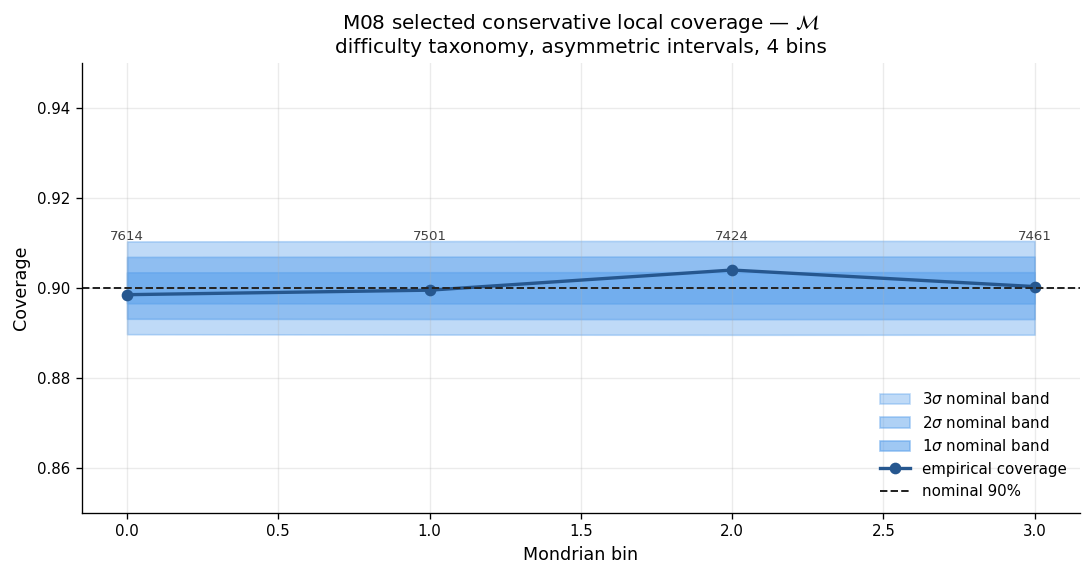

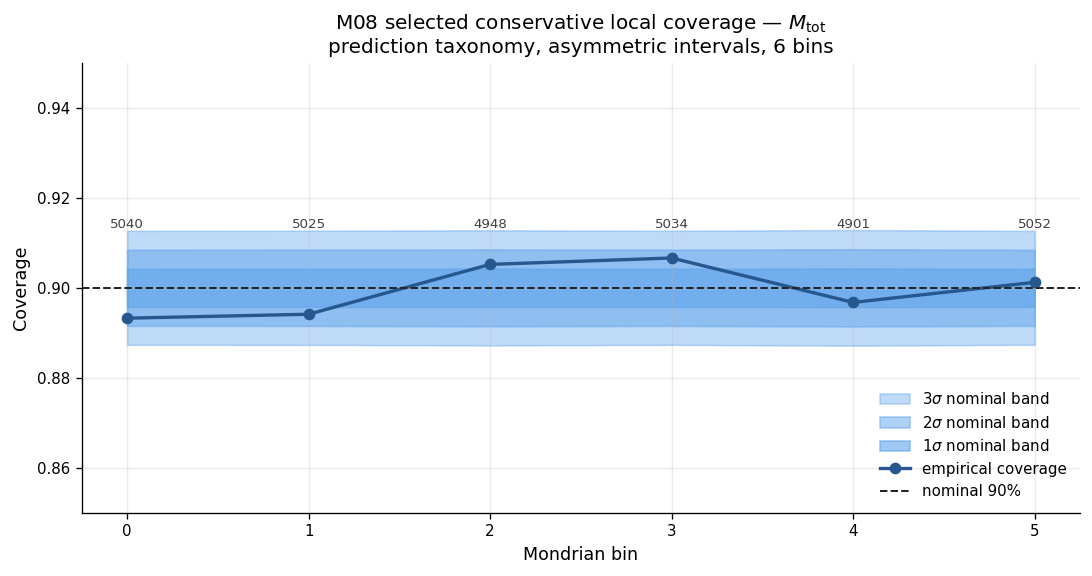

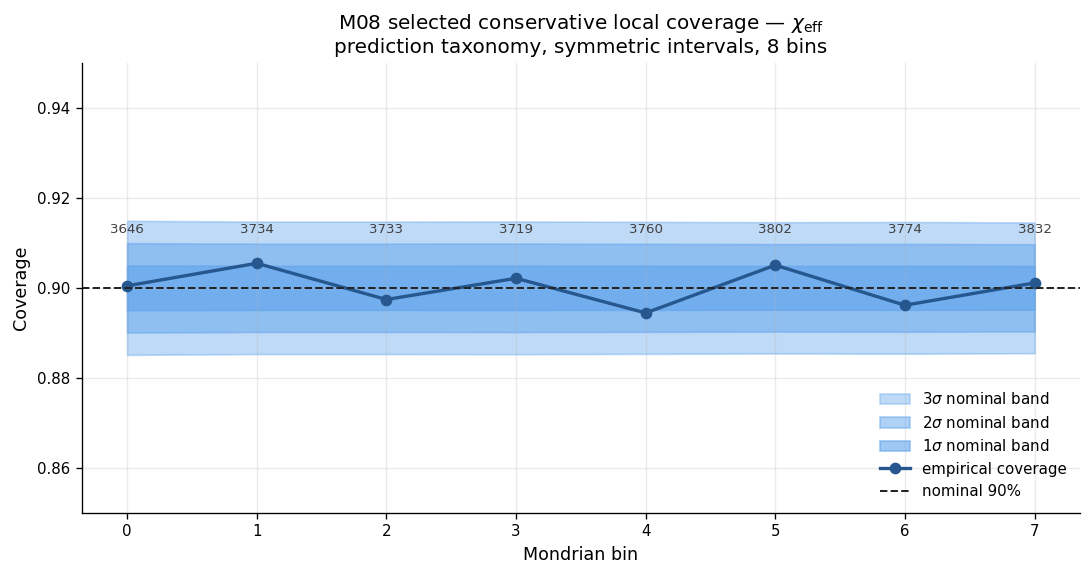

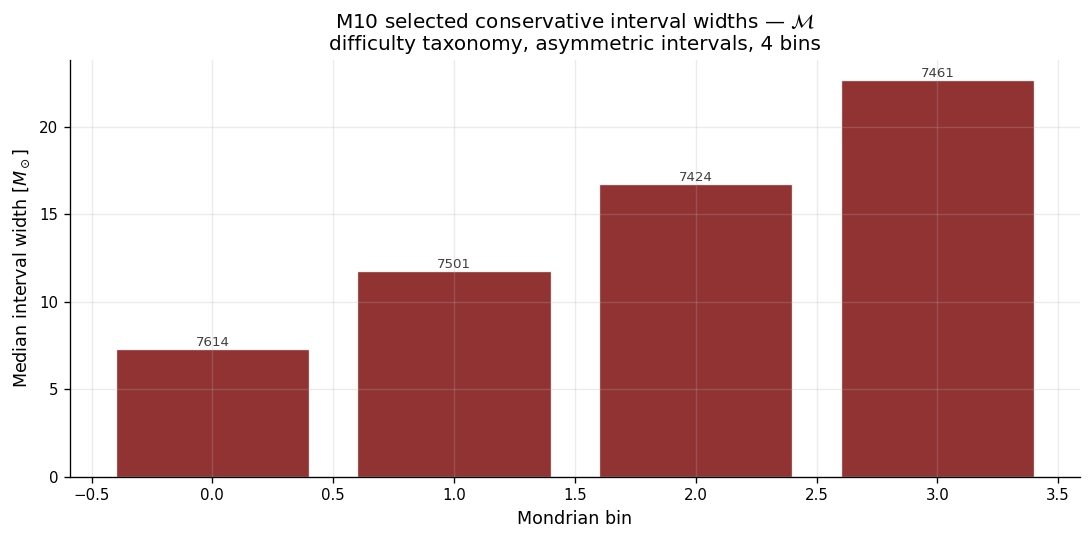

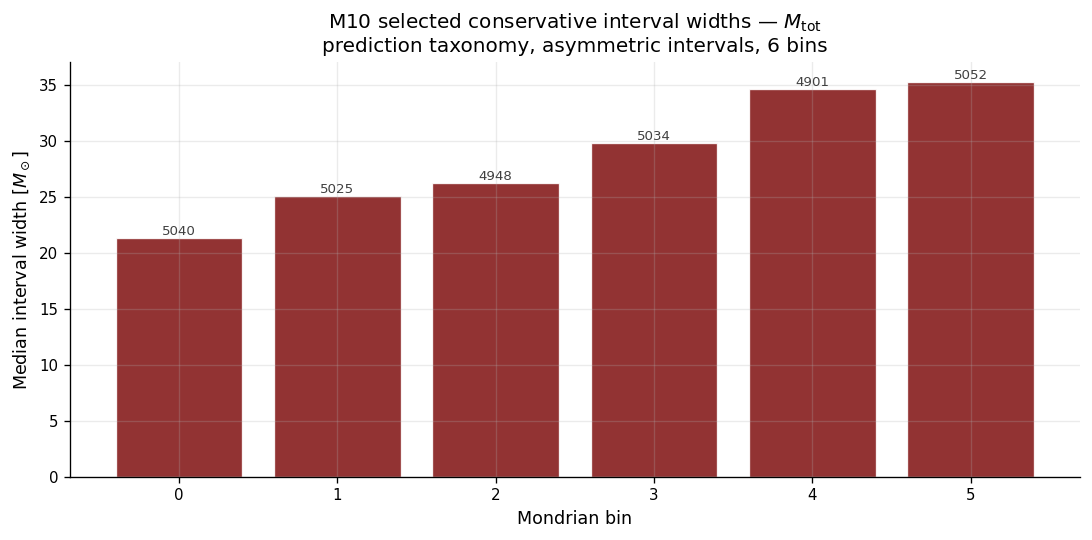

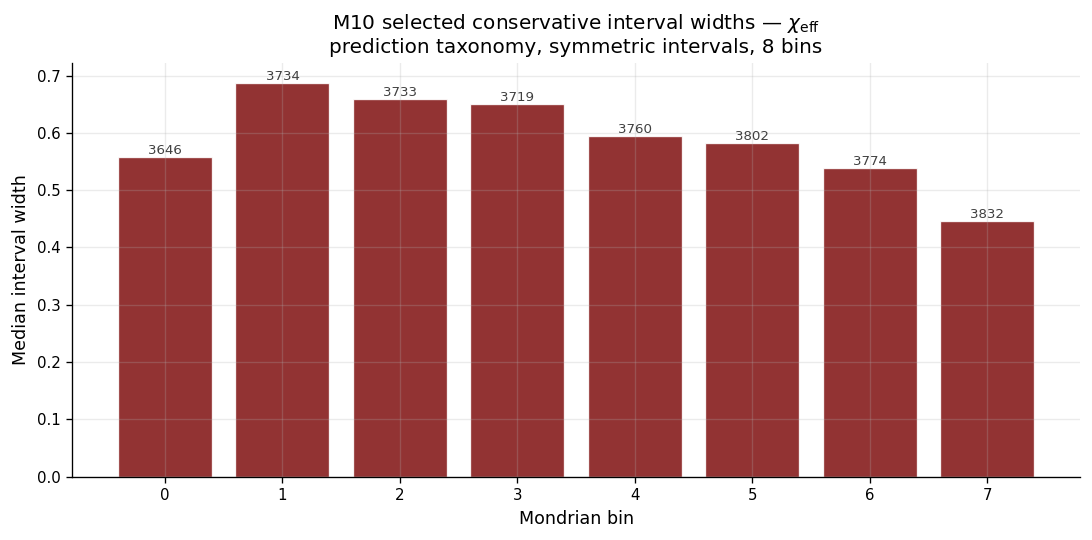

In [10]:
def get_selected_result(label, final_policy="conservative"):
    row = selection_df[
        (selection_df["label"] == label)
        & (selection_df["final_policy"] == final_policy)
    ].iloc[0]

    key = (
        row["taxonomy_mode"],
        row["interval_mode"],
        int(row["n_bins"]),
    )

    return row, all_results[key]


def plot_selected_bin_coverage(final_policy="conservative"):
    for label in label_names:
        label_idx = label_names.index(label)
        row, result = get_selected_result(label, final_policy=final_policy)
        metrics = result.metrics

        coverage = metrics["coverage_per_bin"][:, label_idx]
        counts = metrics["counts_per_bin"][:, label_idx]

        low_1s = metrics["bin_tolerance_normal"]["1sigma_low"][:, label_idx]
        high_1s = metrics["bin_tolerance_normal"]["1sigma_high"][:, label_idx]

        low_2s = metrics["bin_tolerance_normal"]["2sigma_low"][:, label_idx]
        high_2s = metrics["bin_tolerance_normal"]["2sigma_high"][:, label_idx]

        low_3s = metrics["bin_tolerance_normal"]["3sigma_low"][:, label_idx]
        high_3s = metrics["bin_tolerance_normal"]["3sigma_high"][:, label_idx]


        x = np.arange(len(coverage))

        fig, ax = plt.subplots(figsize=(9.2, 4.9))

        ax.fill_between(
            x,
            low_3s,
            high_3s,
            color=PALETTE["band_3"],
            alpha=0.40,
            label=r"$3\sigma$ nominal band",
        )

        ax.fill_between(
            x,
            low_2s,
            high_2s,
            color=PALETTE["band_2"],
            alpha=0.50,
            label=r"$2\sigma$ nominal band",
        )

        ax.fill_between(
            x,
            low_1s,
            high_1s,
            color=PALETTE["band_1"],
            alpha=0.60,
            label=r"$1\sigma$ nominal band",
        )
        ax.plot(
            x,
            coverage,
            marker="o",
            linewidth=2.0,
            color=PALETTE["coverage"],
            label="empirical coverage",
        )
        ax.axhline(
            CONFIDENCE_LEVEL,
            linestyle="--",
            color=PALETTE["nominal"],
            linewidth=1.2,
            label="nominal 90%",
        )

        for xi, n in zip(x, counts):
            ax.text(
                xi,
                min(0.995, max(coverage) + 0.006),
                f"{int(n)}",
                ha="center",
                va="bottom",
                fontsize=8,
                color="0.25",
            )

        ax.set_xlabel("Mondrian bin")
        ax.set_ylabel("Coverage")
        ax.set_title(
            f"M08 selected {final_policy} local coverage — {label_tex(label)}\n"
            f"{row['taxonomy_mode']} taxonomy, {row['interval_mode']} intervals, {int(row['n_bins'])} bins"
        )
        ax.set_ylim(0.85, 0.95)
        ax.legend(loc="lower right")
        style_axis(ax)

        plt.tight_layout()
        plt.show()


def plot_selected_bin_widths(final_policy="conservative"):
    for label in label_names:
        label_idx = label_names.index(label)
        row, result = get_selected_result(label, final_policy=final_policy)

        widths_phys = (result.upper - result.lower)[:, label_idx] * y_std[label_idx]
        bins = result.bin_indices_test[:, label_idx]

        width_by_bin = []
        counts = []

        for b in range(int(row["n_bins"])):
            mask = bins == b
            counts.append(mask.sum())
            width_by_bin.append(np.median(widths_phys[mask]) if mask.any() else np.nan)

        x = np.arange(int(row["n_bins"]))

        fig, ax = plt.subplots(figsize=(9.2, 4.6))
        ax.bar(
            x,
            width_by_bin,
            color=PALETTE["width"],
            alpha=0.88,
            edgecolor="white",
            linewidth=0.8,
        )

        ax.set_xlabel("Mondrian bin")

        unit = label_unit(label)
        ylabel = f"Median interval width [{unit}]" if unit else "Median interval width"
        ax.set_ylabel(ylabel)

        ax.set_title(
            f"M10 selected {final_policy} interval widths — {label_tex(label)}\n"
            f"{row['taxonomy_mode']} taxonomy, {row['interval_mode']} intervals, {int(row['n_bins'])} bins"
        )

        for xi, (w, n) in enumerate(zip(width_by_bin, counts)):
            if np.isfinite(w):
                ax.text(
                    xi,
                    w,
                    f"{int(n)}",
                    ha="center",
                    va="bottom",
                    fontsize=8,
                    color="0.25",
                    rotation=0,
                )

        style_axis(ax)
        plt.tight_layout()
        plt.show()


plot_selected_bin_coverage(final_policy="conservative")
plot_selected_bin_widths(final_policy="conservative")



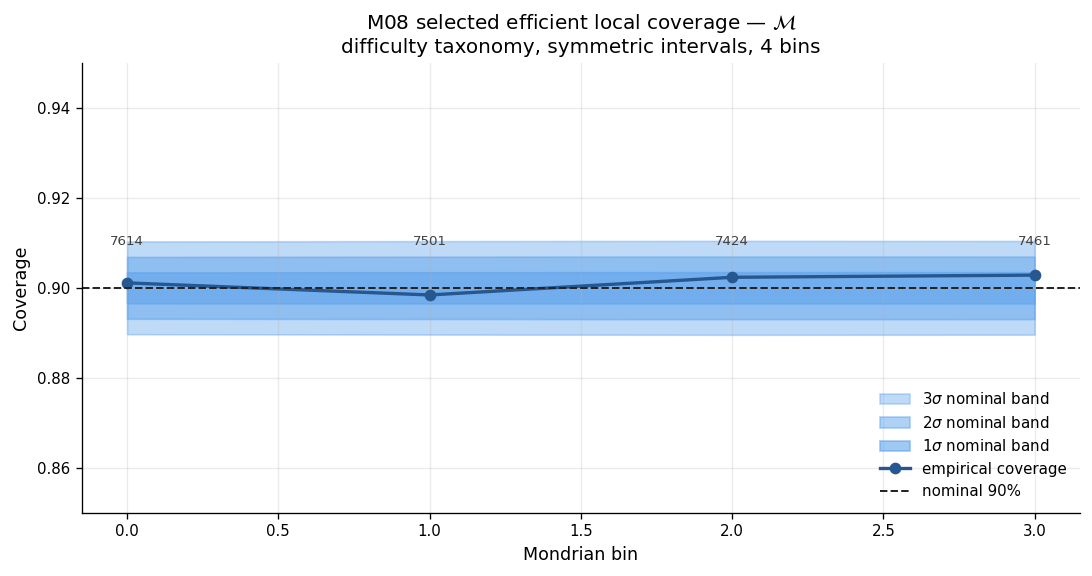

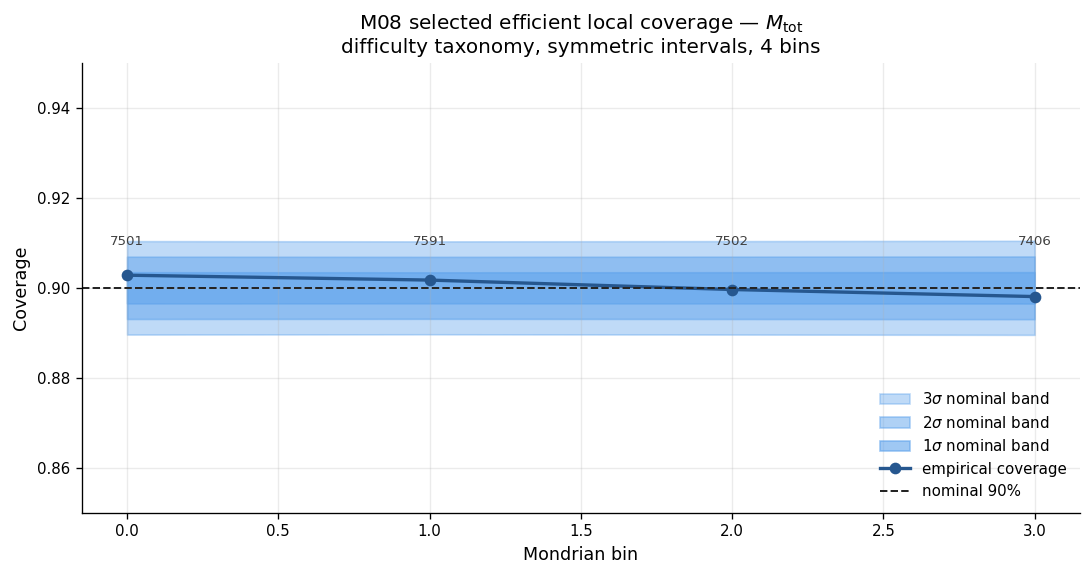

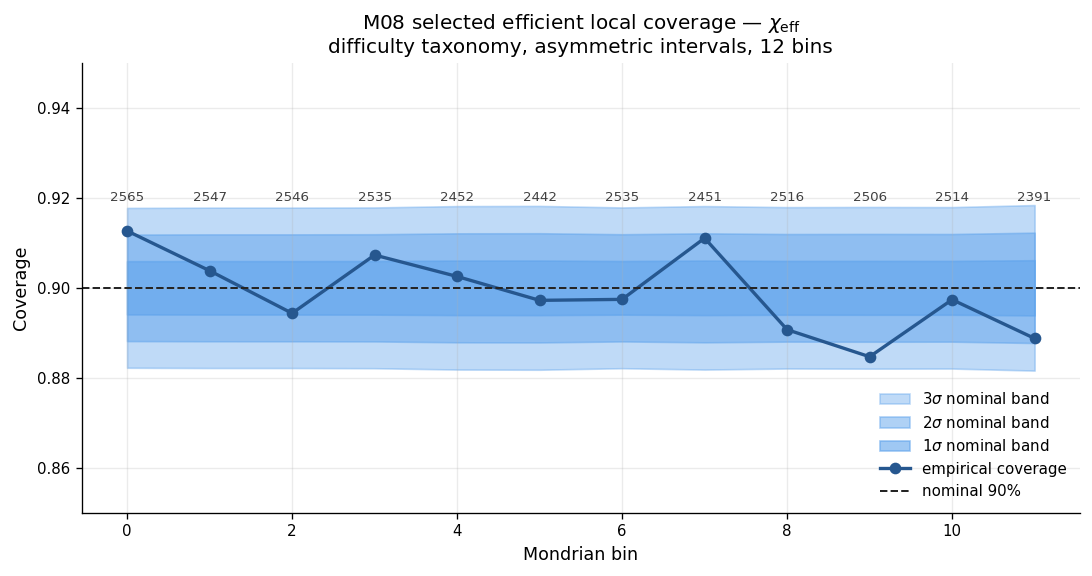

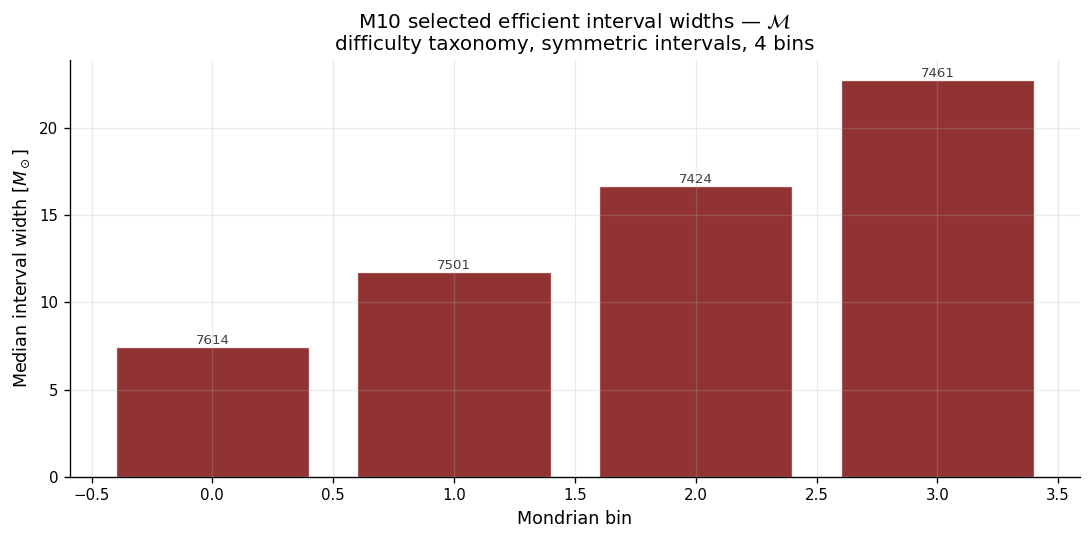

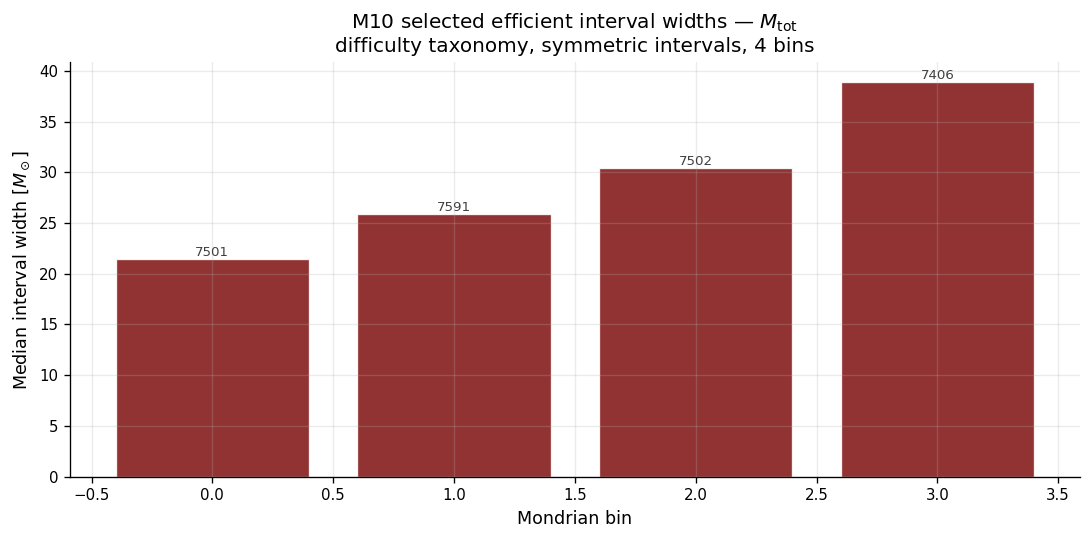

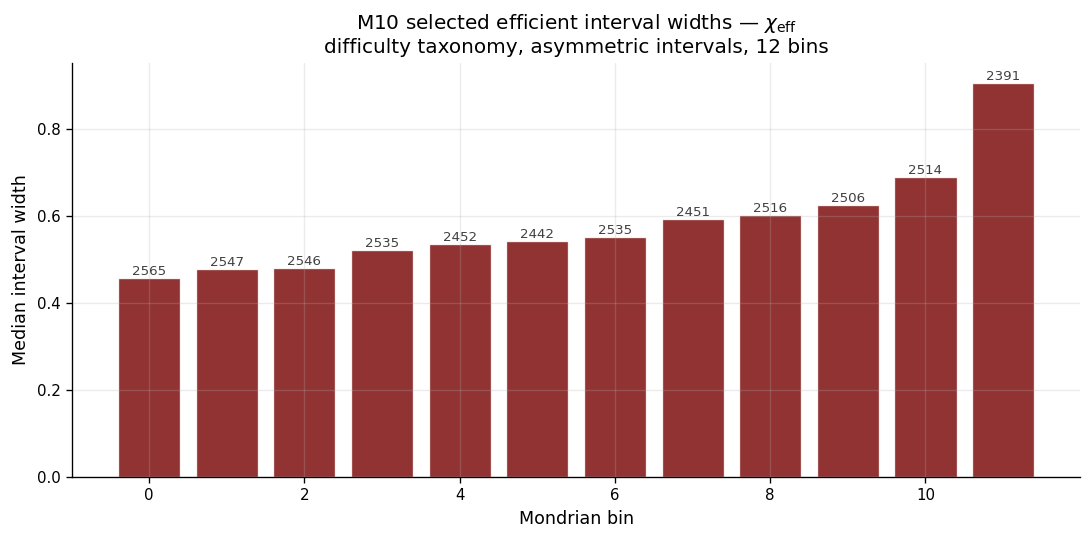

In [11]:
plot_selected_bin_coverage(final_policy="efficient")
plot_selected_bin_widths(final_policy="efficient")

## 11. Conditional diagnostics from HDF5 metadata

This section loads event-level metadata from the HDF5 dataset and uses it to test whether the selected conformal intervals behave uniformly across physically meaningful regions.

The idea is simple:

1. choose a conditioning variable, for example network SNR or true total mass;
2. split the test set into quantile bins of that variable;
3. compute, inside each bin:
   - empirical coverage;
   - median interval width;
   - number of test events.

This is not a new conformal calibration step. It is a **diagnostic**. It asks whether the final selected intervals remain trustworthy in regions such as low SNR, high mass, long signals, or extreme spin.

The most important plots are therefore not only global coverage plots, but conditional coverage/width curves as a function of:

- network SNR, $\rho_{\mathrm{net}}$;
- effective signal duration, $\Delta t_{\mathrm{GW}}$;
- true chirp mass, $\mathcal{M}$;
- true total mass, $M_{\mathrm{tot}}$;
- true effective spin, $\chi_{\mathrm{eff}}$.


In [12]:
import h5py

def read_hdf5_dataset_preserve_order(h5_file, dataset_key, indices, dtype=None):
    indices = np.asarray(indices, dtype=np.int64)
    order = np.argsort(indices, kind="stable")
    sorted_indices = indices[order]

    values_sorted = np.asarray(h5_file[dataset_key][sorted_indices], dtype=dtype)

    inverse_order = np.empty_like(order)
    inverse_order[order] = np.arange(len(order))

    return values_sorted[inverse_order]


def hdf5_key_exists(path):
    with h5py.File(DATASET_H5_PATH, "r") as f:
        return path in f


def load_test_metadata_fields():
    candidate_fields = {
        "network_snr": "snr/network",
        "target_snr": "snr/target_network",
        "mass_1": "parameters/mass_1",
        "mass_2": "parameters/mass_2",
        "chirp_mass": "parameters/chirp_mass",
        "total_mass": "parameters/total_mass",
        "chi_eff": "parameters/chi_eff",
        "distance": "parameters/distance",
        "signal_network_duration": "placement/signal_network_duration",
        "margin_before_signal": "placement/margin_before_signal",
        "margin_after_signal": "placement/margin_after_signal",
    }

    idx = SPLITS["test"]["idx"]
    out = {"hdf5_index": idx}

    with h5py.File(DATASET_H5_PATH, "r") as f:
        for name, key in candidate_fields.items():
            if key in f:
                out[name] = read_hdf5_dataset_preserve_order(f, key, idx)
            else:
                print(f"Missing HDF5 field: {key}")

    return pd.DataFrame(out)


test_meta_df = load_test_metadata_fields()
display(test_meta_df.head())
display(test_meta_df.describe())


,hdf5_index,network_snr,target_snr,mass_1,mass_2,chirp_mass,total_mass,chi_eff,distance,signal_network_duration,margin_before_signal,margin_after_signal
0,10,18.229866,18.229866,63.884521,19.921326,30.072771,83.805847,0.240261,645.598511,0.398438,1.192003,2.409559
1,13,23.198574,23.198574,83.756020,66.471252,64.869446,150.227280,0.488239,2586.593994,0.421143,2.423045,1.155812
2,18,19.833614,19.833614,82.492447,7.385210,19.060570,89.877655,-0.884607,296.434601,0.251221,3.748606,0.000173
3,23,13.214932,13.214932,42.749413,26.913490,29.372425,69.662903,0.015606,2883.240234,0.361816,3.456671,0.181513
4,35,19.602468,19.602468,27.067228,20.961945,20.702566,48.029175,-0.720734,903.000427,0.424561,0.745086,2.830354


,hdf5_index,network_snr,target_snr,mass_1,mass_2,chirp_mass,total_mass,chi_eff,distance,signal_network_duration,margin_before_signal,margin_after_signal
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,249174.097367,16.893896,16.893896,61.713757,33.422291,37.516865,95.136040,0.004608,1706.417358,0.466294,1.771812,1.761894
std,144425.042572,4.346852,4.346852,19.970306,20.088476,16.532505,34.679493,0.440329,1181.676880,0.325068,1.035134,1.036171
min,10.000000,10.000003,10.000003,5.472352,5.000877,4.573939,10.519637,-0.995358,49.751011,0.244629,0.000000,0.000000
25%,123029.500000,13.073044,13.073044,47.397392,16.362895,23.852234,70.192976,-0.333339,820.530624,0.326416,0.876539,0.861497
50%,249600.000000,16.568607,16.568607,65.203869,30.075184,36.254585,95.292068,0.010066,1396.183655,0.371338,1.749381,1.751185
75%,374350.500000,20.613446,20.613446,78.594152,47.589226,50.057863,119.994854,0.343426,2298.970032,0.452393,2.660816,2.647854
max,499985.000000,24.998625,24.998625,89.999557,89.261955,77.771957,178.673126,0.993714,11342.258789,4.000000,3.748606,3.728804


## 12. Conditional coverage and width for selected configurations

In [13]:
def binned_conditional_metrics(values, covered, widths_phys, n_bins=8):
    values = np.asarray(values)
    covered = np.asarray(covered, dtype=bool)
    widths_phys = np.asarray(widths_phys)

    edges = np.quantile(values, np.linspace(0, 1, n_bins + 1))
    edges = np.unique(edges)

    rows = []
    for i, (left, right) in enumerate(zip(edges[:-1], edges[1:])):
        if i == len(edges) - 2:
            mask = (values >= left) & (values <= right)
        else:
            mask = (values >= left) & (values < right)

        if mask.sum() == 0:
            continue

        rows.append({
            "bin": i,
            "left": float(left),
            "right": float(right),
            "center": float(0.5 * (left + right)),
            "count": int(mask.sum()),
            "coverage": float(covered[mask].mean()),
            "median_width_phys": float(np.median(widths_phys[mask])),
            "mean_width_phys": float(np.mean(widths_phys[mask])),
        })

    return pd.DataFrame(rows)


conditional_rows = []
conditional_tables = {}

conditioning_specs = [
    ("network_snr", field_tex("network_snr")),
    ("signal_network_duration", field_tex("signal_network_duration")),
    ("chirp_mass", field_tex("chirp_mass")),
    ("total_mass", field_tex("total_mass")),
    ("chi_eff", field_tex("chi_eff")),
]

for final_policy in ["conservative", "efficient"]:
    for label in label_names:
        label_idx = label_names.index(label)
        row, result = get_selected_result(label, final_policy=final_policy)

        covered = (
            (result.lower[:, label_idx] <= y_test[:, label_idx])
            & (y_test[:, label_idx] <= result.upper[:, label_idx])
        )

        widths_phys = (result.upper - result.lower)[:, label_idx] * y_std[label_idx]

        for field, field_label in conditioning_specs:
            if field not in test_meta_df.columns:
                continue

            table = binned_conditional_metrics(
                values=test_meta_df[field].values,
                covered=covered,
                widths_phys=widths_phys,
                n_bins=8,
            )

            table["final_policy"] = final_policy
            table["label"] = label
            table["label_tex"] = label_tex(label)
            table["conditioning_field"] = field
            table["conditioning_label"] = field_label

            conditional_tables[(final_policy, label, field)] = table
            conditional_rows.append(table)

conditional_metrics_df = pd.concat(conditional_rows, ignore_index=True)
display(conditional_metrics_df.head(20))


,bin,left,right,center,count,coverage,median_width_phys,mean_width_phys,final_policy,label,label_tex,conditioning_field,conditioning_label
0,0,10.000003,11.468305,10.734154,3750,0.816267,16.720632,16.771187,conservative,chirp_mass,$\mathcal{M}$,network_snr,network SNR $\rho_{\mathrm{net}}$
1,1,11.468305,13.073044,12.270674,3750,0.856533,16.720632,15.995087,conservative,chirp_mass,$\mathcal{M}$,network_snr,network SNR $\rho_{\mathrm{net}}$
2,2,13.073044,14.738628,13.905836,3750,0.876800,16.720632,15.177442,conservative,chirp_mass,$\mathcal{M}$,network_snr,network SNR $\rho_{\mathrm{net}}$
3,3,14.738628,16.568607,15.653618,3750,0.896267,11.775588,14.446869,conservative,chirp_mass,$\mathcal{M}$,network_snr,network SNR $\rho_{\mathrm{net}}$
4,4,16.568607,18.530117,17.549362,3750,0.921333,11.775588,14.026382,conservative,chirp_mass,$\mathcal{M}$,network_snr,network SNR $\rho_{\mathrm{net}}$
5,5,18.530117,20.613446,19.571781,3750,0.932533,11.775588,13.505073,conservative,chirp_mass,$\mathcal{M}$,network_snr,network SNR $\rho_{\mathrm{net}}$
6,6,20.613446,22.737675,21.675560,3750,0.942933,11.775588,13.356407,conservative,chirp_mass,$\mathcal{M}$,network_snr,network SNR $\rho_{\mathrm{net}}$
7,7,22.737675,24.998625,23.868150,3750,0.961600,11.775588,13.270772,conservative,chirp_mass,$\mathcal{M}$,network_snr,network SNR $\rho_{\mathrm{net}}$
8,0,0.244629,0.304199,0.274414,3745,0.849933,16.720632,17.529551,conservative,chirp_mass,$\mathcal{M}$,signal_network_duration,signal duration $\Delta t_{\mathrm{GW}}$ [s]
9,1,0.304199,0.326416,0.315308,3751,0.892029,16.720632,17.144819,conservative,chirp_mass,$\mathcal{M}$,signal_network_duration,signal duration $\Delta t_{\mathrm{GW}}$ [s]


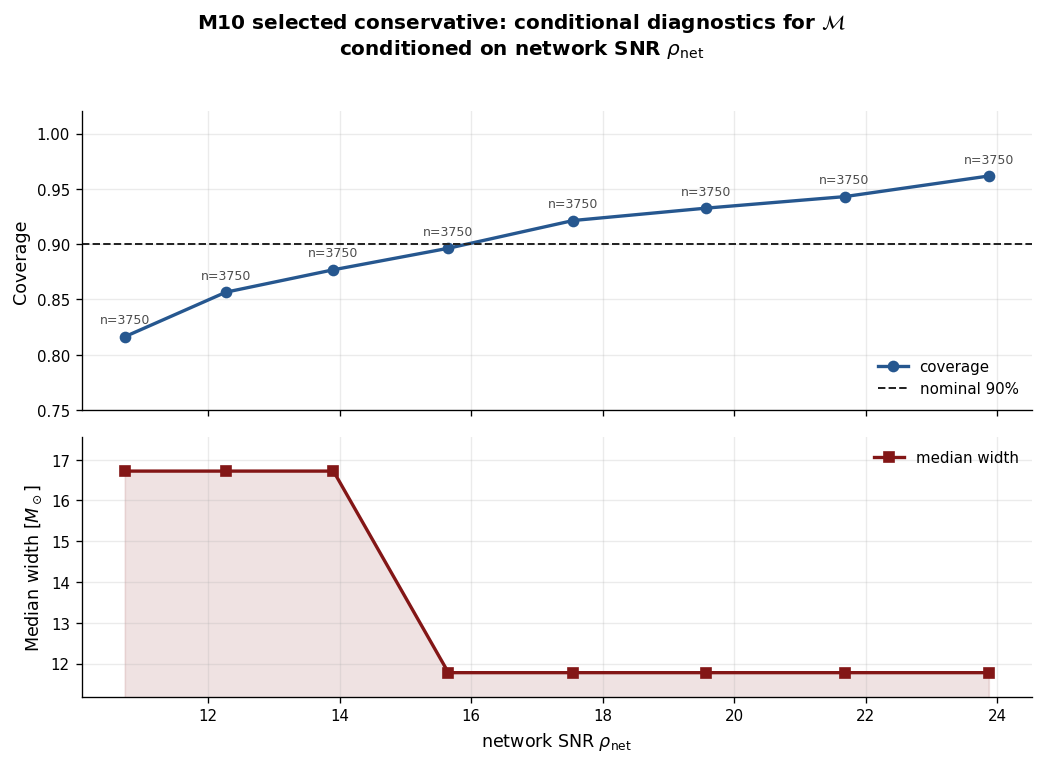

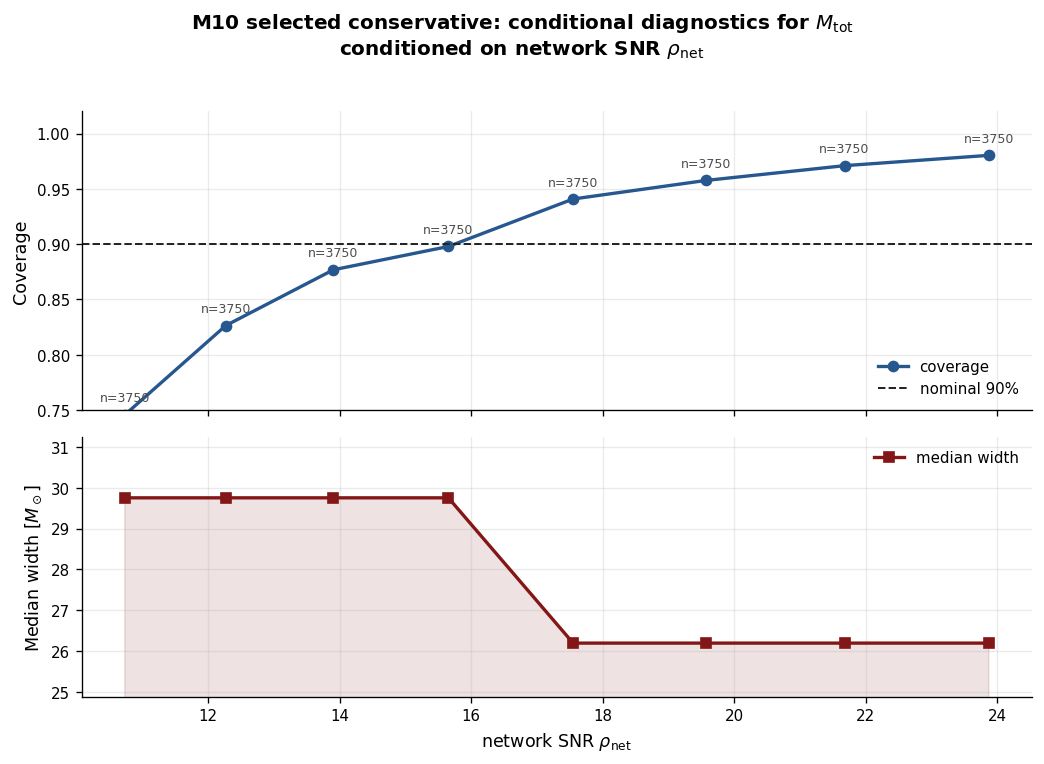

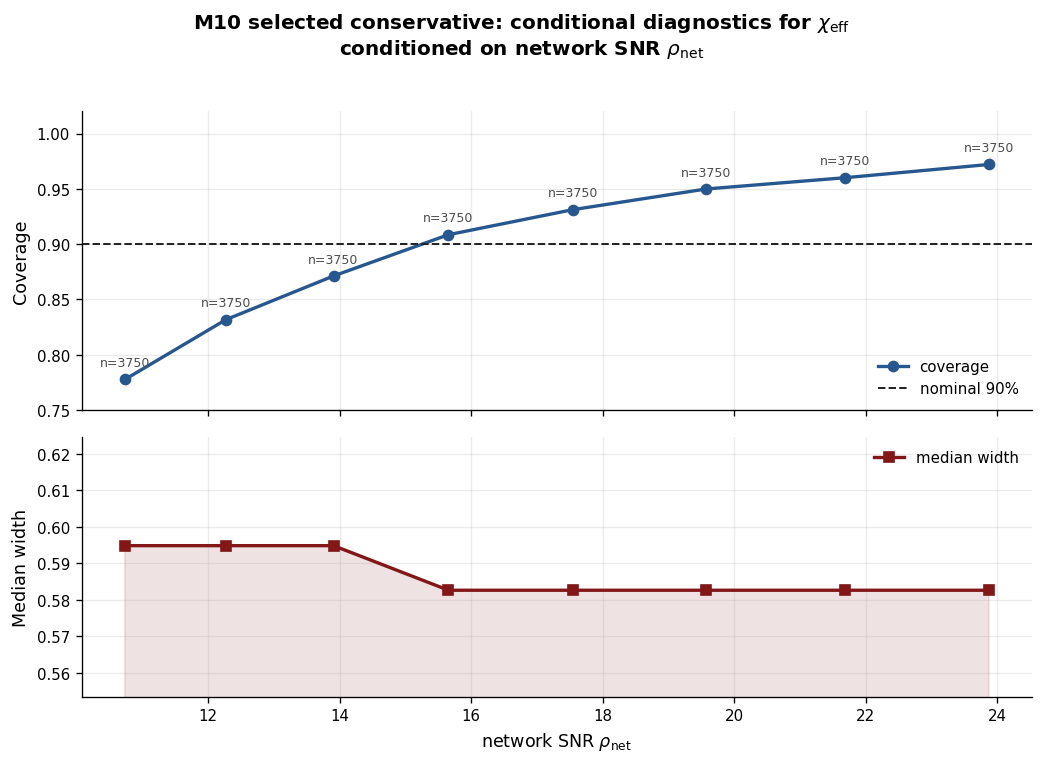

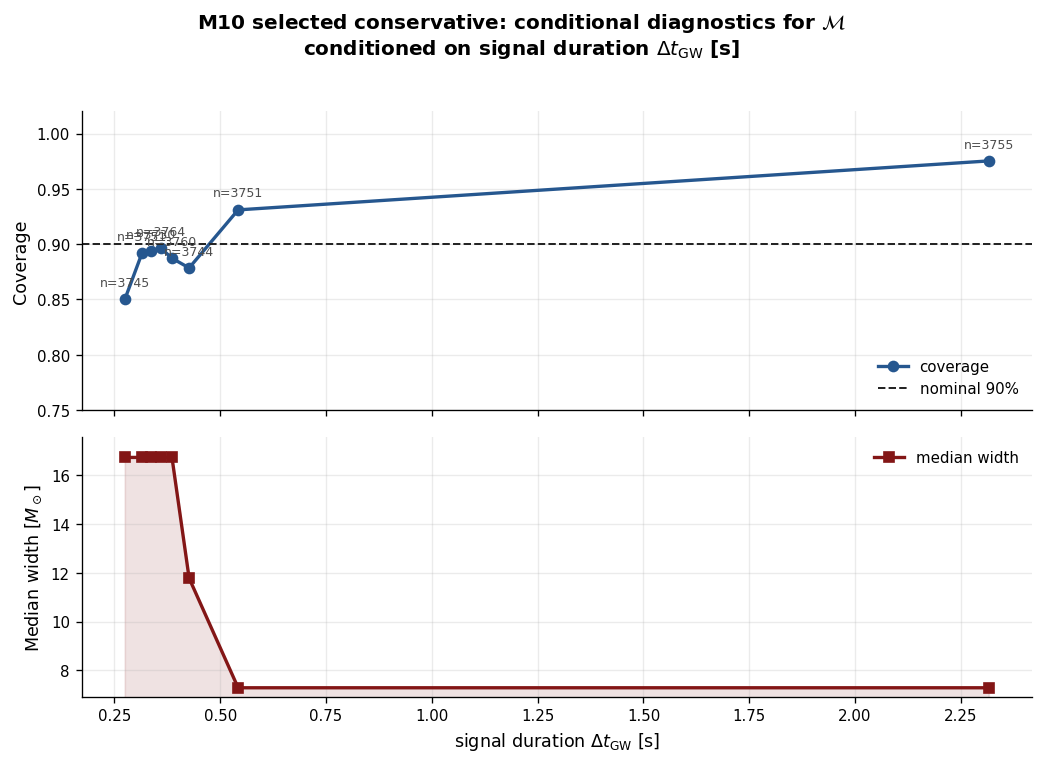

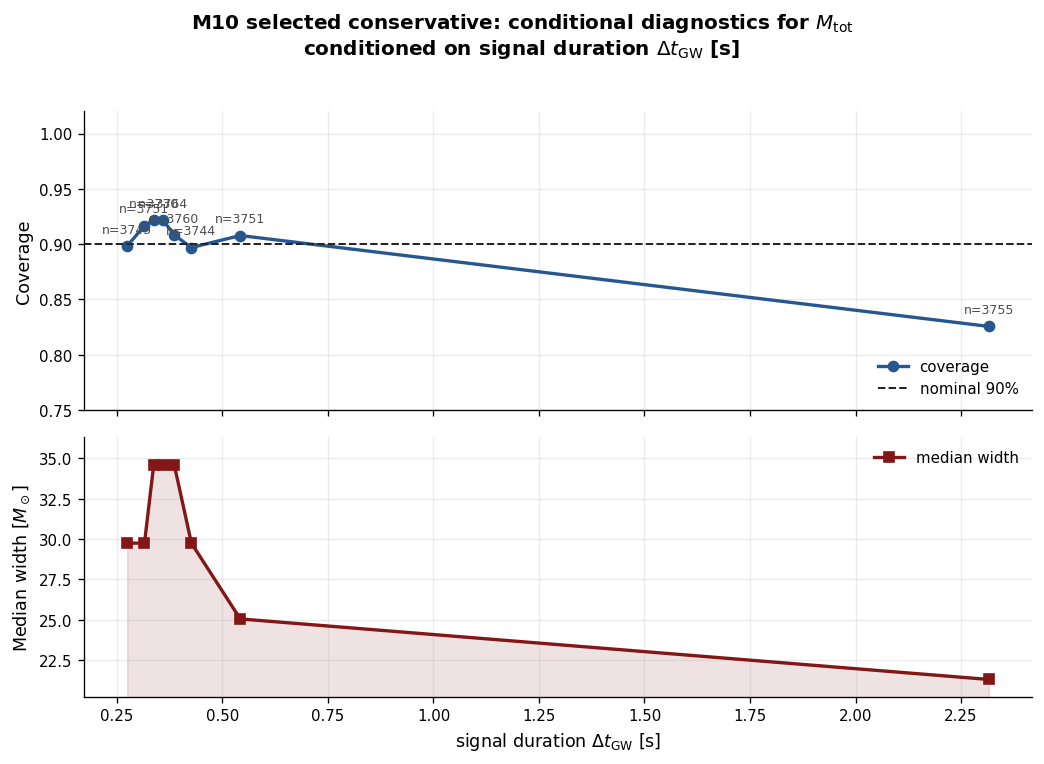

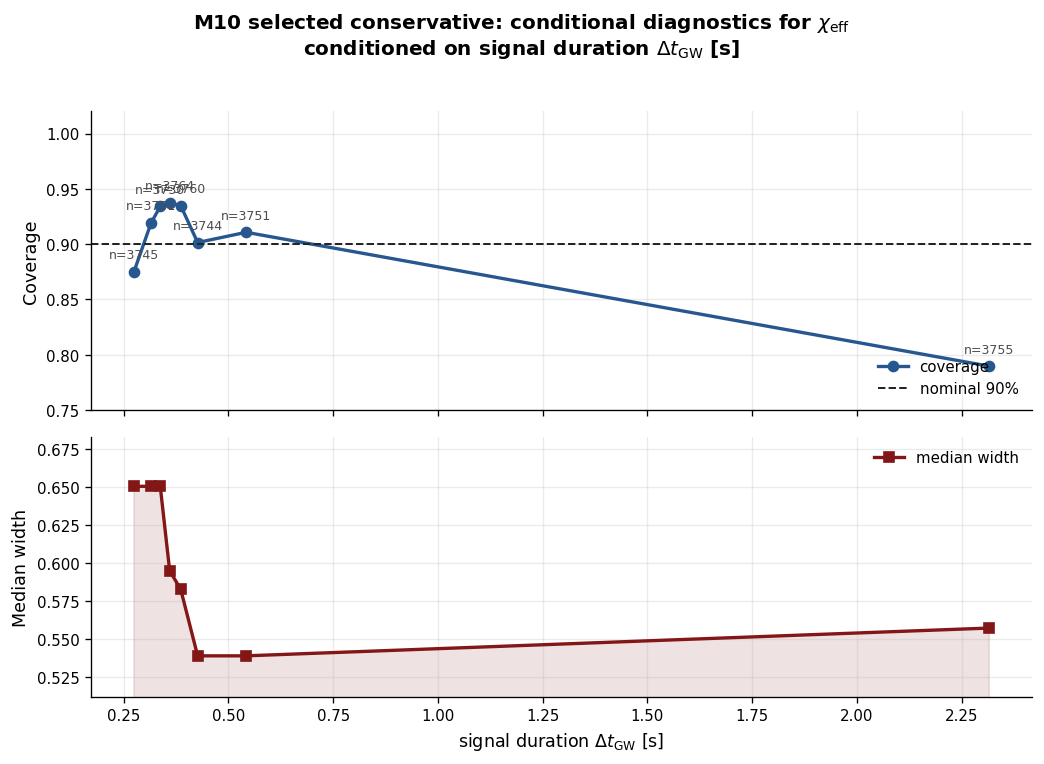

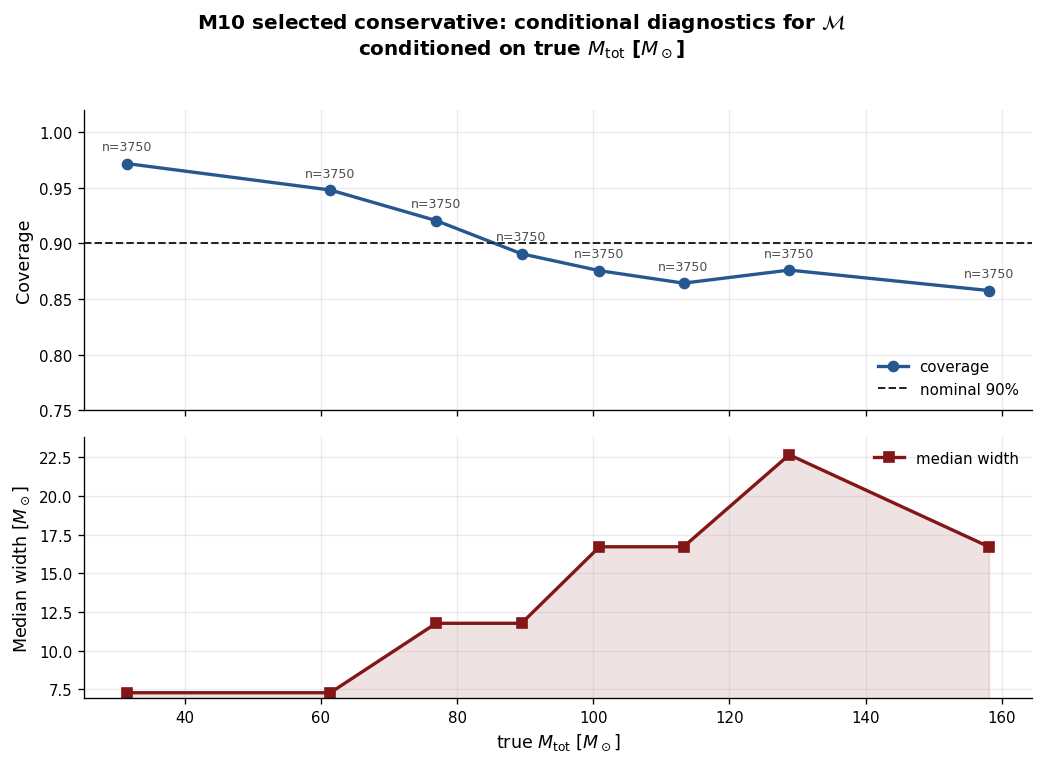

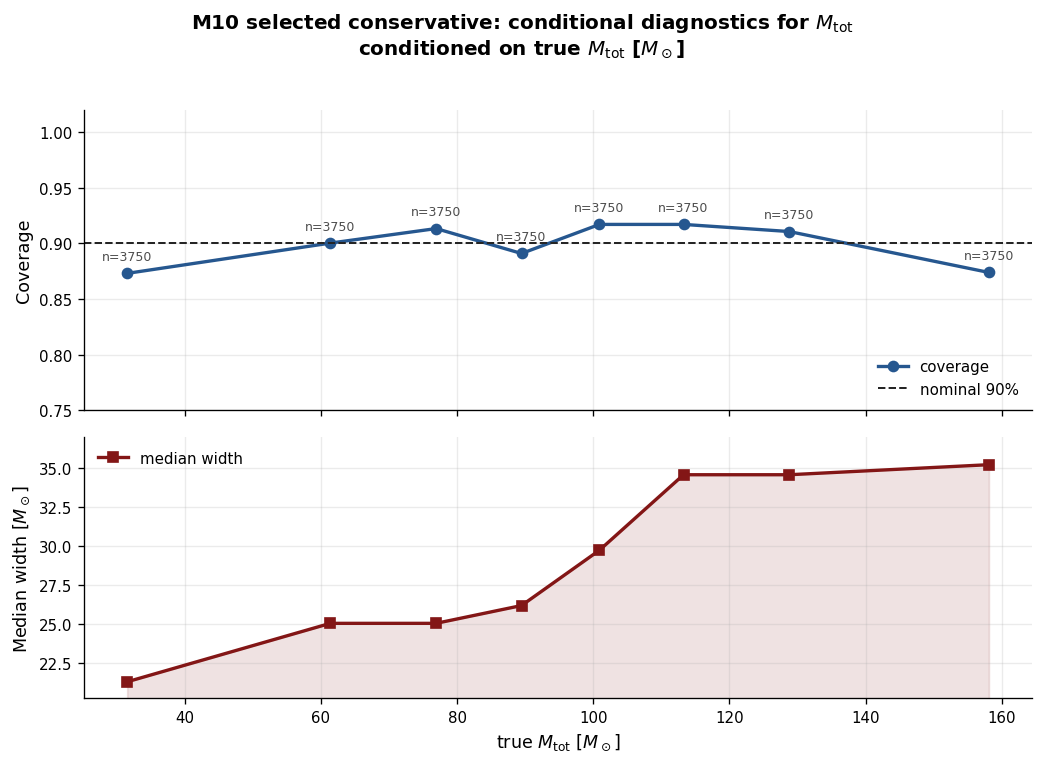

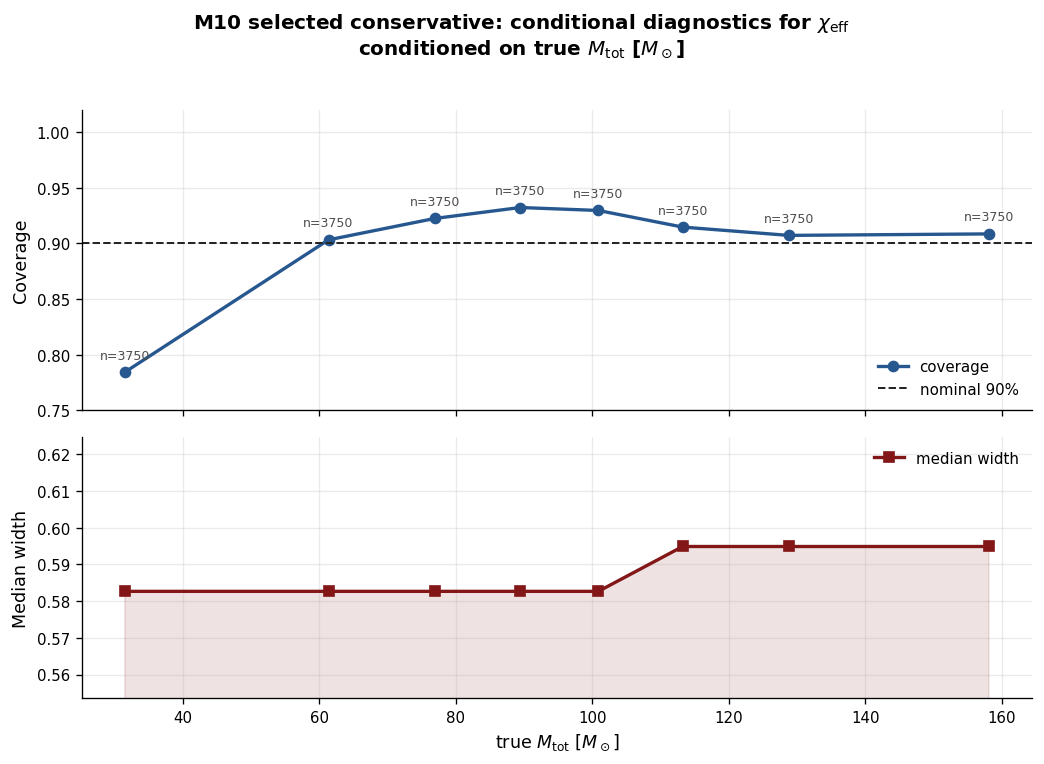

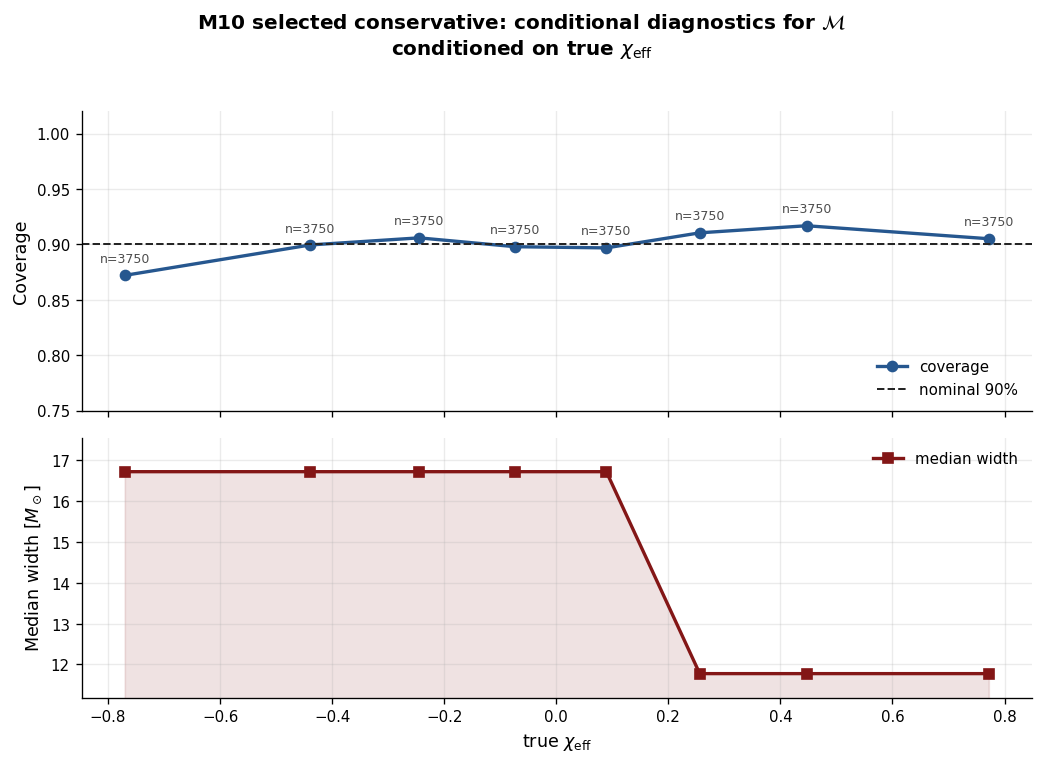

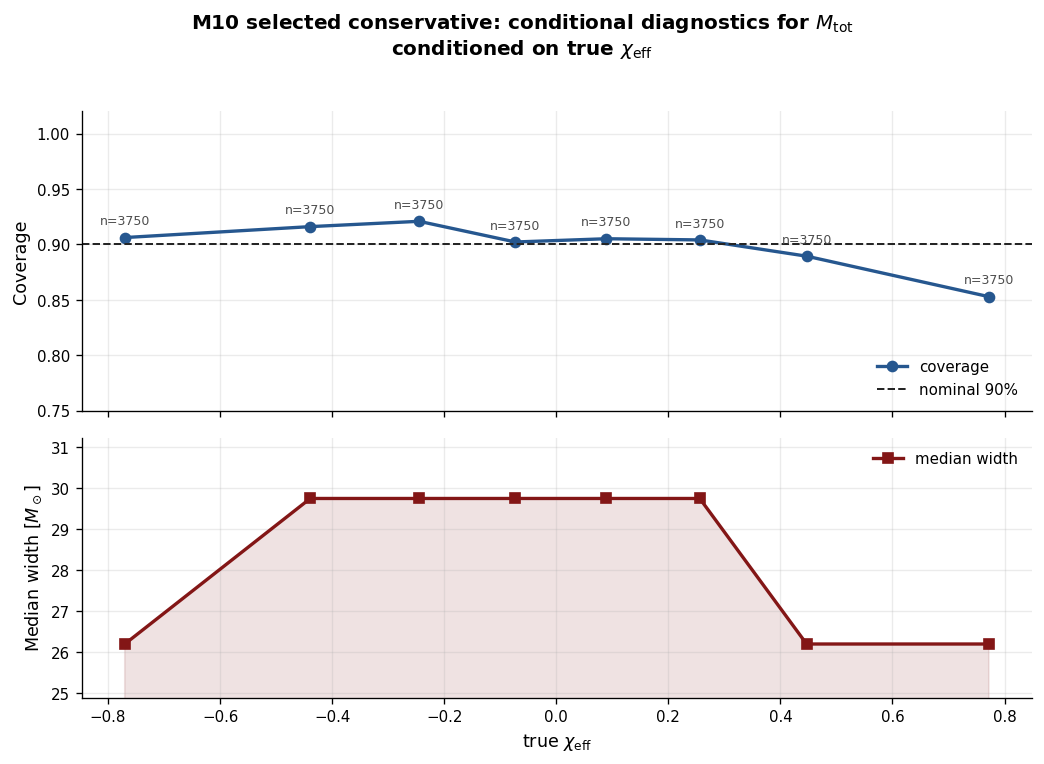

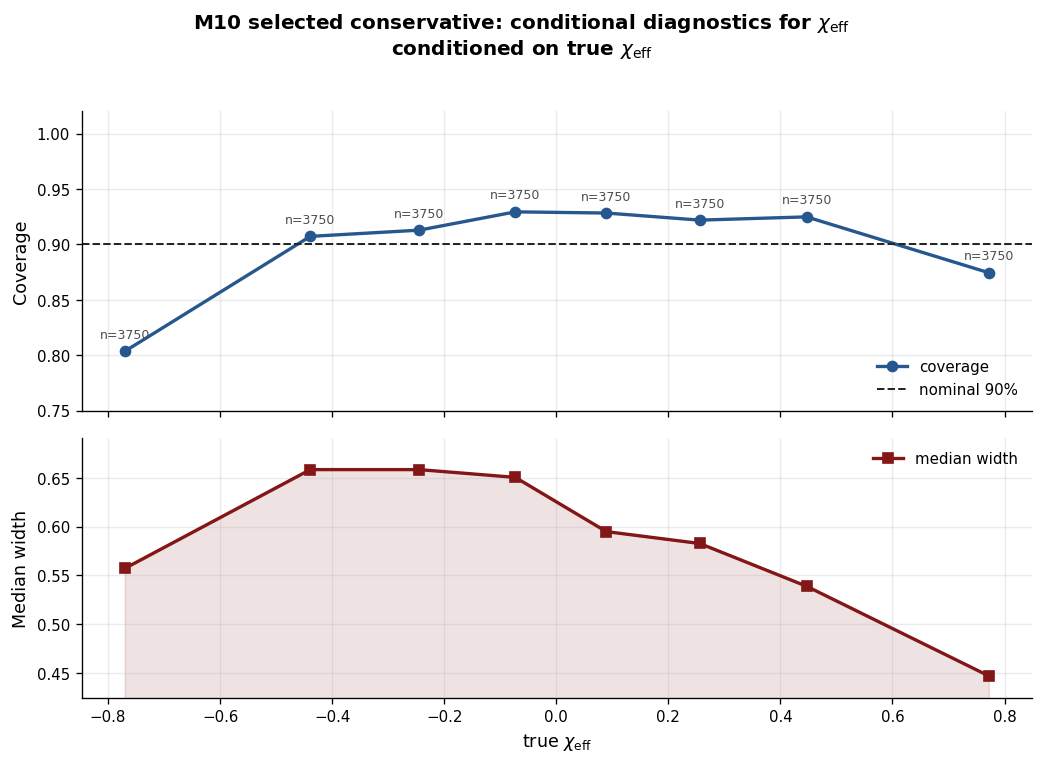

In [14]:
def plot_conditional_metrics(field="network_snr", final_policy="conservative"):
    for label in label_names:
        key = (final_policy, label, field)
        if key not in conditional_tables:
            print("Missing:", key)
            continue

        table = conditional_tables[key].copy()
        x = table["center"].values

        fig, (ax_cov, ax_width) = plt.subplots(
            2,
            1,
            figsize=(8.8, 6.2),
            sharex=True,
            gridspec_kw={"height_ratios": [1.15, 1.0]},
        )

        # Coverage panel
        ax_cov.plot(
            x,
            table["coverage"],
            marker="o",
            linewidth=2.0,
            color=PALETTE["coverage"],
            label="coverage",
        )
        ax_cov.axhline(
            CONFIDENCE_LEVEL,
            linestyle="--",
            linewidth=1.2,
            color=PALETTE["nominal"],
            label="nominal 90%",
        )
        ax_cov.set_ylabel("Coverage")
        ax_cov.set_ylim(0.75, 1.02)
        ax_cov.legend(loc="lower right")
        style_axis(ax_cov)

        for xi, cov, n in zip(x, table["coverage"], table["count"]):
            ax_cov.text(
                xi,
                min(1.005, cov + 0.012),
                f"n={int(n)}",
                fontsize=7.5,
                ha="center",
                color="0.30",
            )

        # Width panel
        ax_width.plot(
            x,
            table["median_width_phys"],
            marker="s",
            linewidth=2.0,
            color=PALETTE["width"],
            label="median width",
        )
        ax_width.fill_between(
            x,
            table["median_width_phys"],
            alpha=0.12,
            color=PALETTE["width"],
        )

        unit = label_unit(label)
        width_label = f"Median width [{unit}]" if unit else "Median width"
        ax_width.set_ylabel(width_label)
        ax_width.set_xlabel(table["conditioning_label"].iloc[0])
        ax_width.set_ylim(0.95 * min(table["median_width_phys"]), 1.05 * max(table["median_width_phys"]))
        ax_width.legend(loc="best")
        style_axis(ax_width)

        fig.suptitle(
            f"M10 selected {final_policy}: conditional diagnostics for {label_tex(label)}\n"
            f"conditioned on {table['conditioning_label'].iloc[0]}",
            y=1.02,
            fontsize=12,
            fontweight="semibold",
        )

        plt.tight_layout()
        plt.show()


for field in ["network_snr", "signal_network_duration", "total_mass", "chi_eff"]:
    if field in test_meta_df.columns:
        plot_conditional_metrics(field=field, final_policy="conservative")


## 13. Final selected systems

In [15]:
def summarize_selected_systems():
    rows = []

    for final_policy in ["conservative", "efficient"]:
        for label in label_names:
            label_idx = label_names.index(label)
            row, result = get_selected_result(label, final_policy=final_policy)

            widths_phys = (result.upper - result.lower)[:, label_idx] * y_std[label_idx]
            covered = (
                (result.lower[:, label_idx] <= y_test[:, label_idx])
                & (y_test[:, label_idx] <= result.upper[:, label_idx])
            )

            rows.append({
                "final_policy": final_policy,
                "label": label,
                "taxonomy_mode": row["taxonomy_mode"],
                "interval_mode": row["interval_mode"],
                "n_bins": int(row["n_bins"]),
                "coverage": float(covered.mean()),
                "median_width_phys": float(np.median(widths_phys)),
                "q90_width_phys": float(np.quantile(widths_phys, 0.90)),
                "q95_width_phys": float(np.quantile(widths_phys, 0.95)),
                "min_coverage_per_bin": row["min_coverage_per_bin"],
                "n_bins_under_2sigma": int(row["n_bins_under_2sigma"]),
                "max_undercoverage_gap": row["max_undercoverage_gap"],
                "tail_miss_imbalance": row["global_tail_miss_imbalance"],
            })

    return pd.DataFrame(rows)


selected_systems_df = summarize_selected_systems()
display(selected_systems_df)


,final_policy,label,taxonomy_mode,interval_mode,n_bins,coverage,median_width_phys,q90_width_phys,q95_width_phys,min_coverage_per_bin,n_bins_under_2sigma,max_undercoverage_gap,tail_miss_imbalance
0,conservative,chirp_mass,difficulty,asymmetric,4,0.900533,11.775588,22.665657,22.665657,0.898476,0,0.001524,0.000600
1,conservative,total_mass,prediction,asymmetric,6,0.899533,26.199136,35.239614,35.239614,0.893254,0,0.006746,0.001200
2,conservative,chi_eff,prediction,symmetric,8,0.900267,0.582661,0.687546,0.687546,0.894415,0,0.005585,0.023600
3,efficient,chirp_mass,difficulty,symmetric,4,0.901167,11.731975,22.774741,22.774741,0.898414,0,0.001586,0.008233
4,efficient,total_mass,difficulty,symmetric,4,0.900567,25.844899,38.893264,38.893264,0.898056,0,0.001944,0.009567
5,efficient,chi_eff,difficulty,asymmetric,12,0.899033,0.543044,0.691346,0.907825,0.884677,1,0.015323,0.000167


### Compact report summary

In [16]:
def format_selected_systems_for_report(selected_systems_df):
    """
    Produce a compact text summary from selected_systems_df.
    Execute after selected_systems_df has been computed.
    """
    lines = []

    for policy in ["conservative", "efficient"]:
        sub = selected_systems_df[selected_systems_df["final_policy"] == policy]

        lines.append(f"\n{policy.upper()} SELECTED SYSTEMS")
        lines.append("-" * 80)

        for _, row in sub.iterrows():
            label = row["label"]
            unit = label_unit(label)

            width_unit = f" {unit}" if unit else ""

            lines.append(
                f"{label_tex(label)}: "
                f"{row['taxonomy_mode']} / {row['interval_mode']} / "
                f"{int(row['n_bins'])} bins | "
                f"coverage={row['coverage']:.4f}, "
                f"median width={row['median_width_phys']:.4g}{width_unit}, "
                f"q95 width={row['q95_width_phys']:.4g}{width_unit}, "
                f"min bin coverage={row['min_coverage_per_bin']:.4f}, "
                f"under-2σ bins={int(row['n_bins_under_2sigma'])}"
            )

    return "\n".join(lines)


print(format_selected_systems_for_report(selected_systems_df))



CONSERVATIVE SELECTED SYSTEMS
--------------------------------------------------------------------------------
$\mathcal{M}$: difficulty / asymmetric / 4 bins | coverage=0.9005, median width=11.78 $M_\odot$, q95 width=22.67 $M_\odot$, min bin coverage=0.8985, under-2σ bins=0
$M_{\mathrm{tot}}$: prediction / asymmetric / 6 bins | coverage=0.8995, median width=26.2 $M_\odot$, q95 width=35.24 $M_\odot$, min bin coverage=0.8933, under-2σ bins=0
$\chi_{\mathrm{eff}}$: prediction / symmetric / 8 bins | coverage=0.9003, median width=0.5827, q95 width=0.6875, min bin coverage=0.8944, under-2σ bins=0

EFFICIENT SELECTED SYSTEMS
--------------------------------------------------------------------------------
$\mathcal{M}$: difficulty / symmetric / 4 bins | coverage=0.9012, median width=11.73 $M_\odot$, q95 width=22.77 $M_\odot$, min bin coverage=0.8984, under-2σ bins=0
$M_{\mathrm{tot}}$: difficulty / symmetric / 4 bins | coverage=0.9006, median width=25.84 $M_\odot$, q95 width=38.89 $M_\odot$,

## 14. Save tables

In [17]:
OUTPUT_DIR = RESULTS_ROOT / "mondrian_M10_final_baseline"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

tables = {
    "point_metrics.csv": point_metrics_df,
    "global_point_metrics.csv": global_point_metrics_df,
    "global_conformal.csv": global_conformal_df,
    "mondrian_summary_all.csv": summary_df,
    "grid_aggregate_summary.csv": grid_agg_df,
    "selected_configurations.csv": selection_df,
    "top_candidates.csv": top_candidates_df,
    "selected_systems_summary.csv": selected_systems_df,
    "test_metadata.csv": test_meta_df,
    "conditional_metrics.csv": conditional_metrics_df,
}

for filename, dataframe in tables.items():
    path = OUTPUT_DIR / filename
    dataframe.to_csv(path, index=False)
    print("Saved:", path)

try:
    report_text = format_selected_systems_for_report(selected_systems_df)
    report_path = OUTPUT_DIR / "selected_systems_report.txt"
    report_path.write_text(report_text, encoding="utf-8")
    print("Saved:", report_path)
except Exception as exc:
    print("Report text not saved:", type(exc).__name__, exc)


Saved: /data/vserrano/cbc_pe_data/results/mondrian_M10_final_baseline/point_metrics.csv
Saved: /data/vserrano/cbc_pe_data/results/mondrian_M10_final_baseline/global_point_metrics.csv
Saved: /data/vserrano/cbc_pe_data/results/mondrian_M10_final_baseline/global_conformal.csv
Saved: /data/vserrano/cbc_pe_data/results/mondrian_M10_final_baseline/mondrian_summary_all.csv
Saved: /data/vserrano/cbc_pe_data/results/mondrian_M10_final_baseline/grid_aggregate_summary.csv
Saved: /data/vserrano/cbc_pe_data/results/mondrian_M10_final_baseline/selected_configurations.csv
Saved: /data/vserrano/cbc_pe_data/results/mondrian_M10_final_baseline/top_candidates.csv
Saved: /data/vserrano/cbc_pe_data/results/mondrian_M10_final_baseline/selected_systems_summary.csv
Saved: /data/vserrano/cbc_pe_data/results/mondrian_M10_final_baseline/test_metadata.csv
Saved: /data/vserrano/cbc_pe_data/results/mondrian_M10_final_baseline/conditional_metrics.csv
Saved: /data/vserrano/cbc_pe_data/results/mondrian_M10_final_basel

## 15. Final discussion and decision

### Baseline decision

M10 input-zscore is adopted as the final model variant for this real-event transfer analysis. Compared with the original M08 baseline, M10 keeps strong synthetic point-estimation performance while substantially improving robustness to detector-dependent scale differences in real GWOSC strain.

The final conformal calibration is performed on the 400k/40k/30k/30k split using the M10 checkpoint trained with per-sample, per-detector input z-score normalization. The selected conservative Mondrian systems are used as the default final uncertainty model, because they achieve approximately nominal global coverage and avoid undercoverage beyond the two-sigma bin tolerance criterion for all targets.

The efficient systems are retained as a secondary comparison, but the conservative policy is preferred for real-event application.

### What the point-estimation diagnostics show

The true-vs-predicted and residual-density plots are important because they show the main remaining limitation of the point estimator.

The model performs well in the dense central region of the training distribution, but the residual-density plots reveal regression-to-the-mean behavior in the tails:

- low true masses tend to be overestimated;
- high true masses tend to be underestimated;
- extreme $\chi_{\mathrm{eff}}$ values are compressed toward the central region.

This is not primarily a conformal-calibration problem. Conformal intervals can restore coverage, but they do not remove bias from the point predictor. If the predictor is biased in the tails, conformal intervals tend to become wider or locally less efficient in those regions.

### Why Mondrian conformal is still useful

The global split-conformal baseline gives one residual scale per target. This is valid as a broad reference, but it ignores the fact that the residual distribution changes across prediction regions, difficulty regimes, SNR, and physical parameter values.

Mondrian conformal calibration is used to adapt the interval width locally. The final selected configurations should therefore be reported per target rather than as a single universal setting.

The final compact result is `selected_systems_df`. For each target, report:

- taxonomy mode;
- interval mode;
- number of bins;
- global coverage;
- median physical interval width;
- q90/q95 physical width;
- minimum bin coverage;
- number of bins below the two-sigma lower tolerance;
- maximum undercoverage gap;
- tail-miss imbalance.

### Conditional diagnostics

The conditional diagnostics are not used to fit the intervals. They are a stress test of the selected systems.

They answer questions such as:

- does coverage remain close to 90% at low SNR?
- do intervals become wider for long or difficult signals?
- do high-mass or extreme-spin regions show local undercoverage?
- is the selected Mondrian taxonomy actually controlling the regions where the point model is biased?

These plots should be used in the discussion section to avoid overclaiming purely global coverage.

### Recommended report wording

```text
M08 is adopted as the final baseline for the conformal analysis. The selected
Mondrian configurations achieve empirical coverage close to the nominal 90%
level while providing target-dependent interval widths. The chosen configurations
differ across chirp mass, total mass, and effective spin, reflecting the
different residual structures of the three regression targets.

The conditional diagnostics show that global coverage alone is not sufficient:
coverage and interval width vary across SNR, signal duration, and regions of the
physical parameter space. Mondrian calibration partially adapts to this
heterogeneity, but the residual-density plots show that the dominant remaining
limitation is regression to the mean in the point estimator, especially in the
tails of the mass and effective-spin distributions.
```

### Next step

Do not continue with small architecture variants at this stage.

The next separate analysis should focus specifically on regression to the mean in the point estimator. Reasonable candidates are:

1. weighted MSE or tail-aware losses;
2. SmoothL1/Huber losses compared against MSE;
3. loss terms that penalize slope contraction;
4. target transformations;
5. sampling or reweighting by physical parameter bins;
6. post-hoc linear or isotonic recalibration;
7. checking whether any correction improves slope and tail bias without degrading conformal validity.

This should be treated as a new modelling notebook/thread, not mixed into the final Mondrian baseline notebook.


_______________________

## Plots production

In [18]:
# ============================================================
# 14. Academic-style Mondrian figures (clean presentation style)
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

MOND_FIG_DIR = OUTPUT_DIR / "figures_academic"
MOND_FIG_DIR.mkdir(parents=True, exist_ok=True)
print("Saving Mondrian figures to:", MOND_FIG_DIR)

# ------------------------------------------------------------
# Presentation-style palette: blue/grey academic + soft accents
# ------------------------------------------------------------
MOND_COLORS = {
    "bg": "#F5F7FA",
    "box": "#EAF1F7",
    "text": "#1F2D3A",
    "title": "#243B53",
    "muted": "#526D82",
    "grid": "#D7DEE8",

    "coverage": "#6F91B6",
    "coverage_dark": "#243B53",
    "width": "#A56C6C",
    "width_dark": "#7B4C4C",

    "nominal": "#243B53",
    "band1": "#D9E8F5",
    "band2": "#BDD5EA",
    "band3": "#A7C3DF",

    "global": "#C3CDD9",
    "global_edge": "#738496",

    "conservative": "#6F91B6",
    "efficient": "#9CBFA7",

    "prediction": "#6F91B6",
    "difficulty": "#B4A974",

    "symmetric": "#7FA7A6",
    "asymmetric": "#D59B8A",

    "highlight": "#D8A6A6",
    "warning": "#D8A6A6",
}

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "axes.edgecolor": MOND_COLORS["grid"],
    "axes.labelcolor": MOND_COLORS["text"],
    "xtick.color": MOND_COLORS["text"],
    "ytick.color": MOND_COLORS["text"],
    "text.color": MOND_COLORS["text"],
    "axes.titlecolor": MOND_COLORS["title"],
    "axes.titlesize": 15,
    "axes.labelsize": 12,
    "font.size": 12,
    "legend.fontsize": 10,
    "axes.grid": True,
    "grid.color": MOND_COLORS["grid"],
    "grid.alpha": 0.55,
    "grid.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

def style_axis_clean(ax):
    ax.grid(True, alpha=0.55, linewidth=0.8, color=MOND_COLORS["grid"])
    ax.tick_params(axis="both", labelsize=10)
    return ax

def savefig_clean(fig, name):
    png_path = MOND_FIG_DIR / f"{name}.png"
    pdf_path = MOND_FIG_DIR / f"{name}.pdf"
    fig.savefig(png_path, dpi=250, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    print("Saved:", png_path.name, "and", pdf_path.name)

def selected_widths_phys(result, label_idx):
    return (result.upper - result.lower)[:, label_idx] * y_std[label_idx]

def selected_covered_mask(result, label_idx):
    return (
        (result.lower[:, label_idx] <= y_test[:, label_idx]) &
        (y_test[:, label_idx] <= result.upper[:, label_idx])
    )

def config_text(row):
    return f"{row['taxonomy_mode']} | {row['interval_mode']} | {int(row['n_bins'])} bins"

def short_config_text(row):
    return f"{row['taxonomy_mode'][:4]} / {row['interval_mode'][:5]} / {int(row['n_bins'])}"

def get_global_baseline_row(label):
    row = global_conformal_df[global_conformal_df["label"] == label].iloc[0]
    return row

Saving Mondrian figures to: /data/vserrano/cbc_pe_data/results/mondrian_M10_final_baseline/figures_academic


Saved: mondrian_selected_local_coverage_conservative.png and mondrian_selected_local_coverage_conservative.pdf


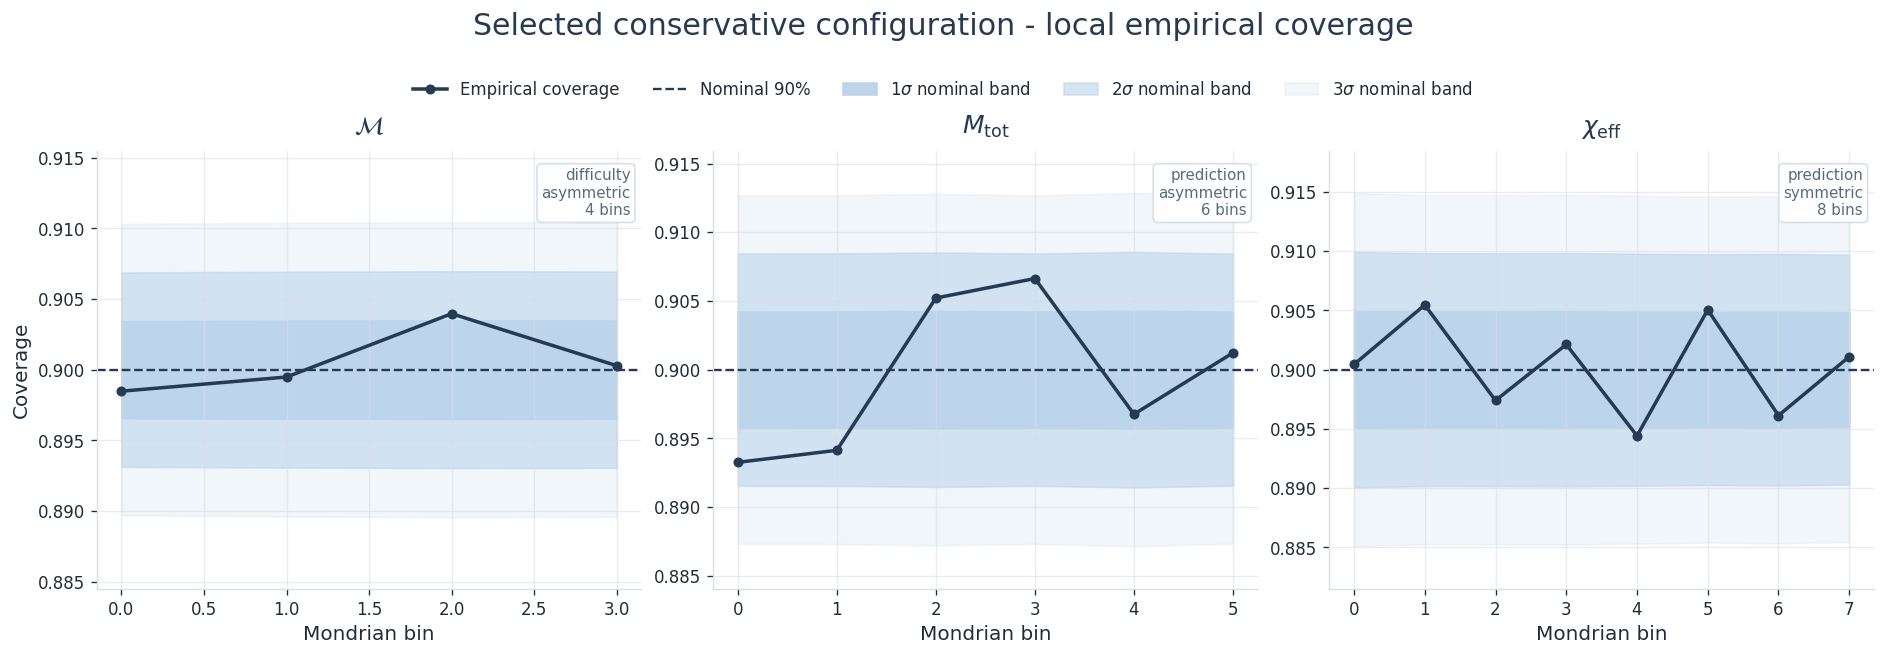

Saved: mondrian_selected_local_coverage_efficient.png and mondrian_selected_local_coverage_efficient.pdf


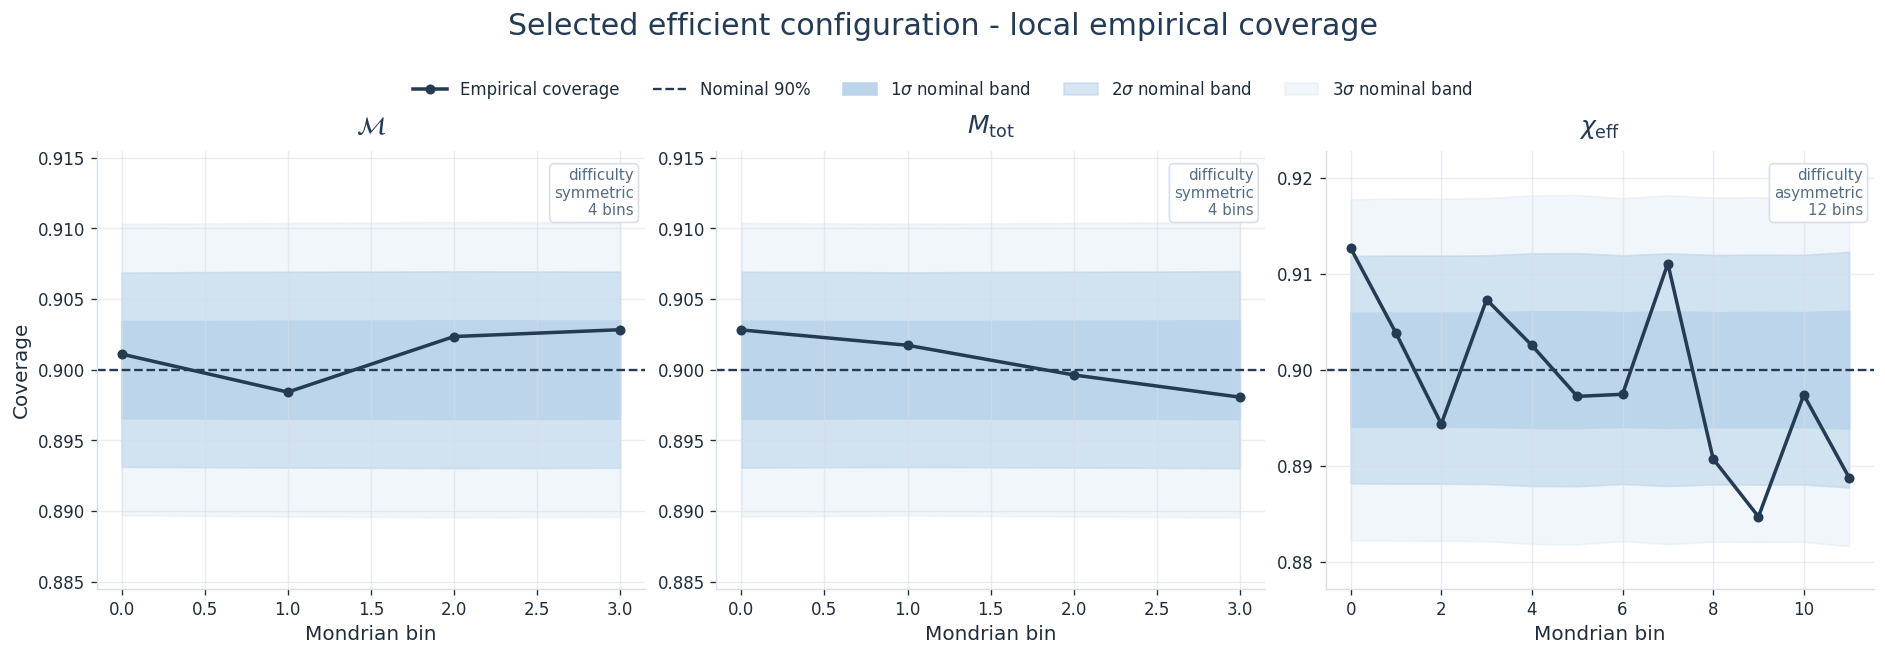

In [19]:
# ============================================================
# 15. Selected local-coverage plots
#     One figure per policy: conservative / efficient
#     Independent y-axis per target
# ============================================================

def plot_selected_coverage_policy(final_policy="conservative", save=True):
    ncols = len(label_names)

    fig, axes = plt.subplots(
        1,
        ncols,
        figsize=(5.2 * ncols, 4.5),
        sharey=False,   # important: independent y-axis per parameter
        constrained_layout=True,
    )

    if ncols == 1:
        axes = [axes]

    for j, label in enumerate(label_names):
        ax = axes[j]

        label_idx = label_names.index(label)
        row, result = get_selected_result(label, final_policy=final_policy)
        metrics = result.metrics

        coverage = metrics["coverage_per_bin"][:, label_idx]

        low_1s = metrics["bin_tolerance_normal"]["1sigma_low"][:, label_idx]
        high_1s = metrics["bin_tolerance_normal"]["1sigma_high"][:, label_idx]

        low_2s = metrics["bin_tolerance_normal"]["2sigma_low"][:, label_idx]
        high_2s = metrics["bin_tolerance_normal"]["2sigma_high"][:, label_idx]

        low_3s = metrics["bin_tolerance_normal"]["3sigma_low"][:, label_idx]
        high_3s = metrics["bin_tolerance_normal"]["3sigma_high"][:, label_idx]

        x = np.arange(len(coverage))

        # Bands: widest first
        band3 = ax.fill_between(
            x,
            low_3s,
            high_3s,
            color=MOND_COLORS["band2"],
            alpha=0.20,
            label=r"$3\sigma$ nominal band",
        )
        band2 = ax.fill_between(
            x,
            low_2s,
            high_2s,
            color=MOND_COLORS["band2"],
            alpha=0.60,
            label=r"$2\sigma$ nominal band",
        )
        band1 = ax.fill_between(
            x,
            low_1s,
            high_1s,
            color=MOND_COLORS["band2"],
            alpha=1.00,
            label=r"$1\sigma$ nominal band",
        )

        line_cov, = ax.plot(
            x,
            coverage,
            marker="o",
            markersize=5,
            linewidth=2.1,
            color=MOND_COLORS["coverage_dark"],
            label="empirical coverage",
        )

        line_nom = ax.axhline(
            CONFIDENCE_LEVEL,
            linestyle="--",
            linewidth=1.4,
            color=MOND_COLORS["nominal"],
            label=f"nominal {int(CONFIDENCE_LEVEL * 100)}%",
        )

        ax.set_xlabel("Mondrian bin")

        if j == 0:
            ax.set_ylabel("Coverage")
        else:
            ax.set_ylabel("")

        ax.set_title(f"{label_tex(label)}", pad=10)

        # Config box: upper right
        meta = (
            f"{row['taxonomy_mode']}\n"
            f"{row['interval_mode']}\n"
            f"{int(row['n_bins'])} bins"
        )

        ax.text(
            0.98,
            0.96,
            meta,
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=9,
            color=MOND_COLORS["muted"],
            bbox=dict(
                boxstyle="round,pad=0.30",
                facecolor="white",
                edgecolor=MOND_COLORS["grid"],
                alpha=0.96,
            ),
        )

        # ----------------------------------------------------
        # Independent y-limits per target.
        # Include coverage, nominal line, and all tolerance bands.
        # ----------------------------------------------------
        y_values = np.concatenate([
            coverage,
            low_3s,
            high_3s,
            low_2s,
            high_2s,
            low_1s,
            high_1s,
            np.array([CONFIDENCE_LEVEL]),
        ])

        y_min = np.nanmin(y_values)
        y_max = np.nanmax(y_values)
        y_range = y_max - y_min

        # Avoid over-zooming if the range is tiny.
        min_range = 0.025
        if y_range < min_range:
            center = 0.5 * (y_min + y_max)
            y_min = center - 0.5 * min_range
            y_max = center + 0.5 * min_range
            y_range = min_range

        margin = 0.12 * y_range

        ax.set_ylim(
            max(0.0, y_min - margin),
            min(1.0, y_max + margin),
        )

        style_axis_clean(ax)

    # Shared legend
    handles = [line_cov, line_nom, band1, band2, band3]
    labels = [
        "Empirical coverage",
        f"Nominal {int(CONFIDENCE_LEVEL * 100)}%",
        r"$1\sigma$ nominal band",
        r"$2\sigma$ nominal band",
        r"$3\sigma$ nominal band",
    ]

    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=5,
        frameon=False,
        bbox_to_anchor=(0.5, 1.08),
        fontsize=10,
    )

    fig.suptitle(
        f"Selected {final_policy} configuration - local empirical coverage",
        fontsize=18,
        color=MOND_COLORS["title"],
        y=1.18,
    )

    if save:
        savefig_clean(fig, f"mondrian_selected_local_coverage_{final_policy}")

    plt.show()


plot_selected_coverage_policy(final_policy="conservative")
plot_selected_coverage_policy(final_policy="efficient")

Saved: mondrian_selected_interval_widths_conservative_median_global.png and mondrian_selected_interval_widths_conservative_median_global.pdf


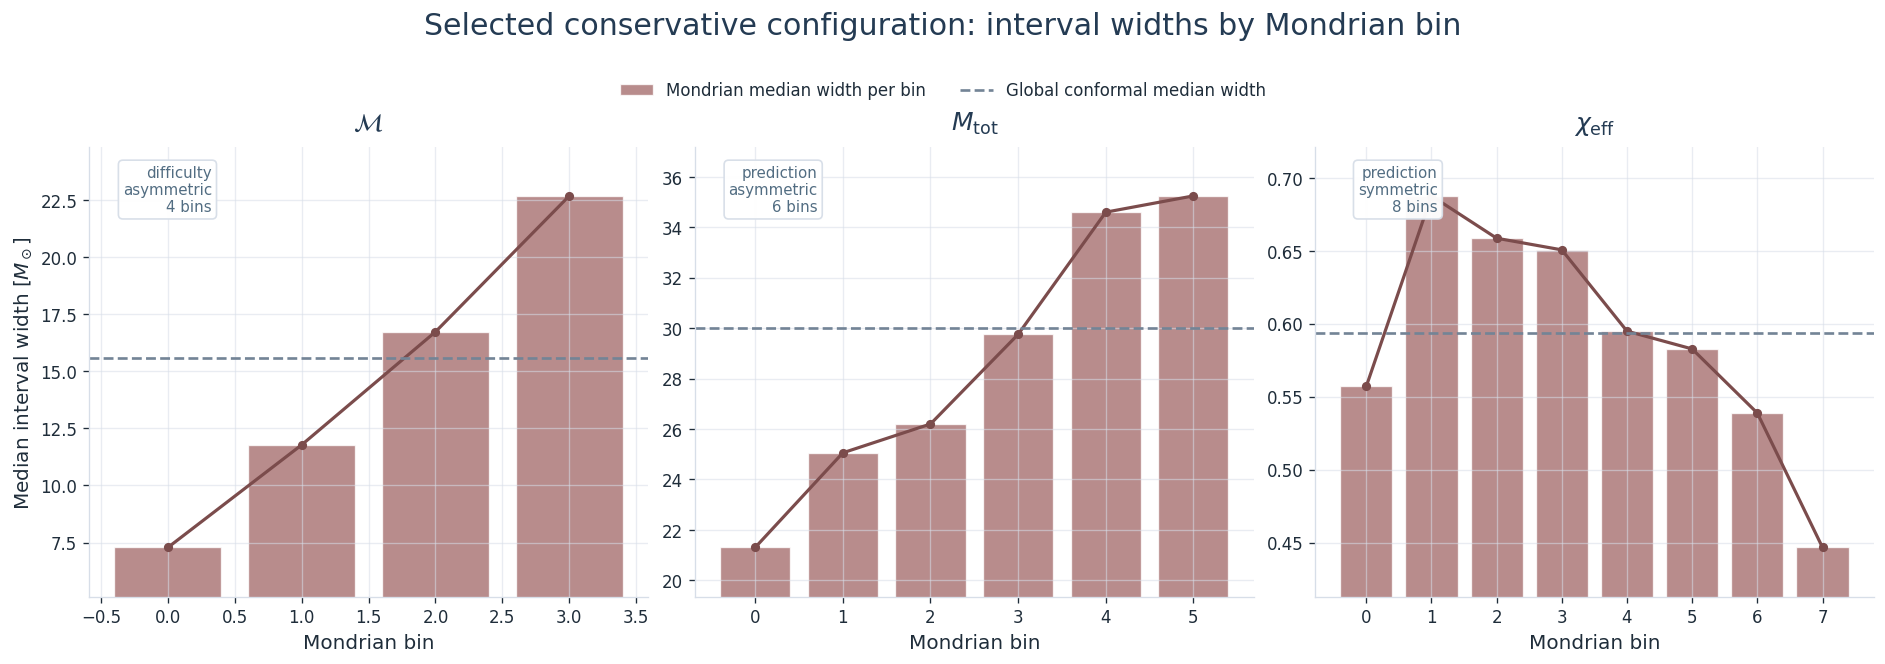

Saved: mondrian_selected_interval_widths_efficient_median_global.png and mondrian_selected_interval_widths_efficient_median_global.pdf


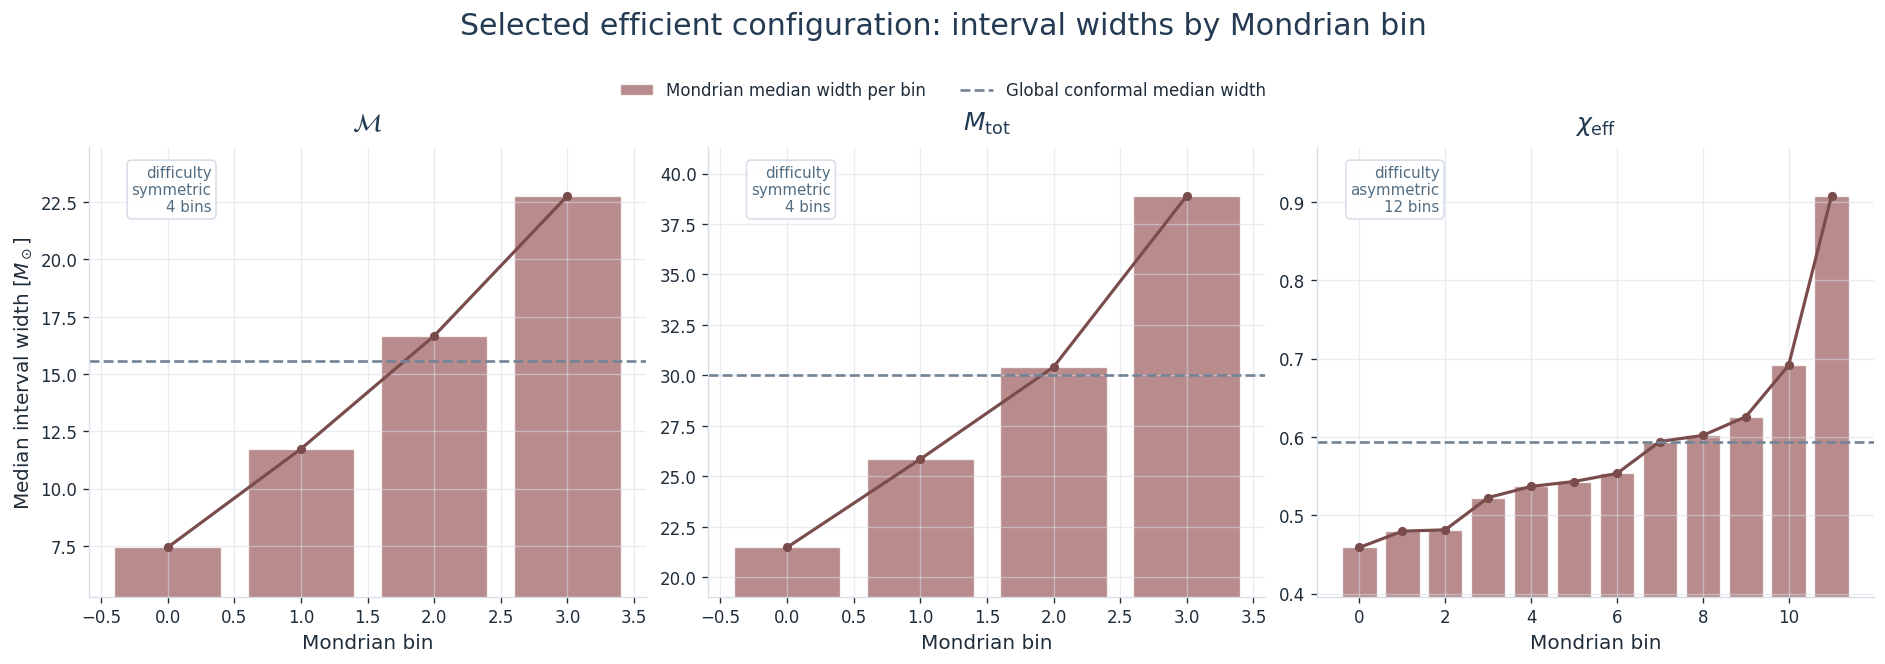

In [20]:
# ============================================================
# 16. Selected interval-width plots
#     One figure per policy: conservative / efficient
# ============================================================

def plot_selected_width_policy(
    final_policy="conservative",
    global_width_stat="median",   # "median" or "mean"
    save=True,
):
    if global_width_stat not in {"median", "mean"}:
        raise ValueError("global_width_stat must be either 'median' or 'mean'.")

    ncols = len(label_names)

    fig, axes = plt.subplots(
        1,
        ncols,
        figsize=(5.2 * ncols, 4.6),
        sharey=False,
        constrained_layout=True,
    )

    if ncols == 1:
        axes = [axes]

    for j, label in enumerate(label_names):
        ax = axes[j]

        label_idx = label_names.index(label)
        row, result = get_selected_result(label, final_policy=final_policy)

        widths_phys = selected_widths_phys(result, label_idx)
        bins = result.bin_indices_test[:, label_idx]

        width_by_bin = []
        mean_width_by_bin = []

        for b in range(int(row["n_bins"])):
            mask = bins == b
            if mask.any():
                width_by_bin.append(np.median(widths_phys[mask]))
                mean_width_by_bin.append(np.mean(widths_phys[mask]))
            else:
                width_by_bin.append(np.nan)
                mean_width_by_bin.append(np.nan)

        x = np.arange(int(row["n_bins"]))
        width_by_bin = np.asarray(width_by_bin, dtype=float)
        mean_width_by_bin = np.asarray(mean_width_by_bin, dtype=float)

        global_row = get_global_baseline_row(label)

        if global_width_stat == "median":
            global_width = float(global_row["median_width_phys"])
            global_label = "Global conformal median width"
        else:
            global_width = float(global_row["mean_width_phys"])
            global_label = "Global conformal mean width"

        bars = ax.bar(
            x,
            width_by_bin,
            color=MOND_COLORS["width"],
            alpha=0.78,
            edgecolor="white",
            linewidth=0.8,
            label="Mondrian median width per bin",
        )

        line_width, = ax.plot(
            x,
            width_by_bin,
            color=MOND_COLORS["width_dark"],
            linewidth=1.9,
            marker="o",
            markersize=4.5,
            label="Median width trend",
        )

        line_global = ax.axhline(
            global_width,
            linestyle="--",
            linewidth=1.6,
            color=MOND_COLORS["global_edge"],
            label=global_label,
        )

        ax.set_xlabel("Mondrian bin")

        unit = label_unit(label)
        ylabel = f"Median interval width [{unit}]" if unit else "Median interval width"
        if j == 0:
            ax.set_ylabel(ylabel)
        else:
            ax.set_ylabel("")

        ax.set_title(f"{label_tex(label)}", pad=10)

        # Config box: upper right
        meta = (
            f"{row['taxonomy_mode']}\n"
            f"{row['interval_mode']}\n"
            f"{int(row['n_bins'])} bins"
        )

        ax.text(
            0.22,
            0.96,
            meta,
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=9,
            color=MOND_COLORS["muted"],
            bbox=dict(
                boxstyle="round,pad=0.30",
                facecolor="white",
                edgecolor=MOND_COLORS["grid"],
                alpha=0.96,
            ),
        )

        # Independent y-limits per target.
        y_values = np.concatenate([
            width_by_bin[np.isfinite(width_by_bin)],
            np.array([global_width]),
        ])

        y_min = np.nanmin(y_values)
        y_max = np.nanmax(y_values)
        y_range = y_max - y_min

        if y_range <= 0:
            y_range = max(abs(y_max), 1.0)

        margin = 0.14 * y_range

        # Widths are positive, so keep lower bound at zero if close enough.
        lower = max(0.0, y_min - margin)
        upper = y_max + margin
        ax.set_ylim(lower, upper)

        style_axis_clean(ax)

    # Shared legend
    handles = [bars, line_global] #[bars, line_width, line_global]
    labels = [
        "Mondrian median width per bin",
        #"Median width trend",
        global_label,
    ]

    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=2,
        frameon=False,
        bbox_to_anchor=(0.5, 1.07),
        fontsize=10,
    )

    fig.suptitle(
        f"Selected {final_policy} configuration: interval widths by Mondrian bin",
        fontsize=18,
        color=MOND_COLORS["title"],
        y=1.17,
    )

    if save:
        savefig_clean(
            fig,
            f"mondrian_selected_interval_widths_{final_policy}_{global_width_stat}_global",
        )

    plt.show()


plot_selected_width_policy(final_policy="conservative", global_width_stat="median")
plot_selected_width_policy(final_policy="efficient", global_width_stat="median")

,label,system,coverage,median_width_phys,q95_width_phys,n_bins_under_2sigma,max_undercoverage_gap,taxonomy_mode,interval_mode,n_bins
0,chi_eff,Global,0.900633,0.593445,0.593445,NaN,NaN,global,symmetric,NaN
1,chi_eff,Conservative,0.900267,0.582661,0.687546,0.000000,0.005585,prediction,symmetric,8.000000
2,chi_eff,Efficient,0.899033,0.543044,0.907825,1.000000,0.015323,difficulty,asymmetric,12.000000
3,chirp_mass,Global,0.899967,15.558949,15.558949,NaN,NaN,global,symmetric,NaN
4,chirp_mass,Conservative,0.900533,11.775588,22.665657,0.000000,0.001524,difficulty,asymmetric,4.000000
5,chirp_mass,Efficient,0.901167,11.731975,22.774741,0.000000,0.001586,difficulty,symmetric,4.000000
6,total_mass,Global,0.901533,30.002580,30.002580,NaN,NaN,global,symmetric,NaN
7,total_mass,Conservative,0.899533,26.199136,35.239614,0.000000,0.006746,prediction,asymmetric,6.000000
8,total_mass,Efficient,0.900567,25.844899,38.893264,0.000000,0.001944,difficulty,symmetric,4.000000


Saved: mondrian_final_selection_overview_clean.png and mondrian_final_selection_overview_clean.pdf


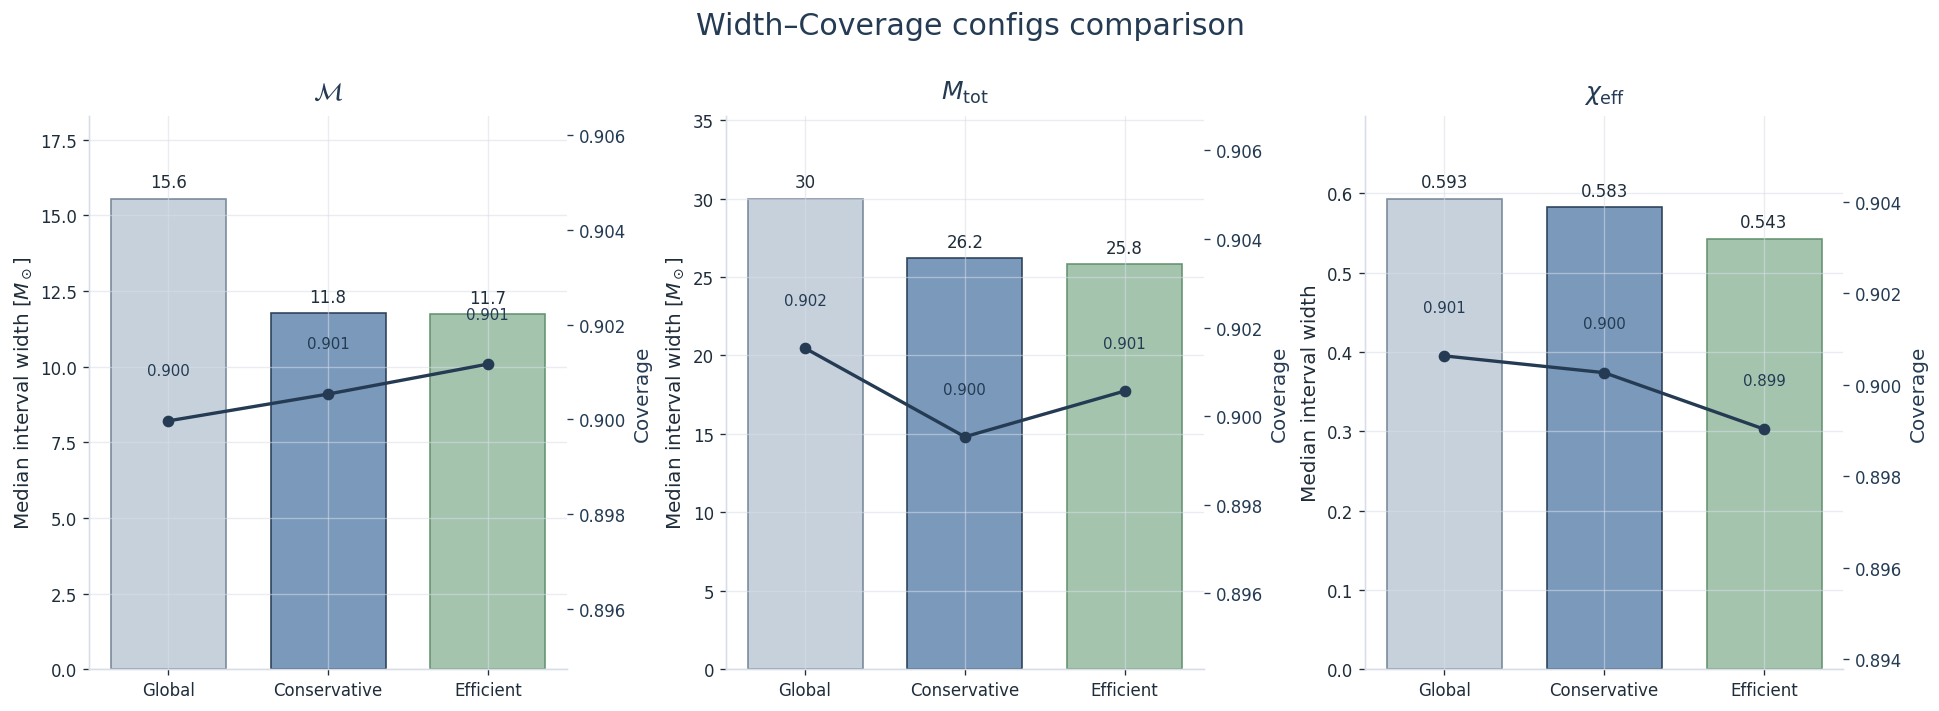

In [21]:
# ============================================================
# 17. Final selection overview: global vs selected Mondrian systems
#     Cleaner version for presentation
# ============================================================

def build_selection_comparison_df():
    rows = []

    # Global conformal baseline
    for _, row in global_conformal_df.iterrows():
        rows.append({
            "label": row["label"],
            "system": "Global",
            "coverage": float(row["coverage"]),
            "median_width_phys": float(row["median_width_phys"]),
            "q95_width_phys": float(row["q95_width_phys"]),
            "n_bins_under_2sigma": np.nan,
            "max_undercoverage_gap": np.nan,
            "taxonomy_mode": "global",
            "interval_mode": "symmetric",
            "n_bins": np.nan,
        })

    # Selected Mondrian systems
    for _, row in selected_systems_df.iterrows():
        rows.append({
            "label": row["label"],
            "system": row["final_policy"].capitalize(),
            "coverage": float(row["coverage"]),
            "median_width_phys": float(row["median_width_phys"]),
            "q95_width_phys": float(row["q95_width_phys"]),
            "n_bins_under_2sigma": float(row["n_bins_under_2sigma"]),
            "max_undercoverage_gap": float(row["max_undercoverage_gap"]),
            "taxonomy_mode": row["taxonomy_mode"],
            "interval_mode": row["interval_mode"],
            "n_bins": int(row["n_bins"]),
        })

    out = pd.DataFrame(rows)
    out["system"] = pd.Categorical(
        out["system"],
        ["Global", "Conservative", "Efficient"],
        ordered=True,
    )
    return out.sort_values(["label", "system"]).reset_index(drop=True)


selection_compare_df = build_selection_comparison_df()
display(selection_compare_df)


def _format_system_config(row):
    if row["system"] == "Global":
        return "global\nsymmetric\n1 interval"

    return (
        f"{row['taxonomy_mode']}\n"
        f"{row['interval_mode']}\n"
        f"{int(row['n_bins'])} bins"
    )


def plot_selection_overview_clean(save=True):
    fig, axes = plt.subplots(
        1,
        len(label_names),
        figsize=(5.35 * len(label_names), 5.25),
        constrained_layout=True,
    )

    if len(label_names) == 1:
        axes = [axes]

    bar_colors = {
        "Global": MOND_COLORS["global"],
        "Conservative": MOND_COLORS["conservative"],
        "Efficient": MOND_COLORS["efficient"],
    }

    bar_edge_colors = {
        "Global": MOND_COLORS["global_edge"],
        "Conservative": MOND_COLORS["coverage_dark"],
        "Efficient": "#5F8F6C",
    }

    for ax, label in zip(axes, label_names):
        sub = selection_compare_df[selection_compare_df["label"] == label].copy()
        x = np.arange(len(sub))

        bars = ax.bar(
            x,
            sub["median_width_phys"],
            color=[bar_colors[str(s)] for s in sub["system"]],
            edgecolor=[bar_edge_colors[str(s)] for s in sub["system"]],
            linewidth=1.0,
            alpha=0.92,
            width=0.72,
        )

        unit = label_unit(label)
        ylabel = f"Median interval width [{unit}]" if unit else "Median interval width"

        ax.set_ylabel(ylabel)
        ax.set_xticks(x)
        ax.set_xticklabels(sub["system"], fontsize=10)
        ax.set_title(f"{label_tex(label)}", pad=10)

        # Width labels above bars
        y_max_bar = float(sub["median_width_phys"].max())
        for xi, (_, row) in enumerate(sub.iterrows()):
            ax.text(
                xi,
                row["median_width_phys"] + 0.015 * y_max_bar,
                f"{row['median_width_phys']:.3g}",
                ha="center",
                va="bottom",
                fontsize=10,
                color=MOND_COLORS["text"],
            )

        # Coverage axis
        ax2 = ax.twinx()

        coverage_line, = ax2.plot(
            x,
            sub["coverage"],
            color=MOND_COLORS["coverage_dark"],
            marker="o",
            linewidth=2.0,
            markersize=6,
            label="Empirical coverage",
        )

        # nominal_line = ax2.axhline(
        #     CONFIDENCE_LEVEL,
        #     linestyle="--",
        #     linewidth=1.3,
        #     color=MOND_COLORS["nominal"],
        #     label=f"Nominal {int(CONFIDENCE_LEVEL * 100)}%",
        # )

        # Adaptive coverage y-limit
        cov_values = np.concatenate([
            sub["coverage"].values,
            np.array([CONFIDENCE_LEVEL]),
        ])
        cov_min = np.nanmin(cov_values)
        cov_max = np.nanmax(cov_values)
        cov_range = max(cov_max - cov_min, 0.015)
        cov_margin = 0.35 * cov_range

        ax2.set_ylim(
            max(0.0, cov_min - cov_margin),
            min(1.0, cov_max + cov_margin),
        )

        ax2.set_ylabel("Coverage", color=MOND_COLORS["coverage_dark"])
        ax2.tick_params(axis="y", colors=MOND_COLORS["coverage_dark"], labelsize=10)

        # Coverage labels near points
        for xi, (_, row) in enumerate(sub.iterrows()):
            ax2.text(
                xi,
                row["coverage"] + 0.06 * cov_range,
                f"{row['coverage']:.3f}",
                ha="center",
                va="bottom",
                fontsize=9,
                color=MOND_COLORS["coverage_dark"],
            )

        # # Configuration box, placed inside panel
        # config_lines = []
        # for _, row in sub.iterrows():
        #     system = str(row["system"])
        #     cfg = _format_system_config(row).replace("\n", " / ")
        #     config_lines.append(f"{system}: {cfg}")

        # config_text = "\n".join(config_lines)

        # ax.text(
        #     0.03,
        #     0.04,
        #     config_text,
        #     transform=ax.transAxes,
        #     ha="left",
        #     va="bottom",
        #     fontsize=8.4,
        #     color=MOND_COLORS["muted"],
        #     bbox=dict(
        #         boxstyle="round,pad=0.35",
        #         facecolor="white",
        #         edgecolor=MOND_COLORS["grid"],
        #         alpha=0.96,
        #     ),
        # )

        # Give headroom for bar labels
        y_min, y_max = ax.get_ylim()
        ax.set_ylim(0, y_max * 1.12)

        style_axis_clean(ax)
        ax2.grid(False)

    # Shared legend
    # handles = [
    #     plt.Rectangle((0, 0), 1, 1, color=MOND_COLORS["global"], alpha=0.92),
    #     plt.Rectangle((0, 0), 1, 1, color=MOND_COLORS["conservative"], alpha=0.92),
    #     plt.Rectangle((0, 0), 1, 1, color=MOND_COLORS["efficient"], alpha=0.92),
    #     coverage_line,
    #     nominal_line,
    # ]
    # labels = [
    #     "Global conformal",
    #     "Selected conservative Mondrian",
    #     "Selected efficient Mondrian",
    #     "Empirical coverage",
    #     f"Nominal {int(CONFIDENCE_LEVEL * 100)}%",
    # ]

    # fig.legend(
    #     handles,
    #     labels,
    #     loc="upper center",
    #     ncol=5,
    #     frameon=False,
    #     bbox_to_anchor=(0.5, 1.07),
    #     fontsize=10,
    # )

    fig.suptitle(
        "Width–Coverage configs comparison",
        fontsize=18,
        color=MOND_COLORS["title"],
        y=1.1,
    )

    if save:
        savefig_clean(fig, "mondrian_final_selection_overview_clean")

    plt.show()


plot_selection_overview_clean()

Saved: mondrian_search_tradeoff.png and mondrian_search_tradeoff.pdf


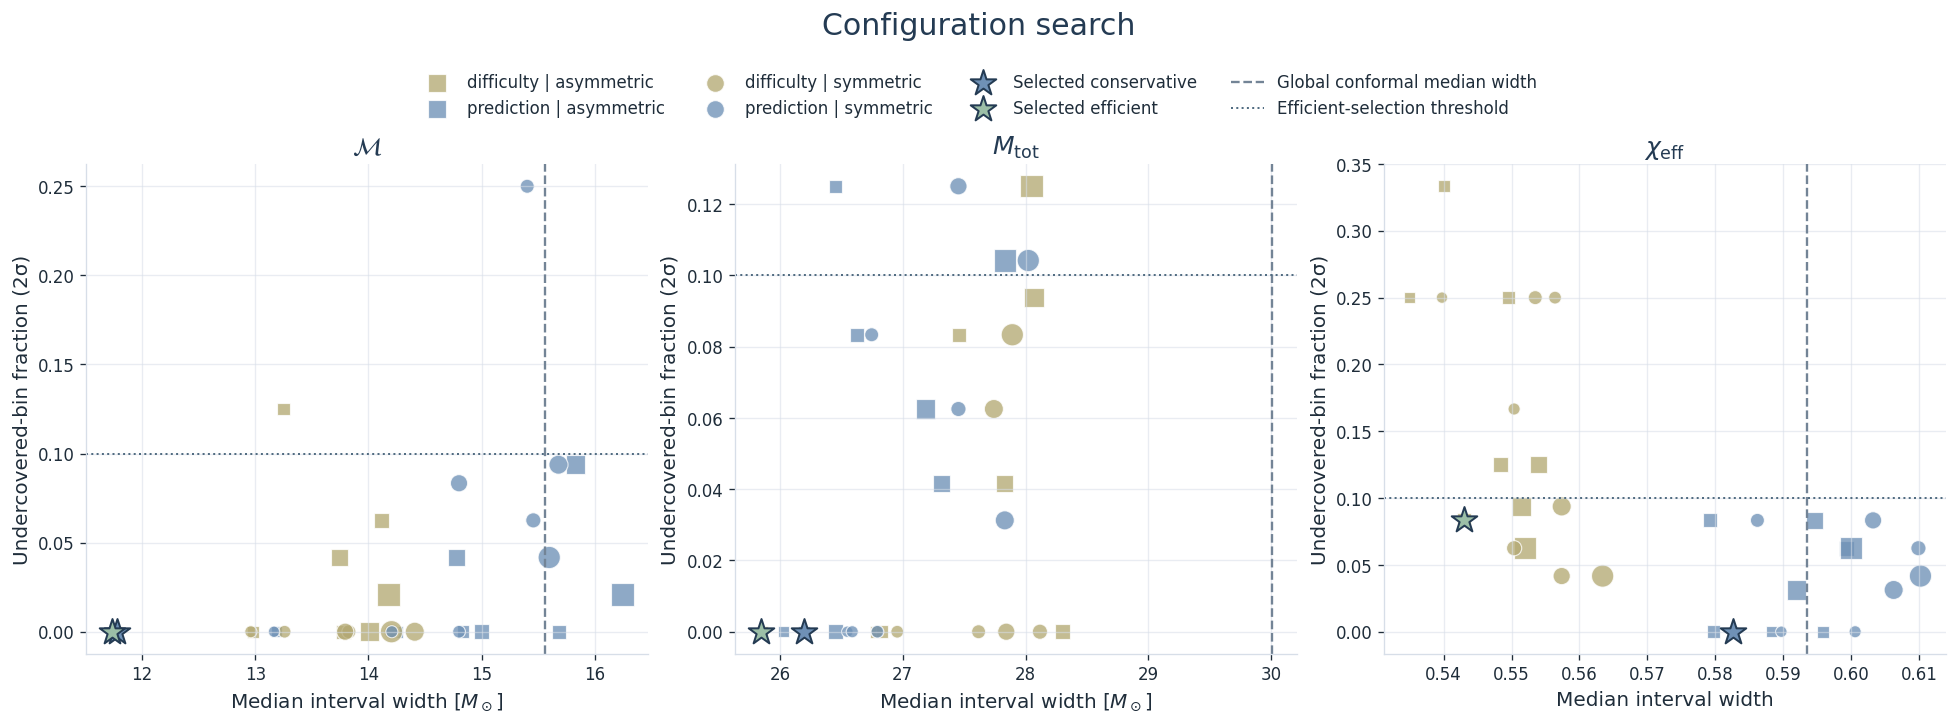

In [22]:
# ============================================================
# 18. Search-space trade-off: width vs local-validity proxy
# ============================================================

def plot_search_tradeoff(save=True):
    fig, axes = plt.subplots(
        1, len(label_names),
        figsize=(5.4 * len(label_names), 4.9),
        constrained_layout=True
    )

    if len(label_names) == 1:
        axes = [axes]

    marker_map = {"symmetric": "o", "asymmetric": "s"}
    color_map = {
        "prediction": MOND_COLORS["prediction"],
        "difficulty": MOND_COLORS["difficulty"],
    }

    # We will keep one handle of each reference line for the shared legend
    vline_handle = None
    hline_handle = None

    for ax, label in zip(axes, label_names):
        sub = summary_df[summary_df["label"] == label].copy()

        for interval_mode in sorted(sub["interval_mode"].unique()):
            for taxonomy_mode in sorted(sub["taxonomy_mode"].unique()):
                part = sub[
                    (sub["interval_mode"] == interval_mode) &
                    (sub["taxonomy_mode"] == taxonomy_mode)
                ].copy()

                ax.scatter(
                    part["global_median_width_phys"],
                    part["under_bin_fraction_2sigma"],
                    s=35 + 3.0 * part["n_bins"].values,
                    alpha=0.78,
                    color=color_map[taxonomy_mode],
                    marker=marker_map[interval_mode],
                    edgecolor="white",
                    linewidth=0.7,
                    label=f"{taxonomy_mode} | {interval_mode}",
                )

        # Highlight selected points
        for policy, color in [
            ("conservative", MOND_COLORS["conservative"]),
            ("efficient", MOND_COLORS["efficient"]),
        ]:
            row = selection_df[
                (selection_df["label"] == label) &
                (selection_df["final_policy"] == policy)
            ].iloc[0]

            ax.scatter(
                row["global_median_width_phys"],
                row["under_bin_fraction_2sigma"],
                s=260,
                color=color,
                marker="*",
                edgecolor=MOND_COLORS["title"],
                linewidth=1.2,
                zorder=10,
                label=f"Selected {policy}" if label == label_names[0] else None,
            )

            # ax.text(
            #     row["global_median_width_phys"],
            #     row["under_bin_fraction_2sigma"] + 0.009,
            #     "C" if policy == "conservative" else "E",
            #     ha="center",
            #     va="center",
            #     fontsize=10,
            #     fontweight="bold",
            #     color=MOND_COLORS["title"],
            # )

        # Global conformal width as reference
        global_row = get_global_baseline_row(label)
        vline = ax.axvline(
            global_row["median_width_phys"],
            linestyle="--",
            linewidth=1.4,
            color=MOND_COLORS["global_edge"],
            label="Global conformal median width",
        )
        if vline_handle is None:
            vline_handle = vline

        # Efficient selection threshold
        hline = ax.axhline(
            MAX_UNDER_BIN_FRACTION_EFFICIENT,
            linestyle=":",
            linewidth=1.2,
            color=MOND_COLORS["muted"],
            label="Efficient-selection threshold",
        )
        if hline_handle is None:
            hline_handle = hline

        unit = label_unit(label)
        xlabel = f"Median interval width [{unit}]" if unit else "Median interval width"
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Undercovered-bin fraction (2σ)")
        ax.set_title(f"{label_tex(label)}")

        style_axis_clean(ax)

    # Unique legend across all panels
    handles, labels_ = [], []
    for ax in axes:
        h, l = ax.get_legend_handles_labels()
        for hh, ll in zip(h, l):
            if ll not in labels_ and ll is not None and ll != "":
                handles.append(hh)
                labels_.append(ll)

    fig.legend(
        handles,
        labels_,
        loc="upper center",
        ncol=4,
        frameon=False,
        bbox_to_anchor=(0.5, 1.12),
        fontsize=10,
    )

    fig.suptitle(
        "Configuration search",
        fontsize=18,
        color=MOND_COLORS["title"],
        y=1.20
    )

    if save:
        savefig_clean(fig, "mondrian_search_tradeoff")

    plt.show()


plot_search_tradeoff()

In [23]:
# ============================================================
# 19. Conditional diagnostics in a cleaner multi-panel layout
#     Coverage + width, adaptive axes, no misleading width shading
# ============================================================

def _adaptive_ylim(values, extra_values=None, min_range=None, margin_fraction=0.16, lower_floor=None, upper_cap=None):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if extra_values is not None:
        extra_values = np.asarray(extra_values, dtype=float)
        extra_values = extra_values[np.isfinite(extra_values)]
        values = np.concatenate([values, extra_values])

    if values.size == 0:
        return None

    y_min = float(np.nanmin(values))
    y_max = float(np.nanmax(values))
    y_range = y_max - y_min

    if min_range is not None and y_range < min_range:
        center = 0.5 * (y_min + y_max)
        y_min = center - 0.5 * min_range
        y_max = center + 0.5 * min_range
        y_range = min_range

    if y_range <= 0:
        y_range = max(abs(y_max), 1.0)

    margin = margin_fraction * y_range
    lower = y_min - margin
    upper = y_max + margin

    if lower_floor is not None:
        lower = max(lower_floor, lower)
    if upper_cap is not None:
        upper = min(upper_cap, upper)

    return lower, upper


def plot_conditional_grid(field="network_snr", final_policy="conservative", save=True):
    fig, axes = plt.subplots(
        2,
        len(label_names),
        figsize=(5.0 * len(label_names), 7.0),
        sharex="col",
        sharey=False,
        constrained_layout=True,
    )

    if len(label_names) == 1:
        axes = np.asarray(axes).reshape(2, 1)

    for j, label in enumerate(label_names):
        ax_cov = axes[0, j]
        ax_wid = axes[1, j]

        key = (final_policy, label, field)
        if key not in conditional_tables:
            ax_cov.set_visible(False)
            ax_wid.set_visible(False)
            continue

        table = conditional_tables[key].copy()

        x = table["center"].values
        cov = table["coverage"].values
        wid = table["median_width_phys"].values
        cnt = table["count"].values

        # Approximate nominal fluctuation bands around target coverage.
        sigma = np.sqrt(CONFIDENCE_LEVEL * (1.0 - CONFIDENCE_LEVEL) / cnt)
        low_1s = CONFIDENCE_LEVEL - sigma
        high_1s = CONFIDENCE_LEVEL + sigma
        low_2s = CONFIDENCE_LEVEL - 2.0 * sigma
        high_2s = CONFIDENCE_LEVEL + 2.0 * sigma

        # -----------------------------
        # Coverage panel
        # -----------------------------
        ax_cov.fill_between(
            x,
            low_2s,
            high_2s,
            color=MOND_COLORS["band2"],
            alpha=0.35,
            label=r"$2\sigma$ nominal band",
        )

        ax_cov.fill_between(
            x,
            low_1s,
            high_1s,
            color=MOND_COLORS["band2"],
            alpha=0.75,
            label=r"$1\sigma$ nominal band",
        )

        cov_line, = ax_cov.plot(
            x,
            cov,
            marker="o",
            markersize=5,
            linewidth=2.0,
            color=MOND_COLORS["coverage_dark"],
            label="Empirical coverage",
        )

        nominal_line = ax_cov.axhline(
            CONFIDENCE_LEVEL,
            linestyle="--",
            linewidth=1.25,
            color=MOND_COLORS["nominal"],
            label=f"Nominal {int(CONFIDENCE_LEVEL * 100)}%",
        )

        ax_cov.set_title(f"{label_tex(label)}", pad=10)

        if j == 0:
            ax_cov.set_ylabel("Coverage")
        else:
            ax_cov.set_ylabel("")

        cov_ylim = _adaptive_ylim(
            cov,
            extra_values=np.concatenate([
                low_2s,
                high_2s,
                np.array([CONFIDENCE_LEVEL]),
            ]),
            min_range=0.055,
            margin_fraction=0.14,
            lower_floor=0.0,
            upper_cap=1.0,
        )
        ax_cov.set_ylim(*cov_ylim)

        style_axis_clean(ax_cov)

        # -----------------------------
        # Width panel
        # -----------------------------
        wid_line, = ax_wid.plot(
            x,
            wid,
            marker="s",
            markersize=5,
            linewidth=2.0,
            color=MOND_COLORS["width_dark"],
            label="Median interval width",
        )

        # No fill_between: width shading has no statistical meaning here.
        # Keep the plot as a line/marker diagnostic.

        unit = label_unit(label)
        ylabel = f"Median width [{unit}]" if unit else "Median width"

        if j == 0:
            ax_wid.set_ylabel(ylabel)
        else:
            ax_wid.set_ylabel("")

        ax_wid.set_xlabel(table["conditioning_label"].iloc[0])

        wid_ylim = _adaptive_ylim(
            wid,
            min_range=None,
            margin_fraction=0.18,
            lower_floor=None,
            upper_cap=None,
        )
        ax_wid.set_ylim(*wid_ylim)

        style_axis_clean(ax_wid)

    # Shared legend, compact.
    handles = [cov_line, nominal_line]
    labels = [
        "Empirical coverage",
        f"Nominal {int(CONFIDENCE_LEVEL * 100)}%",
    ]

    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=2,
        frameon=False,
        bbox_to_anchor=(0.5, 1.035),
        fontsize=10,
    )

    fig.suptitle(
        f"Selected {final_policy} system: conditional coverage and width vs {field_tex(field)}",
        fontsize=17,
        color=MOND_COLORS["title"],
        y=1.085,
    )

    if save:
        savefig_clean(fig, f"conditional_{final_policy}_{field}")

    plt.show()

Saved: conditional_conservative_network_snr.png and conditional_conservative_network_snr.pdf


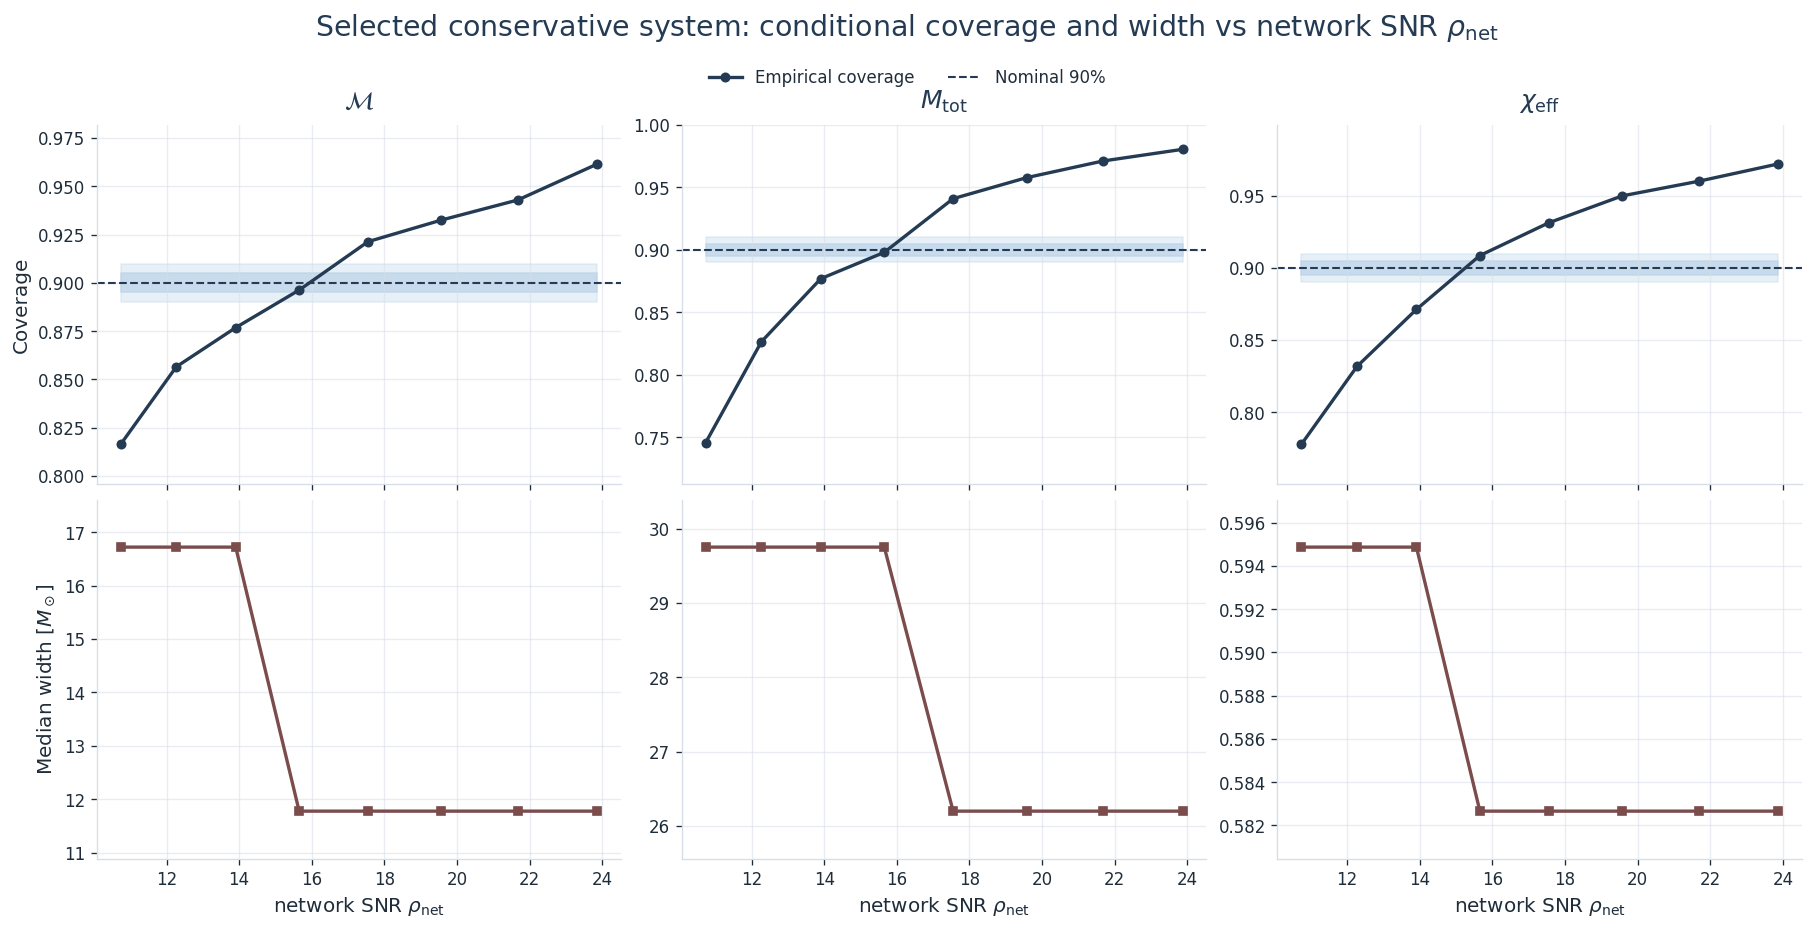

Saved: conditional_efficient_network_snr.png and conditional_efficient_network_snr.pdf


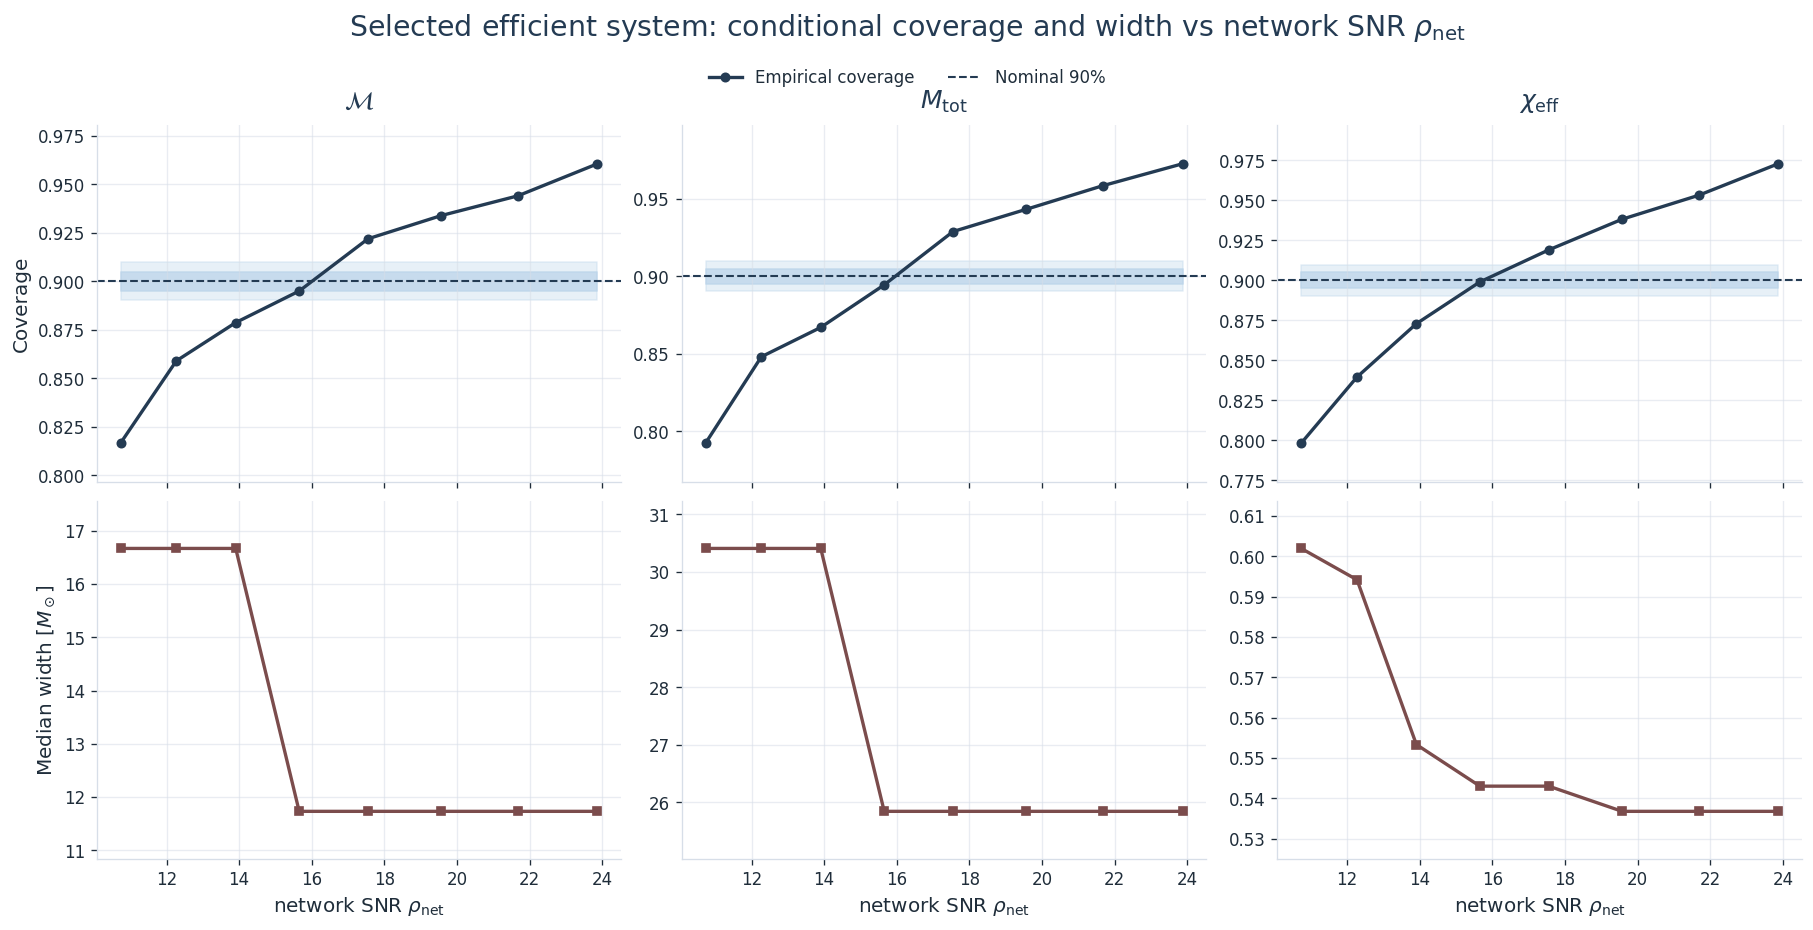

Saved: conditional_conservative_signal_network_duration.png and conditional_conservative_signal_network_duration.pdf


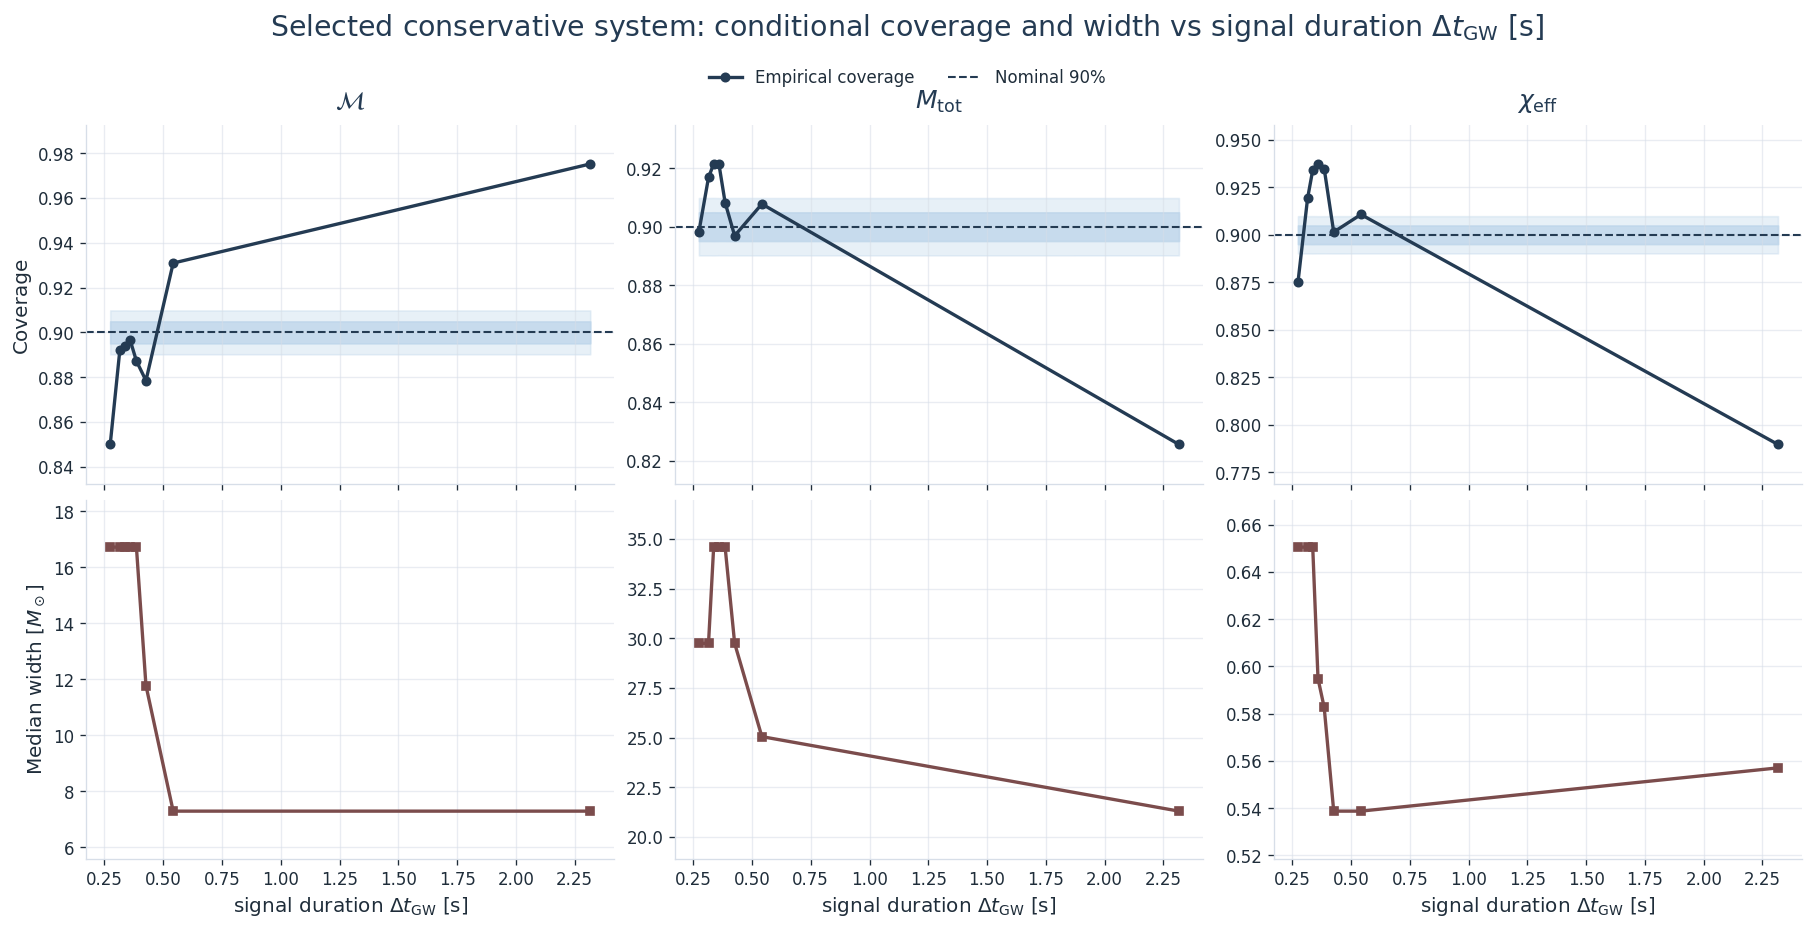

Saved: conditional_efficient_signal_network_duration.png and conditional_efficient_signal_network_duration.pdf


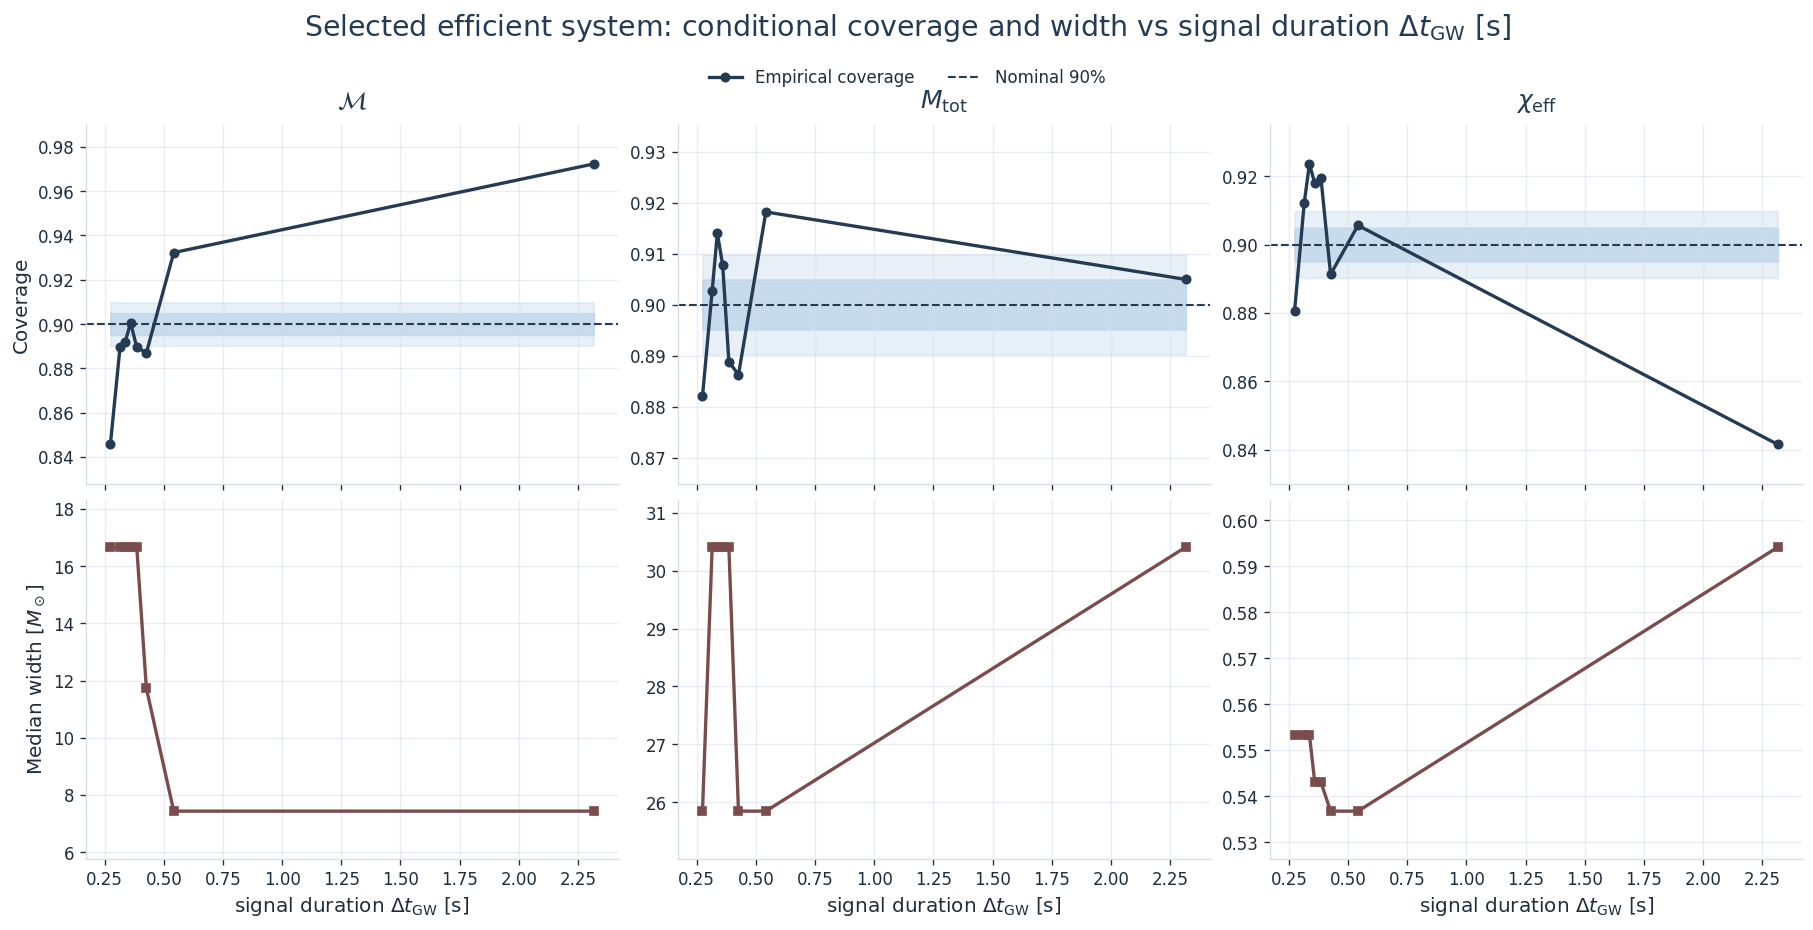

Saved: conditional_conservative_total_mass.png and conditional_conservative_total_mass.pdf


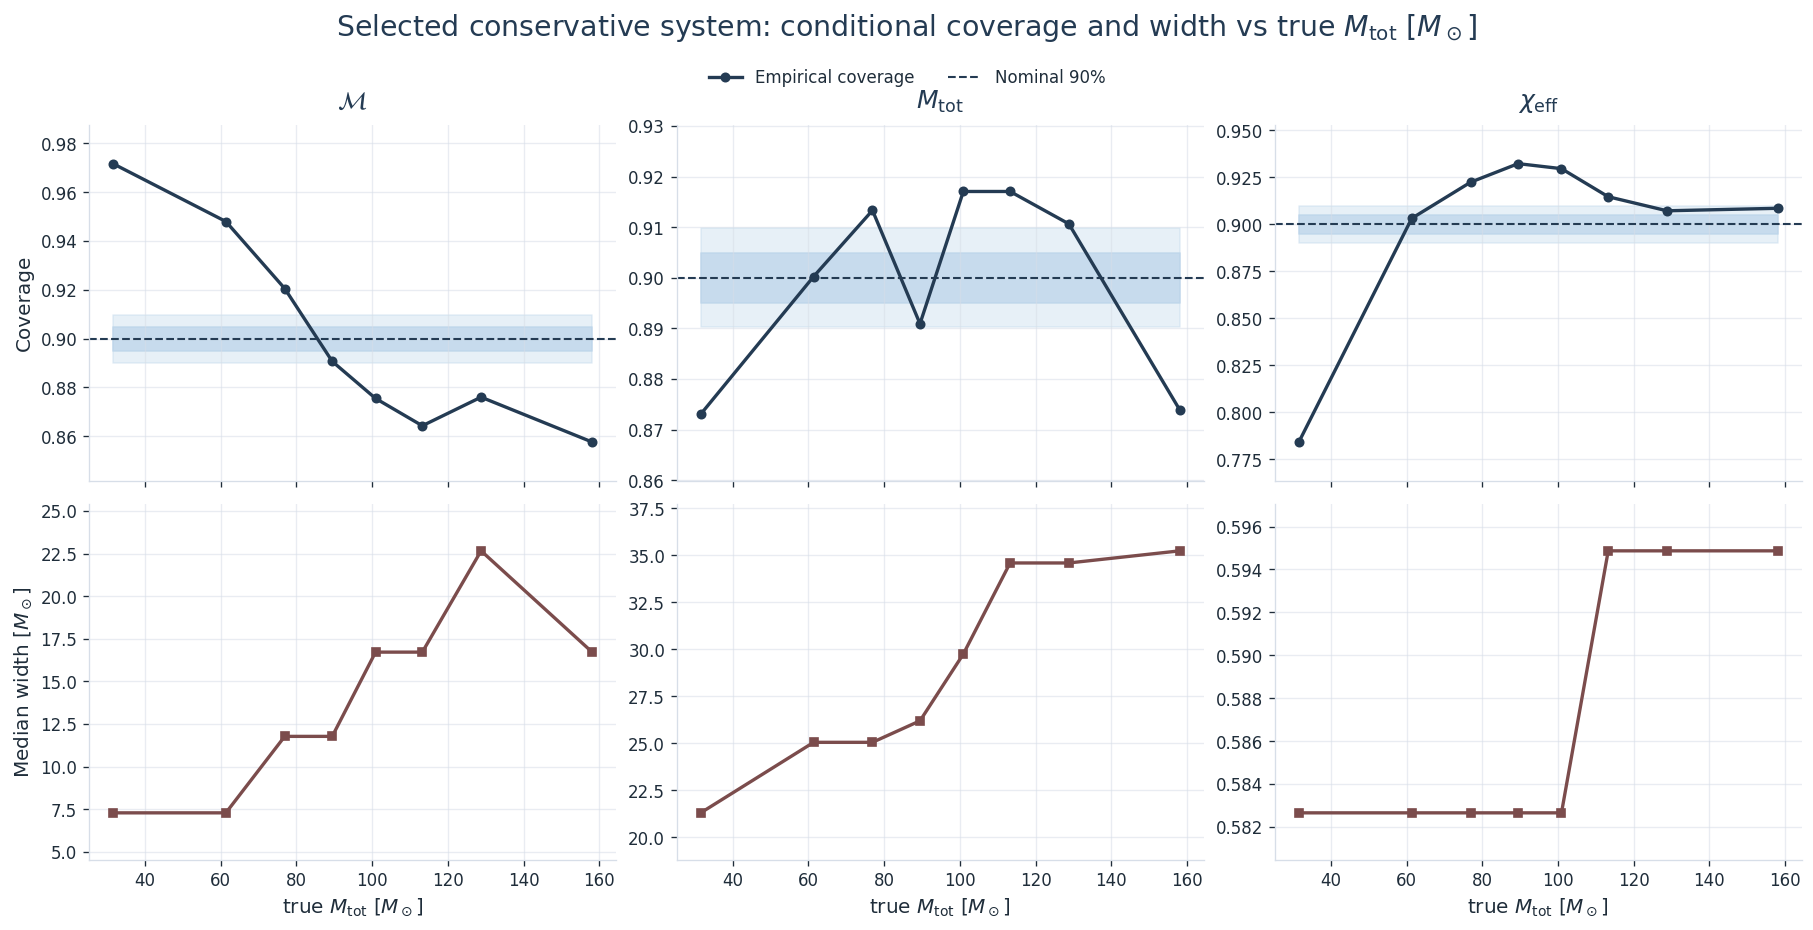

Saved: conditional_efficient_total_mass.png and conditional_efficient_total_mass.pdf


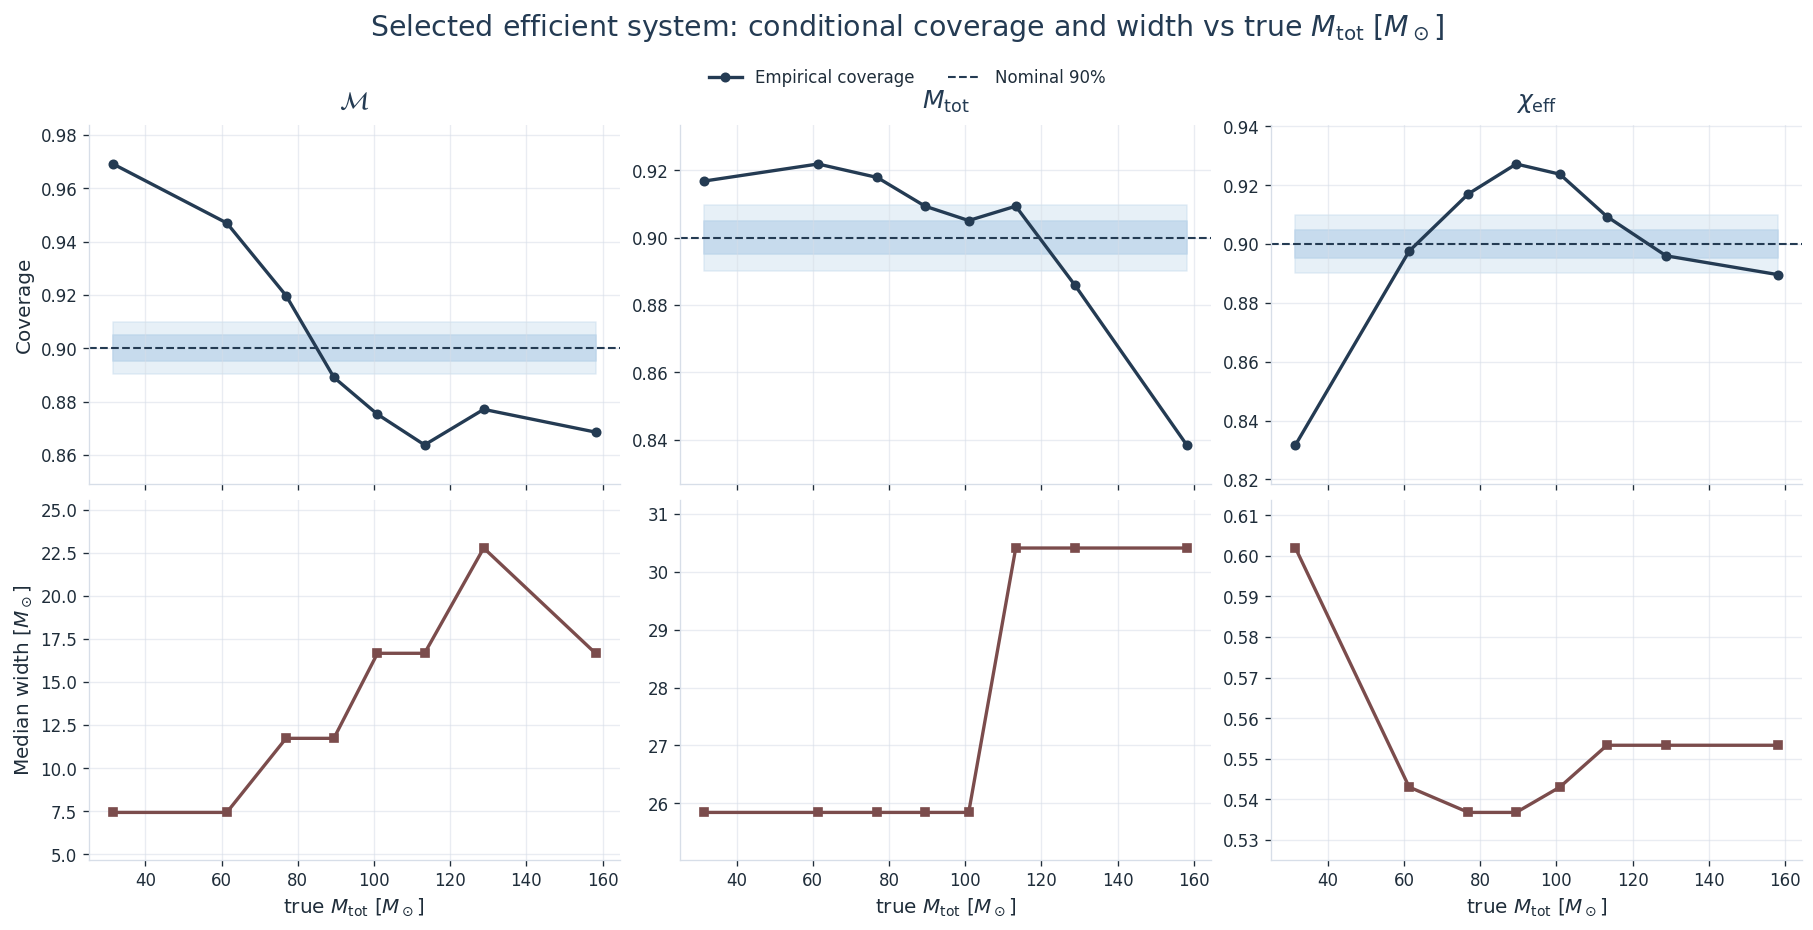

Saved: conditional_conservative_chi_eff.png and conditional_conservative_chi_eff.pdf


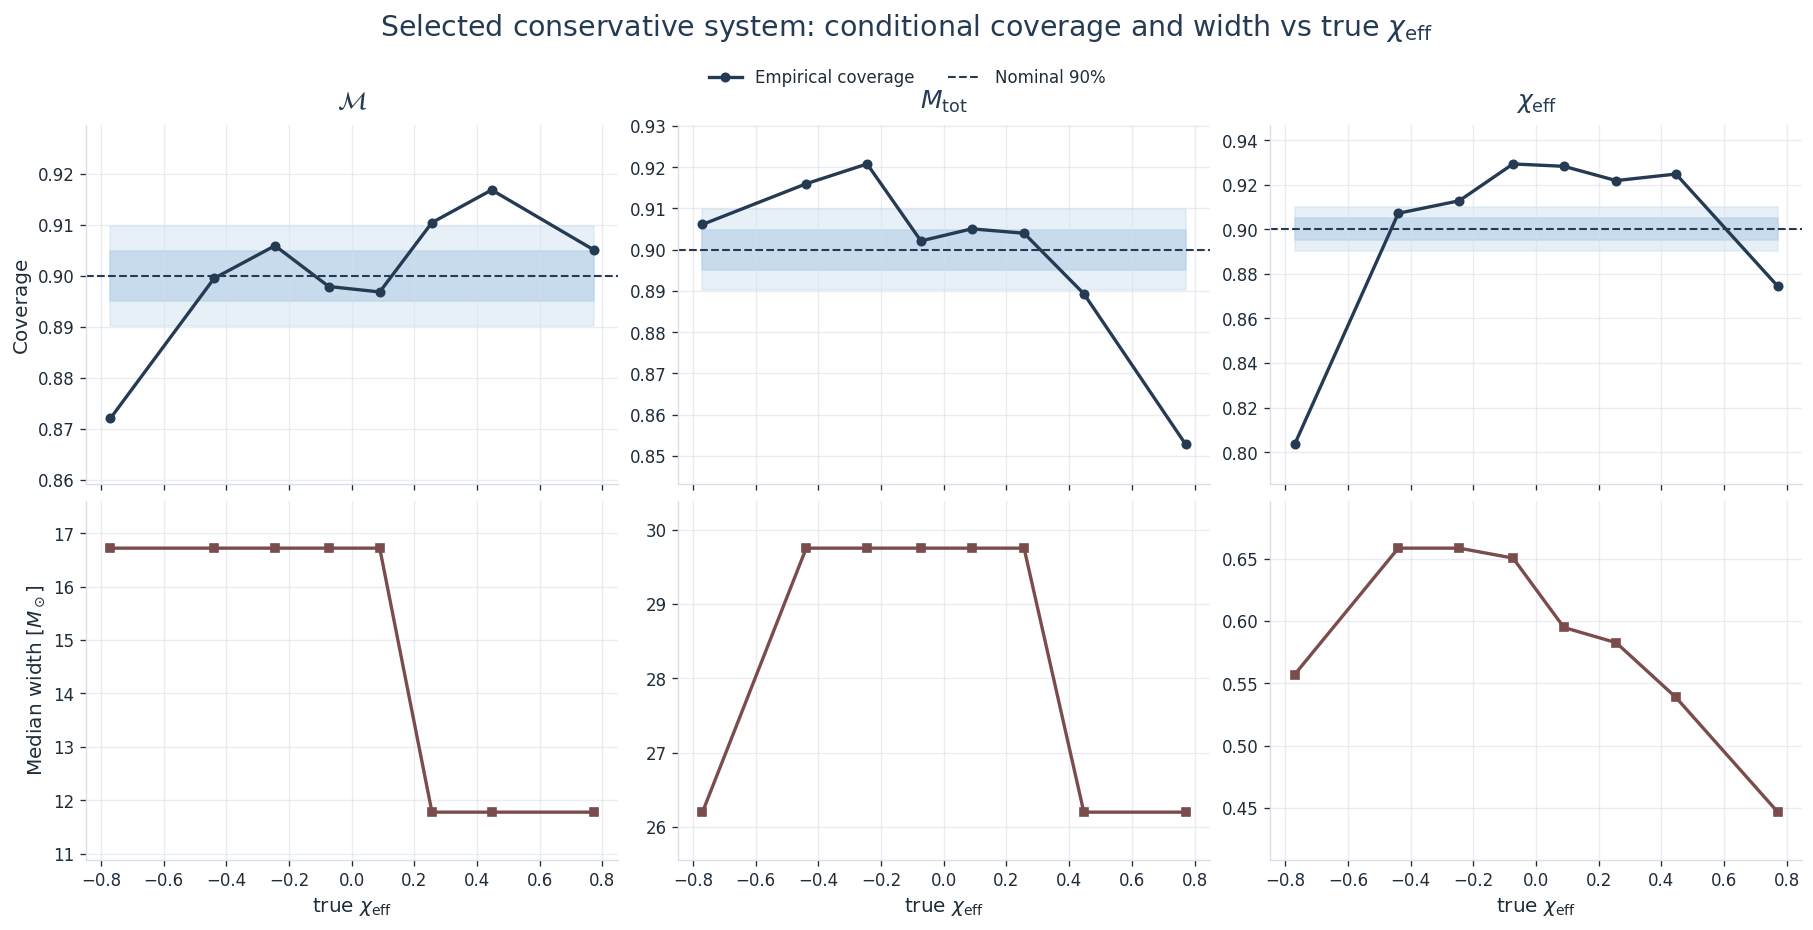

Saved: conditional_efficient_chi_eff.png and conditional_efficient_chi_eff.pdf


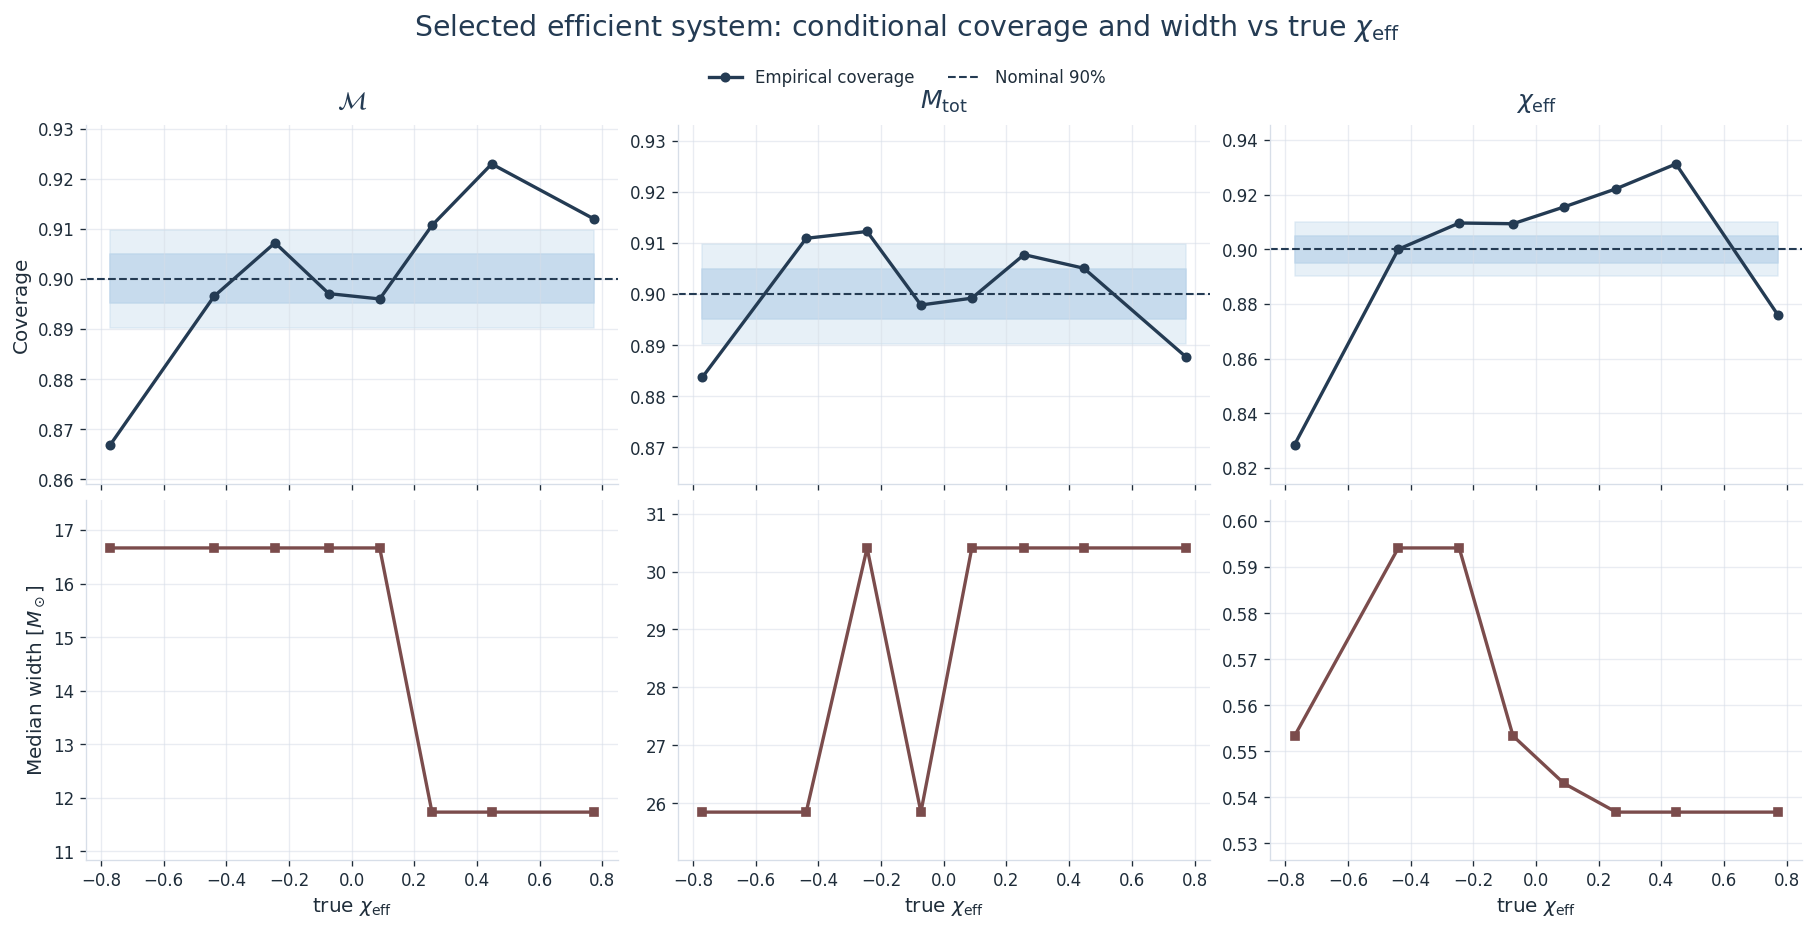

In [24]:
for _field in ["network_snr", "signal_network_duration", "total_mass", "chi_eff"]:
    if _field in test_meta_df.columns:
        plot_conditional_grid(field=_field, final_policy="conservative")
        plot_conditional_grid(field=_field, final_policy="efficient")